# AB Dor: `amigo-pipeline` QUICKSTART

AB Dor and its calibrators run through `amigo-pipeline` following its `QUICKSTART.md`, with the data loaded the same way as
`ab-dor_0.11.ipynb`.

## 1. Environment

In [1]:
import sys
from pathlib import Path

for repo in ("amigo-pipeline", "amigo"):
    sys.path.insert(0, str(Path.home() / "code" / "louis_stack" / repo / "src"))

import jax

jax.config.update("jax_enable_x64", True)

import os
import amigo
import amigo.files

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


## 2. Loading in data
As in `ab-dor_0.11.ipynb`.

In [2]:
from socket import gethostname

print(gethostname())
if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs"


uncal_data_dir = os.path.join(data_dir, "AB-DOR/uncal/")
data_dir = os.path.join(data_dir, "AB-DOR/calslope/")

n_files_per_filt = 1  # max out at 25 (HD-36805's F480M dither sequence)
one_filt_flag = True  # if True, only use F480M
pos1_only = False
pipeline_flag = False
# stop the pipeline after this stage: instrument, science_reference, visibility_basis,
# visibility_fits, endpoint_jtj, calibrated_visibility or discos
# THROUGH = "visibility_fits"  
THROUGH = "discos"  
RESUME = False  # reuse compatible completed stages in the output folder; False recomputes them
FIT_ROTATION = False  # fit the detector rotation in the instrument stage

# TARGPROP values in the data: science target is "AB-DOR", PSF calibrators are
# "HD-37093" and "HD-36805" (see chromatic_psf.ipynb).
EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

max-vscode-gpu-0-9


In [3]:
import importlib
import numpy as np

# Same shared bad-pixel map used in retrain.ipynb
resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")
with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)
badpix_bool = badpix.astype(
    bool
)  # use for boolean masking; badpix (int) is kept for FITS writing


def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file

In [4]:
# get_pos is copied from amigo's retrain branch (amigo.misc), which Louis's amigo doesn't have
def get_pos(file, box=5):
    """Which AMI primary dither position (POS1-POS4) an exposure is at, from the source centroid."""
    POS_COORDS = {"POS1": (46, 40), "POS2": (31, 54), "POS3": (18, 25), "POS4": (59, 24)}
    data = np.array(file["SLOPE"].data)
    if data.ndim == 3:
        data = data[-1]
    data = np.where(badpix_bool, 0.0, data)
    y0, x0 = np.unravel_index(np.nanargmax(data), data.shape)
    y_lo, y_hi = max(0, y0 - box), min(data.shape[0], y0 + box + 1)
    x_lo, x_hi = max(0, x0 - box), min(data.shape[1], x0 + box + 1)
    sub = data[y_lo:y_hi, x_lo:x_hi]
    ys, xs = np.mgrid[y_lo:y_hi, x_lo:x_hi]
    target = np.array([np.sum(xs * sub), np.sum(ys * sub)]) / np.sum(sub)
    labels = list(POS_COORDS)
    dists = np.linalg.norm(np.array([POS_COORDS[label] for label in labels]) - target, axis=1)
    return labels[int(np.argmin(dists))]

# Same file-sorting convention as retrain.ipynb: prefer POS1 dithers (falling
# back to interleaved POS1/POS2), grouped by filter, truncated to at most `n`
# files per filter.
# Quick toggle flags -- controls how much data goes into the fit.


def sort_files(files, n):
    files.sort(
        key=lambda x: (
            x[0].header["PROGRAM"],
            x[0].header["FILTER"],
            x[0].header["PATT_NUM"],
        ),
        reverse=True,
    )
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}

    for filt in filts:
        if one_filt_flag and filt != "F480M":
            these_files[filt] = []
            continue

        matched = [f for f in files if f[0].header["FILTER"] == filt]

        if pos1_only:
            x = [f for f in matched if get_pos(f) == "POS1"]
        else:
            pos1 = [f for f in matched if get_pos(f) == "POS1"]
            pos2 = [f for f in matched if get_pos(f) == "POS2"]
            x = []
            for a, b in zip(pos1, pos2):
                x.extend([a, b])
            x.extend(pos1[len(pos2) :])
            x.extend(pos2[len(pos1) :])

        these_files[filt] = x[0:n]

    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [5]:
from retrain_fns import summarise_files
from amigo.pipelines import process_calslope

if pipeline_flag:
    process_calslope(uncal_data_dir, data_dir)

# The known PSF calibrators for this program (see chromatic_psf.ipynb). A
# handful of single-frame acquisitions for other targets (e.g.
# "J062802.01-663738.0") also show up as IS_PSF=True in this folder; their
# TARGPROP contains a literal "." which breaks amigo's dotted param-key
# lookup, so they're excluded explicitly rather than accepted via IS_PSF alone.
CALIBRATORS = [
    # "HD-37093",
    "HD-36805",
    ]

sci_files = sort_files(file_fn(data_dir, IS_PSF=False), n=n_files_per_filt)
cal_files = sort_files(file_fn(data_dir, IS_PSF=True), n=n_files_per_filt)
cal_files = [f for f in cal_files if f[0].header["TARGPROP"] in CALIBRATORS]

sci_files = [add_badpix(f) for f in sci_files]
cal_files = [add_badpix(f) for f in cal_files]

summarise_files(sci_files)
summarise_files(cal_files)

  program  target filter dither   g/i        date                 PI    CAL
0    1093  AB-DOR  F480M    5/5  5/69  05-06-2022  Thatte, Deepashri  False
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  25/25  9/65  05-06-2022  Thatte, Deepashri  True


## 3. Construct the exposures and AMIGO model

In [6]:
from amigo.core_models import AmigoModel
from amigo.detector_models import LinearDetector
from amigo.model_fits import SplineVisFit
from amigo.optical_models import AMIOptics
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from amigo.vis_models import LogVisModel

# Load the normal AMIGO calibration state and a conventional visibility basis.
# The latter is only needed to initialize AmigoModel; Pipeline replaces it
# with the FoV-aware mixed-complex basis that it constructs.
calibration = np.load(os.path.join(amigo_files_path, "calibration.npy"), allow_pickle=True).item()
initial_vis_basis = np.load(os.path.join(amigo_files_path, "vis_basis.npy"), allow_pickle=True).item()
files = cal_files + sci_files  # from section 2, bad pixels already added

exposures = [
    SplineVisFit(file, use_cov=True, joint_fit=True)
    for file in files
]
exposures = [
    exposure.set("cov", 0.5 * (exposure.cov + exposure.cov.swapaxes(0, 1)))
    for exposure in exposures
]

# This one-mode, zero-coefficient visibility model is only the holder needed
# to initialize AmigoModel. It is never fitted: Pipeline replaces it, and its
# coefficients, before the visibility-fitting stage.
initial_vis = LogVisModel(
    initial_vis_basis,
    n_basis=1,
)

model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    detector=LinearDetector(),
    read=ReadModel(),
    ramp_model=NonLinearRamp(),
    vis_model=initial_vis,
    state=calibration,
)

### Exact-autodiff operators
The quickstart doesn't show this step, but Louis's own entry point (`Pipeline.from_dataset` via `model_factory.py`) always
does it, and without it the first fit hits NaN gradients. It swaps in derivative-safe versions of AMIGO's interpolation and PSF
square root (forward results unchanged), with interpolation operators prepared for the visibility-basis image sizes, computed
as in `model_factory.py` from the pipeline's default field of view (2600 mas detector width, 0.75 FoV fraction).

In [7]:
import math
from amigo_pipeline.exact_ad import install_exact_ad

optics = model.optics
half_fov_arcsec = 2600.0 * 0.75 / 1000.0
image_sizes = []
for filter_name in dict.fromkeys(exposure.filter for exposure in exposures):
    envelope_arcsec = float(np.max(np.asarray(optics.filters[filter_name][0]))) / 0.80 * 206264.80624709636
    psf_pixels = max(24, 2 * int(math.ceil((half_fov_arcsec + envelope_arcsec) / float(optics.psf_pixel_scale))))
    psf_pixels += psf_pixels % 2
    image_sizes.append(int(psf_pixels * optics.oversample))

exact_ad = install_exact_ad(model, exposures[0], checkpoint=True, extra_image_sizes=image_sizes)

### Piston-gradient fix (patch, this notebook only)
AMIGO's `ModelFit.update_optics` freezes the gradient of `aberrations[0, 0]` (hole 0 piston) with `stop_gradient`, to remove the
global-piston degeneracy in AMIGO's own training loop. The pipeline removes common piston/tip/tilt with its own gauge instead, so
its wavefront directions include hole 0's piston relative to the other holes: the forward model responds to that piston but its
derivative is zero. Checked against finite differences, every wavefront derivative was 20–50% wrong (positions, fluxes, spectrum
and rotation were exact); with the freeze removed they all agree to ~3e-8. The wrong derivatives made the JTJ, the whitening and
the gradients wrong, so gradient descent could only take quarter steps and never converged. Louis's checkout is untouched.

In [8]:
from jax import lax
import amigo.model_fits as model_fits


def update_optics_without_piston_freeze(self, model):
    """AMIGO's ModelFit.update_optics without the hole-0 piston stop_gradient; otherwise identical.

    AMIGO freezes the gradient of aberrations[0, 0] (hole 0 piston) to remove the global-piston degeneracy in its own
    training loop. The pipeline instead removes common piston/tip/tilt with its own gauge, so its wavefront directions
    include hole 0's piston relative to the others; with the freeze the forward model responds to that piston but its
    derivative is zero, so the JTJ, whitening and gradients are all wrong in the wavefront (20-50% errors).
    """
    optics = model.optics
    if "aberrations" in model.params.keys():
        coefficients = model.aberrations[self.get_key("aberrations")]
        if not self.calibrator:  # science targets: wavefront fixed, as in AMIGO
            coefficients = lax.stop_gradient(coefficients)
        optics = optics.set("pupil_mask.abb_coeffs", coefficients)
    if hasattr(model, "reflectivity"):
        optics = optics.set("pupil_mask.amp_coeffs", model.reflectivity[self.get_key("reflectivity")])
    return optics.set("defocus", model.defocus[self.get_key("defocus")])


model_fits.ModelFit.update_optics = update_optics_without_piston_freeze

### Unit-free whitening (patch, this notebook only)
Each fitting stage computes the exact JTJ at its start, keeps only eigen-directions with eigenvalue above `optimizer_rank_rtol`
(1e-8) × the largest, and whitens them. In native units that comparison mixes units: positions have curvature ~1e9 per arcsec²
and the wavefront ~1–40 per nm², so every wavefront direction was discarded as "unidentified" (not fitted at all). Lowering the
tolerance instead fails the pipeline's whitening accuracy check, because a float64 eigendecomposition over a ~1e13 eigenvalue
spread isn't accurate for the small directions.

This replaces Louis's `_fisher_transform` with the same whitening done after dividing each parameter by the square root of its
own JTJ diagonal (so the eigendecomposition is unit-free, spread ~1e5), then mapping back. The rank cut and the 2e-6 closure
check are unchanged; reported eigenvalues and cutoff are in the scaled (unit-free) form, flagged by `diagonal_scaling: True`.
Louis's checkout is untouched.

In [9]:
import numpy as onp
import amigo_pipeline.detector_fit as detector_fit


def unit_free_fisher_transform(fisher, rtol):
    """Louis's _fisher_transform, with the eigendecomposition done on the diagonally scaled JTJ."""
    information = 0.5 * (fisher + fisher.T)
    diagonal = onp.diag(information)
    if not (diagonal > 0).all():
        raise onp.linalg.LinAlgError("initial detector JTJ has a non-positive diagonal entry")
    scale = 1.0 / onp.sqrt(diagonal)  # one factor per native parameter
    scaled = information * scale[:, None] * scale[None, :]  # unit-free: ones on the diagonal
    values, vectors = onp.linalg.eigh(scaled)
    largest = float(values[-1])
    cutoff = float(rtol) * largest
    if values[0] < -1e-10 * max(largest, 1.0):
        raise onp.linalg.LinAlgError("initial detector JTJ is materially indefinite")
    keep = values > cutoff
    if not onp.any(keep):
        raise onp.linalg.LinAlgError("initial detector JTJ has no identifiable modes")
    transform = scale[:, None] * vectors[:, keep] / onp.sqrt(values[keep])[None, :]  # back to native parameters
    closure = float(onp.max(onp.abs(transform.T @ information @ transform - onp.eye(keep.sum()))))
    if closure > 2e-6:
        raise onp.linalg.LinAlgError("Fisher whitening closure failed")
    return transform, {
        "native_dimension": int(information.shape[0]),
        "optimization_dimension": int(keep.sum()),
        "discarded_unidentified_dimension": int((~keep).sum()),
        "rank_rtol": float(rtol),
        "rank_cutoff": cutoff,
        "minimum_retained_eigenvalue": float(values[keep][0]),
        "maximum_eigenvalue": largest,
        "whitening_max_abs_error": closure,
        "eigenvalue_flooring": False,
        "diagonal_scaling": True,
        "native_diagonal_range": [float(diagonal.min()), float(diagonal.max())],
    }


detector_fit._fisher_transform = unit_free_fisher_transform

### Convergence at the float64 floor (patch, this notebook only)
The science-reference and visibility stages ask for a max |whitened gradient| below 1e-6. At a minimum the best reachable gradient
g satisfies ½g² ≈ (float64 epsilon) × loss, since any smaller improvement can't be resolved in the loss; for AB-DOR's science
reference (loss ~8e4) that is ~6e-6, so 1e-6 is unreachable: the fit reaches the minimum, every line search then fails, and the
stage is rejected. This raises each gradient tolerance to 2·sqrt(2·eps·loss) when it is below that floor, and leaves reachable
tolerances (e.g. the instrument stage's 6.25e-4) unchanged. Reports record the requested tolerance and the floor, and a stage
accepted this way has reason "gradient (float64 floor)".

In [10]:
import dataclasses
import math

import amigo_pipeline.convergence as convergence
import amigo_pipeline.detector_fit as detector_fit

_assess_convergence = convergence.assess_convergence  # the pipeline's own test (detector_fit imported this name)


def assess_convergence_with_float64_floor(*, initial_loss, final_loss, final_gradient_max_abs, history=(), policy):
    """The pipeline's convergence test, with the gradient tolerance raised to the float64 floor for this loss.

    At a minimum, the best reachable max |whitened gradient| g satisfies ½g² ≈ (float64 epsilon) × loss: a smaller
    remaining improvement can't be resolved in the loss, so no line search can make progress. Tolerances below
    2·sqrt(2·eps·loss) are therefore unreachable; they are raised to that floor. Reachable tolerances are unchanged.
    """
    floor = 2.0 * math.sqrt(2.0 * 2.220446049250313e-16 * max(abs(float(final_loss)), 1.0))
    requested = float(policy.gradient_tolerance)
    effective = max(requested, floor)
    result = _assess_convergence(
        initial_loss=initial_loss, final_loss=final_loss, final_gradient_max_abs=final_gradient_max_abs,
        history=history, policy=dataclasses.replace(policy, gradient_tolerance=effective),
    )
    result["gradient_tolerance_requested"] = requested
    result["float64_gradient_floor"] = floor
    if result["accepted"] and result["reason"] == "gradient" and float(final_gradient_max_abs) > requested:
        result["reason"] = "gradient (float64 floor)"
    return result


detector_fit.assess_convergence = assess_convergence_with_float64_floor

### Optimiser trajectories (logging, this notebook only)
Records every fit the pipeline runs in this session: the parameter layout, starting values and whitening, and at each accepted
gradient-descent update and BFGS iteration the whitened coordinates and full gradient. Plotted after each fitting stage in section 4.
Stages reloaded from disk (`RESUME`) aren't re-run, so they have no trajectory. Run this cell after the whitening patch.

In [11]:
import numpy as onp
import amigo_pipeline.detector_fit as detector_fit

# One record per fit, in the order the pipeline runs them (fits reloaded from disk by `resume` aren't re-run, so aren't recorded).
TRAJECTORIES = []

# Keep the pipeline's own functions once, so re-running this cell doesn't wrap the wrappers.
for _name in ("_blocks", "_armijo", "_bfgs"):
    if not hasattr(detector_fit, f"_unlogged{_name}"):
        setattr(detector_fit, f"_unlogged{_name}", getattr(detector_fit, _name))
_base_fisher_transform = getattr(detector_fit._fisher_transform, "_base", detector_fit._fisher_transform)


def _logged_blocks(model, exposures, **kwargs):
    blocks = detector_fit._unlogged_blocks(model, exposures, **kwargs)
    TRAJECTORIES.append({
        "paths": [block.path for block in blocks],
        "blocks": blocks,
        "start": {block.path: onp.asarray(model.get(block.path)) for block in blocks},
        "points": [], "values": [], "gradients": [], "phase": [],
    })
    return blocks


def _logged_fisher_transform(fisher, rtol):
    transform, report = _base_fisher_transform(fisher, rtol)
    TRAJECTORIES[-1]["transform"] = transform
    TRAJECTORIES[-1]["native_sigma"] = 1.0 / onp.sqrt(onp.diag(0.5 * (fisher + fisher.T)))
    return transform, report


_logged_fisher_transform._base = _base_fisher_transform


def _record(evaluate, losses, phase):
    """Run an optimiser with a recording `evaluate`; keep the evaluations at its accepted steps (matched by loss)."""
    calls = []

    def recording_evaluate(x):
        value, gradient = evaluate(x)
        calls.append((onp.array(x, dtype=float), float(value), onp.array(gradient, dtype=float)))
        return value, gradient

    def accepted(start_included):
        record = TRAJECTORIES[-1]
        kept = [calls[0]] if start_included else []
        remaining = list(losses())
        for call in calls[1:]:
            if remaining and call[1] == remaining[0]:
                kept.append(call)
                remaining.pop(0)
        for x, value, gradient in kept:
            record["points"].append(x)
            record["values"].append(value)
            record["gradients"].append(gradient)
        record["phase"] += (["start"] if start_included else []) + [phase] * (len(kept) - (1 if start_included else 0))

    return recording_evaluate, accepted


def _logged_armijo(evaluate, dimension, policy):
    out = {}
    recording_evaluate, accepted = _record(evaluate, lambda: [h["loss"] for h in out["history"]], "GD")
    coordinates, history = detector_fit._unlogged_armijo(recording_evaluate, dimension, policy)
    out["history"] = history
    accepted(start_included=True)
    return coordinates, history


def _logged_bfgs(evaluate, start, policy):
    out = {}
    recording_evaluate, accepted = _record(evaluate, lambda: [h["loss"] for h in out["report"]["history"]], "BFGS")
    endpoint, convergence, report = detector_fit._unlogged_bfgs(recording_evaluate, start, policy)
    out["report"] = report
    accepted(start_included=False)
    return endpoint, convergence, report


detector_fit._blocks = _logged_blocks
detector_fit._fisher_transform = _logged_fisher_transform
detector_fit._armijo = _logged_armijo
detector_fit._bfgs = _logged_bfgs

## 4. Run the pipeline, stage by stage
One cell per stage: each runs the pipeline through that stage, then shows
- **report**: everything the pipeline recorded for it (from `<output>/reports/...`, `<output>/endpoint_jtj/...` and
  `run.json`). Fitting stages show the outcome, how many parameter directions were optimised against held fixed, the
  convergence tests, and the optimiser history (gradient descent, then BFGS) against those tests;
- **optimiser trajectories** (fitting stages): the change in every wavefront coefficient from its start (nm, coloured by hole),
  the other parameters (change from start in units of their own 1σ), and all whitened gradient components and coordinates;
- **outputs**: what the stage produced, read back from the output folder.

The first stage uses `RESUME` (False recomputes from scratch); each later stage resumes, reusing the cells above, so a
stage cell can be rerun on its own. Stages past `THROUGH`, or after a stage that fails its convergence policy, are skipped.

Visibilities live on the basis's uv grid (55 × 55 knots, baselines in metres, detector frame): the maps show the natural log
of the visibility amplitude and its phase (radians). A point source has both equal to zero everywhere. Knots the retained
visibility basis doesn't reach are blank.

In [12]:
import json
from pathlib import Path

import numpy as onp
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from amigo_pipeline.pipeline import STAGES


def _flatten(value, prefix=""):
    """Nested report -> {"a.b.c": leaf}"""
    if isinstance(value, dict):
        out = {}
        for key, item in value.items():
            out.update(_flatten(item, f"{prefix}.{key}" if prefix else str(key)))
        return out
    return {prefix: value}


def _is_numeric_list(value):
    try:
        array = onp.asarray(value, dtype=float)
    except (TypeError, ValueError):
        return False
    return array.ndim >= 1 and array.size > 1


def show_generic(report, title):
    """Scalars as a table; numeric lists as line plots, 2-d arrays as images."""
    flat = _flatten(report)
    scalars = {k: v for k, v in flat.items() if not isinstance(v, (list, tuple)) or len(v) <= 1}
    arrays = {k: onp.asarray(v, dtype=float) for k, v in flat.items() if isinstance(v, (list, tuple)) and _is_numeric_list(v)}
    other = {k: v for k, v in flat.items() if k not in scalars and k not in arrays}
    display(Markdown(f"**{title}**"))
    if scalars:
        display(pd.DataFrame({"value": {k: v[0] if isinstance(v, (list, tuple)) and v else v for k, v in scalars.items()}}))
    for key, value in other.items():
        print(f"{key}: {json.dumps(value, default=str)[:300]}")
    if arrays:
        n = len(arrays)
        ncols = min(3, n)
        fig, axes = plt.subplots((n + ncols - 1) // ncols, ncols, figsize=(4.5 * ncols, 3.2 * ((n + ncols - 1) // ncols)), squeeze=False)
        for ax in axes.ravel()[n:]:
            ax.axis("off")
        for ax, (key, array) in zip(axes.ravel(), arrays.items()):
            if array.ndim == 2 and min(array.shape) > 1:
                im = ax.imshow(array, origin="upper")
                fig.colorbar(im, ax=ax)
            else:
                ax.plot(array.reshape(len(array), -1), "o-", ms=3)
                positive = array[onp.isfinite(array)]
                if positive.size and (positive > 0).all() and positive.max() / positive.min() > 100:
                    ax.set_yscale("log")
            ax.set_title(key, fontsize=7)
        fig.suptitle(title)
        plt.tight_layout()
        plt.show()


def show_fit(report, title, policy=None):
    """A detector-fit report: outcome, what was fitted, and each optimiser's history against the convergence tests.

    Every fitting stage runs gradient descent (Armijo backtracking) first, then SciPy BFGS from where it stopped.
    `policy` is the stage's convergence settings from run.json (used for the gradient-descent update limit).
    """
    conv, pre, opt = report["convergence"], report["preconditioner"], report["optimizer"]
    gd, bfgs = opt["gradient_descent"], opt.get("bfgs", {})
    passes = bfgs.get("passes", [])
    tol = conv["gradient_tolerance"]
    verdict = "accepted" if report["accepted"] else "REJECTED"
    display(Markdown(
        f"**{title}: {verdict}** ({conv['reason']}), loss {report['initial_loss']:.6g} → {report['final_loss']:.6g}  \n"
        f"fitted: {', '.join(report['paths'])}  \n"
        f"parameter directions: {pre['native_dimension']} native, **{pre['optimization_dimension']} optimised**, "
        f"{pre['discarded_unidentified_dimension']} held fixed as unidentified "
        f"({'unit-free (diagonally scaled) ' if pre.get('diagonal_scaling') else ''}JTJ eigenvalues "
        f"{pre['minimum_retained_eigenvalue']:.3g} … {pre['maximum_eigenvalue']:.3g}, cutoff {pre['rank_cutoff']:.3g} "
        f"= rank_rtol {pre['rank_rtol']:g} × largest)"
    ))

    # --- optimiser 1: gradient descent -------------------------------------------------
    limit = (policy or {}).get("gd_updates")
    if not gd:
        gd_why = "made no updates: the starting gradient was already below tolerance"
    elif gd[-1]["gradient_max_abs"] <= tol:
        gd_why = f"stopped: max |normalised gradient| {gd[-1]['gradient_max_abs']:.3g} reached the tolerance {tol:g}"
    elif limit is not None and len(gd) >= limit:
        gd_why = f"stopped: used all {limit} updates (gradient still {gd[-1]['gradient_max_abs']:.3g})"
    else:
        gd_why = f"stopped: the next update found no step that lowered the loss enough (gradient still {gd[-1]['gradient_max_abs']:.3g})"
    gd_lines = [f"**1. Gradient descent** (Armijo backtracking): {len(gd)} update(s)" + (f" of at most {limit}" if limit else "") + f"; {gd_why}."]

    # --- optimiser 2: BFGS -------------------------------------------------------------
    bfgs_lines = [f"**2. BFGS** (SciPy, from where gradient descent stopped): {len(passes)} pass(es), "
                  f"{sum(p['iterations'] for p in passes)} iteration(s) in total; final max |normalised gradient| "
                  f"{bfgs.get('final_gradient_max_abs', float('nan')):.3g} (tolerance {tol:g})."]
    for p in passes:
        if p["iterations"] == 0 and p["scipy_success"]:
            why = "nothing to do: its starting gradient was already below tolerance"
        elif p["iterations"] == 0:
            why = "no progress: it could not find any step that lowers the loss"
        else:
            why = "took steps"
        bfgs_lines.append(f"- pass {p['pass']}: {p['iterations']} iteration(s), {p['evaluations']} evaluation(s) — {why} (SciPy: \"{p['message']}\")")
    display(Markdown("  \n".join(gd_lines) + "\n\n" + "\n".join(bfgs_lines)))

    tests = pd.DataFrame({
        "passed": {"finite": conv["finite"], "non_worsening": conv["non_worsening"],
                   "gradient_gate": conv["gradient_gate"], "plateau_gate": conv["plateau_gate"]},
        "threshold": {"finite": "", "non_worsening": "",
                      "gradient_gate": f"max |normalised gradient| < {tol:g}" + (
                          f" (requested {conv['gradient_tolerance_requested']:g}, raised to the float64 floor)"
                          if conv.get("gradient_tolerance_requested", tol) < tol else ""),
                      "plateau_gate": f"{conv['plateau_steps']} steps with step_rms < {conv['plateau_step_rms']:g} "
                                      f"and relative loss change < {conv['plateau_relative_loss']:g}"},
    })
    display(Markdown("Convergence tests (applied to the combined gradient-descent + BFGS history):"))
    display(tests)

    # --- history plots: gradient descent (circles) then BFGS (squares) -----------------
    bf = bfgs.get("history", [])
    n_gd, n_bf = len(gd), len(bf)
    x_gd = onp.arange(1, n_gd + 1)
    x_bf = onp.arange(n_gd + 1, n_gd + n_bf + 1)
    get = lambda steps, key: onp.array([s.get(key, onp.nan) for s in steps], dtype=float)
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax = ax.ravel()

    def both(a, key, transform=lambda v: v, **kw):
        a.plot(x_gd, transform(get(gd, key)), "o-", ms=4, color=kw.get("color", "C0"), label=kw.get("label", key) + " (GD)")
        if n_bf:
            a.plot(x_bf, transform(get(bf, key)), "s-", ms=4, color=kw.get("color_bf", "C3"), label=kw.get("label", key) + " (BFGS)")

    above = lambda v: onp.where(v - report["final_loss"] > 0, v - report["final_loss"], onp.nan)
    ax[0].plot([0], [report["initial_loss"] - report["final_loss"]], "k*", ms=8, label="start")
    both(ax[0], "loss", above, label="loss")
    ax[0].set(title=f"loss − final loss ({report['final_loss']:.6g})", yscale="log")
    both(ax[1], "gradient_max_abs", label="max |grad|")
    ax[1].axhline(tol, color="r", ls="--", label="tolerance")
    ax[1].set(title="gradient test", yscale="log")
    both(ax[2], "step_rms", label="step rms")
    both(ax[2], "relative_loss_change", onp.abs, label="|Δloss|/loss", color="C1", color_bf="C4")
    ax[2].axhline(conv["plateau_step_rms"], color="C0", ls="--", label="plateau step rms")
    ax[2].axhline(conv["plateau_relative_loss"], color="C1", ls="--", label="plateau loss change")
    ax[2].set(title="plateau test", yscale="log")
    ax[3].semilogy(x_gd, get(gd, "alpha"), "o-", ms=4, label="step multiplier α (GD)")
    twin = ax[3].twinx()
    twin.bar(x_gd, get(gd, "backtracks"), alpha=0.3, color="C1")
    twin.set_ylabel("backtracks (GD)")
    ax[3].set(title="GD line search")
    for a in ax:
        a.set_xlabel("step: GD update, then BFGS iteration")
        if n_bf:
            a.axvspan(n_gd + 0.5, n_gd + n_bf + 0.5, color="C3", alpha=0.07)
        a.legend(fontsize=8)
    bf_label = f"BFGS {n_bf} iteration(s), shaded" if n_bf else "BFGS 0 iterations (nothing plotted)"
    fig.suptitle(f"{title} optimiser history: gradient descent {n_gd} update(s) → {bf_label}")
    plt.tight_layout()
    plt.show()

    extra = {k: v for k, v in report.items() if k not in ("accepted", "paths", "initial_loss", "final_loss", "convergence", "optimizer", "preconditioner")}
    extra_pre = {k: v for k, v in pre.items() if k not in ("native_dimension", "optimization_dimension", "discarded_unidentified_dimension",
                                                           "minimum_retained_eigenvalue", "maximum_eigenvalue", "rank_cutoff", "rank_rtol")}
    extra_pre = {k: (str(v) if isinstance(v, list) else v) for k, v in extra_pre.items()}
    display(pd.DataFrame({"value": {f"preconditioner.{k}": v for k, v in extra_pre.items()}}))
    for key, value in extra.items():
        if key == "attempts":
            print(f"{len(value)} Fisher attempt(s): " + ", ".join(f"#{a.get('fisher_attempt')} accepted={a.get('accepted')}" for a in value))
        else:
            print(f"{key}: {json.dumps(value, default=str)[:300]}")


def show_stage(stage, output):
    """Draw every report the pipeline wrote for one stage."""
    output = Path(output)
    display(Markdown(f"#### `{stage}` report"))
    run = json.loads((output / "run.json").read_text()) if (output / "run.json").is_file() else {}
    if stage in ("instrument", "science_reference"):
        paths = [output / "reports" / stage / "report.json"]
    elif stage == "visibility_fits":
        paths = sorted((output / "reports" / "visibility_fits").glob("*/*/*/report.json"))
    elif stage == "endpoint_jtj":
        paths = sorted((output / "endpoint_jtj").glob("*/*/*/report.json"))
    elif stage == "discos":
        if "nuisance_nulls" in run.get("stages", {}):
            show_generic(run["stages"]["nuisance_nulls"], "nuisance nulls (from run.json)")
        paths = sorted((output / "reports" / "discos").glob("*/report.json"))
    else:
        paths = [output / "reports" / stage / "report.json"]
    paths = [p for p in paths if p.is_file()]
    if not paths:
        print("no report written for this stage")
        return
    for path in paths:
        report = json.loads(path.read_text())
        title = str(path.parent.relative_to(output))
        if isinstance(report, dict) and {"convergence", "optimizer", "preconditioner"} <= set(report):
            policy_key = {"instrument": "instrument_convergence", "science_reference": "science_convergence"}.get(stage, "visibility_convergence")
            show_fit(report, title, run.get("configuration", {}).get(policy_key))
        else:
            show_generic(report, title)

In [13]:
def show_trajectories(records):
    """Every parameter and whitened gradient component at each accepted optimiser step, for the given fit records."""
    for n, record in enumerate(records):
        if "transform" not in record or not record["points"]:
            print(f"fit {n + 1}: {record['paths']}: stopped before any optimiser step")
            continue
        T = record["transform"]
        coords = onp.array(record["points"])  # (steps, whitened dimension)
        grads = onp.array(record["gradients"])
        native = coords @ T.T  # (steps, native dimension): change from the start in native units
        steps = onp.arange(len(coords))
        phase = onp.array(record["phase"])
        is_bfgs = phase == "BFGS"

        fig, ax = plt.subplots(2, 2, figsize=(13, 9))
        ax = ax.ravel()
        # top left: the fit's main block (change in wavefront coefficients in nm, else the largest block as change / own 1σ);
        # top right: the small parameter groups, each labelled, as change / own 1σ
        main = next((b for b in record["blocks"] if b.path.startswith("aberrations")), None)
        if main is None:
            main = max(record["blocks"], key=lambda b: b.selection.stop - b.selection.start)
        small = []
        for block in record["blocks"]:
            change = native[:, block.selection] / record["native_sigma"][block.selection][None, :]
            if block is main and block.path.startswith("aberrations"):
                delta = native[:, block.selection] @ block.transform.T
                per_hole = delta.reshape(len(steps), *block.shape)  # change from the starting coefficients
                colours = plt.cm.tab10(onp.arange(block.shape[0]))
                for h in range(block.shape[0]):
                    for m in range(block.shape[1]):
                        ax[0].plot(steps, per_hole[:, h, m], color=colours[h], lw=0.8, label=f"hole {h}" if m == 0 else None)
                ax[0].set(title=f"{block.path} ({block.shape[0]} holes × {block.shape[1]} modes): change from start", ylabel="Δ coefficient (nm)")
                ax[0].legend(fontsize=7, ncol=2)
            elif block is main:
                ax[0].plot(steps, change, lw=0.5)
                ax[0].set(title=f"{block.path}: {change.shape[1]} coefficients, change from start / own 1σ", ylabel="Δ / σ")
            else:
                name = block.path.split(".")[0]
                for i in range(change.shape[1]):
                    small.append((f"{name}[{i}]" if change.shape[1] > 1 else name, change[:, i]))
        for label, series in small:
            ax[1].plot(steps, series, "o-", ms=3, label=label)
        ax[1].set(title="other parameters: change from start / own 1σ", ylabel="Δ / σ")
        if small:
            ax[1].legend(fontsize=7)
        ax[2].semilogy(steps, onp.abs(grads), lw=0.7)
        ax[2].axhline(6.25e-4, color="r", ls="--", label="instrument tolerance")
        ax[2].set(title=f"|whitened gradient| per direction ({grads.shape[1]} lines)")
        ax[2].legend(fontsize=7)
        ax[3].plot(steps, coords, lw=0.7)
        ax[3].set(title=f"whitened coordinates per direction ({coords.shape[1]} lines)")
        for a in ax:
            a.set_xlabel("step (0 = start, then GD updates, then BFGS iterations)")
            if is_bfgs.any():
                a.axvspan(steps[is_bfgs][0] - 0.5, steps[-1] + 0.5, color="C3", alpha=0.07)
        fig.suptitle(f"fit {n + 1}: {', '.join(p.split('.')[0] for p in record['paths'])} — {(phase == 'GD').sum()} GD update(s), "
                     f"{is_bfgs.sum()} BFGS iteration(s)" + (" (BFGS shaded)" if is_bfgs.any() else ""))
        plt.tight_layout()
        plt.show()

In [14]:
from amigo.plotting import summarise_fit
from amigo.vis_models import vis_to_im
from amigo_pipeline.visibility_model import MixedLogVisModel

calibrators = [exp for exp in exposures if exp.calibrator]
sciences = [exp for exp in exposures if not exp.calibrator]
groups = {  # (filter, role, star) -> exposures, as the pipeline groups them
    (exp.filter, "calibrator" if exp.calibrator else "science", exp.star): [
        other for other in exposures
        if (other.filter, other.calibrator, other.star) == (exp.filter, exp.calibrator, exp.star)
    ]
    for exp in exposures
}


def run_stages():
    """Stages recorded in this run's run.json (the output folder can also hold stale products from an earlier run)."""
    path = Path(pipeline.output) / "run.json"
    return json.loads(path.read_text()).get("stages", {}) if path.is_file() else {}


# --- models, rebuilt the way the pipeline builds them -----------------------------------------------------------------
def instrument_model():
    return pipeline.load_detector_model("instrument")


def science_model():
    # on top of the instrument model: the science state doesn't carry the detector rotation
    return pipeline._load_state("science_reference", instrument_model())


def load_basis():
    """The saved visibility basis, and the uv-grid globals the plots use."""
    global basis, n_knots, UV_EXTENT, V_amp, V_phase
    basis = onp.load(Path(pipeline.output) / "visibility_basis" / "basis.npy", allow_pickle=True).item()
    n_knots = int(basis["metadata"]["n_knots"])
    otf = onp.asarray(basis["otf_coords"])
    UV_EXTENT = [otf[0].min(), otf[0].max(), otf[1].min(), otf[1].max()]
    V_amp = {f: onp.asarray(v) for f, v in basis["mixed_vectors"]["log_amp"].items()}
    V_phase = {f: onp.asarray(v) for f, v in basis["mixed_vectors"]["phase"].items()}


def vis_model_for(key):
    """The visibility-fit model for (filter, role, star), or None if it wasn't saved."""
    filter_name, role, star = key
    stage = f"visibility_fits/{filter_name}/{role}/{star}"
    if not (Path(pipeline.output) / stage / "state").exists():
        return None
    base = instrument_model() if role == "calibrator" else science_model()
    exp = groups[key][0]
    mixed = MixedLogVisModel(basis, filter_name)
    zero = onp.zeros(mixed.n_basis)
    start = base.set(["vis_model", exp.map_param("amplitudes"), exp.map_param("phases")], [mixed, zero, zero])
    return pipeline._load_state(stage, start)


# --- uv-plane helpers: mixed coefficients -> (log amplitude, phase) on the knot grid -----------------------------------
def uv_grid(half_amp, half_phase):
    """Half-plane values -> full grid, by AMIGO's vis_to_im (log amplitude even, phase odd, zero frequency zero)."""
    log_amp, phase = vis_to_im(half_amp, half_phase, (n_knots, n_knots))
    return onp.asarray(log_amp), onp.asarray(phase)


def _even(half):
    """A non-negative per-knot quantity (weight, σ) on the full grid."""
    return uv_grid(half, half)[0]


def _support(filter_name, rows=None):
    """Knots the (given rows of the) basis reaches."""
    Va, Vp = rows if rows is not None else (V_amp[filter_name], V_phase[filter_name])
    weight = _even((Va**2 + Vp**2).sum(0))
    return weight > 1e-3 * weight.max()


def uv_values(coefficients, filter_name):
    c = onp.asarray(coefficients)
    return uv_grid(c @ V_amp[filter_name], c @ V_phase[filter_name])


def uv_sigma(covariance, filter_name):
    Va, Vp = V_amp[filter_name], V_phase[filter_name]
    C = onp.asarray(covariance)
    sa = onp.sqrt(onp.clip(onp.einsum("ki,kl,li->i", Va, C, Va), 0, None))
    sp = onp.sqrt(onp.clip(onp.einsum("ki,kl,li->i", Vp, C, Vp), 0, None))
    return _even(sa), _even(sp)


def pinv_covariance(precision, rtol=1e-8):
    values, vectors = onp.linalg.eigh(0.5 * (precision + precision.T))
    keep = values > rtol * values.max()
    return (vectors[:, keep] / values[keep]) @ vectors[:, keep].T


def uv_panel(ax, image, title, support):
    image = onp.where(support, image, onp.nan)
    v = onp.nanmax(onp.abs(image))
    im = ax.imshow(image, extent=UV_EXTENT, cmap="seismic", vmin=-v, vmax=v)
    plt.colorbar(im, ax=ax)
    ax.set(title=title, xlabel="u (m)", ylabel="v (m)")


def uv_row(title, coefficients, covariance, filter_name):
    """Log amplitude, phase, and each divided by its 1σ."""
    support = _support(filter_name)
    la, ph = uv_values(coefficients, filter_name)
    fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
    uv_panel(ax[0], la, "log amplitude", support)
    uv_panel(ax[1], ph, "phase (rad)", support)
    if covariance is not None:
        sa, sp = uv_sigma(covariance, filter_name)
        uv_panel(ax[2], la / sa, "log amplitude / σ", support)
        uv_panel(ax[3], ph / sp, "phase / σ", support)
    else:
        ax[2].axis("off"), ax[3].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- one function per stage ---------------------------------------------------------------------------------------------
def show_instrument_outputs():
    """summarise_fit for each calibrator, and the calibrated wavefront against the calibration.npy start."""
    model = instrument_model()
    for exp in calibrators:
        exp.print_summary()
        summarise_fit(model, exp, residuals=True)
    for key, fitted in model.params["aberrations"].items():
        fitted = onp.asarray(fitted)
        start = onp.asarray(calibration["aberrations"][key.split("_")[-1]])
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
        for a, image, title in zip(ax, (start, fitted, fitted - start), ("calibration.npy", "fitted", "fitted − start")):
            v = onp.abs(image).max()
            im = a.imshow(image, cmap="seismic", vmin=-v, vmax=v, origin="upper", aspect="auto")
            plt.colorbar(im, ax=a, label="nm")
            a.set(title=title, xlabel="mode", ylabel="hole")
        fig.suptitle(f"aberrations {key}: rms change {onp.sqrt(onp.mean((fitted - start) ** 2)):.1f} nm")
        plt.tight_layout()
        plt.show()
    rotation = float(onp.asarray(model.get(pipeline.rotation_path)))
    print(f"detector rotation: {rotation:.6f} deg" + ("" if pipeline.fit_detector_rotation else " (not fitted)"))


def show_science_reference_outputs():
    """summarise_fit for each science exposure, and the nuisance parameters the stage fitted."""
    model = science_model()
    rows = {}
    for exp in sciences:
        exp.print_summary()
        summarise_fit(model, exp, residuals=True)
        position = onp.asarray(model.get(exp.map_param("positions")))
        rows[exp.key] = {
            "position x (arcsec)": float(position[0]),
            "position y (arcsec)": float(position[1]),
            "flux": float(model.get(exp.map_param("fluxes"))),
            "spectral slope": float(model.get(exp.map_param("spectra"))),
        }
    display(pd.DataFrame(rows).T)


def show_visibility_basis_outputs(n_show=6):
    """Information spectrum with the visibility_information cut, where the retained modes reach, and the leading modes."""
    load_basis()
    for filter_name, eigenvalues in basis["eigen_values"].items():
        retained = basis["metadata"]["n_basis_by_filter"][filter_name]
        positive = onp.clip(eigenvalues, 0, None)
        cumulative = onp.cumsum(positive) / positive.sum()
        fig, ax = plt.subplots(1, 3, figsize=(17, 4))
        ax[0].semilogy(positive / positive.max())
        ax[0].axvline(retained, color="C3", ls="--", label=f"{retained} retained")
        ax[0].set(title=f"{filter_name}: optical information spectrum", xlabel="mode", ylabel="eigenvalue / max")
        ax[0].legend()
        ax[1].plot(cumulative)
        ax[1].axhline(pipeline.visibility_information, color="C3", ls="--",
                      label=f"visibility_information = {pipeline.visibility_information}")
        ax[1].axvline(retained, color="C3", ls="--")
        ax[1].set(title="cumulative information", xlabel="modes retained", ylabel="fraction")
        ax[1].legend()
        im = ax[2].imshow(_even((V_amp[filter_name] ** 2 + V_phase[filter_name] ** 2).sum(0)), extent=UV_EXTENT, cmap="inferno")
        plt.colorbar(im, ax=ax[2])
        ax[2].set(title="retained-mode weight per knot", xlabel="u (m)", ylabel="v (m)")
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(2, n_show, figsize=(3 * n_show, 5.5))
        support = _support(filter_name)
        for k in range(n_show):
            unit = onp.zeros(retained)
            unit[k] = 1.0
            for row, image in enumerate(uv_values(unit, filter_name)):
                image = onp.where(support, image, onp.nan)
                v = onp.nanmax(onp.abs(image))
                ax[row, k].imshow(image, extent=UV_EXTENT, cmap="seismic", vmin=-v, vmax=v)
                ax[row, k].set_xticks([]), ax[row, k].set_yticks([])
            ax[0, k].set_title(f"mode {k}")
        ax[0, 0].set_ylabel("log amplitude")
        ax[1, 0].set_ylabel("phase")
        fig.suptitle(f"{filter_name}: leading basis modes")
        plt.tight_layout()
        plt.show()


def _endpoint(key):
    path = Path(pipeline.output) / "endpoint_jtj" / key[0] / key[1] / key[2] / "fisher.npz"
    if "endpoint_jtj" not in run_stages() or not path.is_file():
        return None
    with onp.load(path) as arrays:
        return {name: arrays[name] for name in arrays}


def show_visibility_fits_outputs():
    """Per star: summarise_fit, and the fitted visibilities on the uv plane."""
    load_basis()
    for key, group in sorted(groups.items()):
        filter_name, role, star = key
        display(Markdown(f"#### `{filter_name}/{role}/{star}`"))
        model = vis_model_for(key)
        if model is None:
            print("no saved model (not accepted)")
            continue
        for exp in group:
            exp.print_summary()
            summarise_fit(model, exp, residuals=True)
        coefficients = onp.asarray(model.get(group[0].map_param("amplitudes")))
        uv_row(f"{star}: fitted visibilities (1σ comes with endpoint_jtj)", coefficients, None, filter_name)


def show_endpoint_jtj_outputs():
    """Per star: its fitted visibilities in units of their marginal 1σ, and the precision spectrum with the nuisances
    (position, flux, spectrum) known vs marginalised."""
    load_basis()
    for key, group in sorted(groups.items()):
        filter_name, role, star = key
        endpoint = _endpoint(key)
        model = vis_model_for(key)
        if endpoint is None or model is None:
            print(f"{'/'.join(key)}: no endpoint")
            continue
        display(Markdown(f"#### `{filter_name}/{role}/{star}`"))
        precision, fisher = endpoint["visibility_marginal_precision"], endpoint["fisher"]
        covariance = pinv_covariance(precision)
        coefficients = onp.asarray(model.get(group[0].map_param("amplitudes")))
        uv_row(f"{star}: fitted visibilities", coefficients, covariance, filter_name)
        n_vis = precision.shape[0]
        marginal = onp.linalg.eigvalsh(precision)[::-1]
        conditional = onp.linalg.eigvalsh(fisher[:n_vis, :n_vis])[::-1]
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
        ax[0].semilogy(conditional, label="nuisances known")
        ax[0].semilogy(onp.clip(marginal, conditional[-1] * 1e-3, None), label="nuisances marginalised")
        ax[0].set(title=f"{star}: visibility precision spectrum", xlabel="mode", ylabel="eigenvalue")
        ax[0].legend()
        ax[1].plot(coefficients / onp.sqrt(onp.clip(onp.diag(covariance), 1e-300, None)), ".", ms=3)
        ax[1].set(title="fitted coefficient / marginal σ", xlabel="basis mode", ylabel="value / σ")
        plt.tight_layout()
        plt.show()


def show_calibrated_visibility_outputs():
    """Per product: calibrator, science and calibrated (science − calibrator) visibilities with their 1σ."""
    load_basis()
    for product_path in sorted((Path(pipeline.output) / "calibrated_visibility").glob("*.npy")):
        product = onp.load(product_path, allow_pickle=True).item()
        for filter_name, record in product.items():
            display(Markdown(f"#### `{product_path.stem}` ({filter_name})"))
            for label, prefix in (("calibrator", "calibrator"), ("science", "science"), ("calibrated (science − calibrator)", "native")):
                uv_row(f"{product_path.stem}: {label}", record[f"{prefix}_mixed_coefficients"],
                       record[f"{prefix}_mixed_covariance"], filter_name)
            if "joint_model_null_correlations_removed" in record:
                removed = onp.asarray(record["joint_model_null_correlations_removed"])
                kept = onp.asarray(record["joint_model_null_correlations_retained"])
                fig, ax = plt.subplots(figsize=(8, 3.5))
                ax.plot(onp.arange(removed.size), removed, ".", label=f"removed ({removed.size})")
                ax.plot(removed.size + onp.arange(kept.size), kept, ".", label=f"retained ({kept.size})")
                ax.set(title="canonical correlation with the model nuisances", xlabel="direction", ylabel="correlation")
                ax.legend()
                plt.tight_layout()
                plt.show()
            print(f"{record['disco_coefficients'].size} calibrated directions; wavelength {float(record['wavelength_m']) * 1e6:.3f} µm; "
                  f"parallactic angle {float(record['parang_mean_deg']):.2f} ± {float(record['parang_std_deg']):.2f} deg")


def show_discos_outputs():
    """Per product: DISCOs in units of their 1σ against N(0, 1), their σ, and the smallest-norm uv visibilities that
    reproduce them."""
    load_basis()
    for disco_path in sorted((Path(pipeline.output) / "discos").glob("*/discos.npy")):
        product = onp.load(disco_path, allow_pickle=True).item()
        for filter_name, record in product.items():
            display(Markdown(f"#### `{disco_path.parent.name}` ({filter_name})"))
            d = onp.asarray(record["disco_coefficients"])
            sigma = onp.asarray(record["disco_sigma"])
            z = d / sigma
            fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
            ax[0].plot(z, ".", ms=3)
            ax[0].axhline(0, color="k", lw=0.5)
            ax[0].set(title=f"{d.size} DISCOs (of {int(record['parent_disco_dimension'])})", xlabel="index", ylabel="value / σ")
            edges = onp.linspace(-max(5, onp.abs(z).max()), max(5, onp.abs(z).max()), 60)
            ax[1].hist(z, bins=edges, density=True, alpha=0.7)
            xs = onp.linspace(edges[0], edges[-1], 300)
            ax[1].plot(xs, onp.exp(-xs**2 / 2) / onp.sqrt(2 * onp.pi), "k")
            ax[1].set(title=f"χ²/dof about zero = {onp.mean(z**2):.2f} ({z.size} dof)", xlabel="value / σ")
            ax[2].semilogy(sigma, ".", ms=3)
            ax[2].set(title="DISCO σ", xlabel="index")
            plt.tight_layout()
            plt.show()
            A, P = onp.asarray(record["disco_logamp_model_operator"]), onp.asarray(record["disco_phase_model_operator"])
            # minimum-norm visibilities reproducing the DISCOs (the operator rows needn't be orthonormal)
            M = onp.concatenate([A, P], axis=1)
            x = M.T @ onp.linalg.solve(M @ M.T, d)
            log_amp, phase = uv_grid(x[: A.shape[1]], x[A.shape[1]:])
            support = _support(filter_name, rows=(A, P))
            fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
            uv_panel(ax[0], log_amp, "log amplitude", support)
            uv_panel(ax[1], phase, "phase (rad)", support)
            fig.suptitle(f"{disco_path.parent.name}: visibilities reproducing the DISCOs (uv plane, detector frame)")
            plt.tight_layout()
            plt.show()


STAGE_OUTPUTS = {
    "instrument": show_instrument_outputs,
    "science_reference": show_science_reference_outputs,
    "visibility_basis": show_visibility_basis_outputs,
    "visibility_fits": show_visibility_fits_outputs,
    "endpoint_jtj": show_endpoint_jtj_outputs,
    "calibrated_visibility": show_calibrated_visibility_outputs,
    "discos": show_discos_outputs,
}

In [15]:
from amigo_pipeline import Pipeline

pipeline = Pipeline(
    exposures,
    model,
    output=os.path.join(output_path, "ab-dor_louis"),
    visibility_information=0.99,
    disco_information=0.99,
    fit_detector_rotation=FIT_ROTATION,
    null_ranks=("full",),
)

pipeline.exact_ad = exact_ad  # recorded in run.json, as from_dataset does

result = None
STOPPED = None  # the stage that failed its convergence policy, if any
FITTING_STAGES = ("instrument", "science_reference", "visibility_fits")


def run_stage(stage):
    """Run the pipeline through `stage`, then show its report, the trajectories of the fits it ran, and its outputs.

    The first stage uses RESUME; every later one resumes, so it reuses what the cells above just did. Stages past
    THROUGH, or after one that failed, are skipped.
    """
    global result, STOPPED
    if stage == STAGES[0]:
        STOPPED = None
    if STAGES.index(stage) > STAGES.index(THROUGH):
        print(f"skipped: THROUGH = {THROUGH!r}")
        return
    if STOPPED is not None:
        print(f"skipped: {STOPPED} stopped the run")
        return
    start = len(TRAJECTORIES)
    try:
        # A stage that misses the convergence policy raises after writing its report, so the report still shows.
        result = pipeline.run(through=stage, resume=RESUME if stage == STAGES[0] else True)
    except RuntimeError as error:
        STOPPED = stage
        print("stopped:", error)
    show_stage(stage, pipeline.output)
    if stage in FITTING_STAGES:
        display(Markdown(f"#### `{stage}` optimiser trajectories"))
        if len(TRAJECTORIES) > start:
            show_trajectories(TRAJECTORIES[start:])
        else:
            print("no fits run here: reloaded from disk (RESUME)")
    if STOPPED is None:
        display(Markdown(f"#### `{stage}` outputs"))
        STAGE_OUTPUTS[stage]()

### `instrument`
The calibrators fitted with the wavefront (and detector rotation, if `FIT_ROTATION`) free. Outputs: `summarise_fit` for each calibrator, and the calibrated wavefront (per-hole coefficients, nm) against the `calibration.npy` start.

#### `instrument` report

**reports/instrument: accepted** (gradient), loss 1.0704e+06 → 34000  
fitted: aberrations.01093_F480M, positions.01093_020_02_03_25, spectra.HD-36805_F480M, fluxes.01093_020_02_03_25  
parameter directions: 71 native, **71 optimised**, 0 held fixed as unidentified (unit-free (diagonally scaled) JTJ eigenvalues 0.000564 … 3.67, cutoff 3.67e-08 = rank_rtol 1e-08 × largest)

**1. Gradient descent** (Armijo backtracking): 24 update(s) of at most 24; stopped: used all 24 updates (gradient still 0.00449).

**2. BFGS** (SciPy, from where gradient descent stopped): 1 pass(es), 3 iteration(s) in total; final max |normalised gradient| 1.02e-07 (tolerance 0.000625).
- pass 1: 3 iteration(s), 4 evaluation(s) — took steps (SciPy: "Optimization terminated successfully.")

Convergence tests (applied to the combined gradient-descent + BFGS history):

,passed,threshold
finite,True,
non_worsening,True,
gradient_gate,True,max |normalised gradient| < 0.000625
plateau_gate,False,3 steps with step_rms < 1e-07 and relative los...


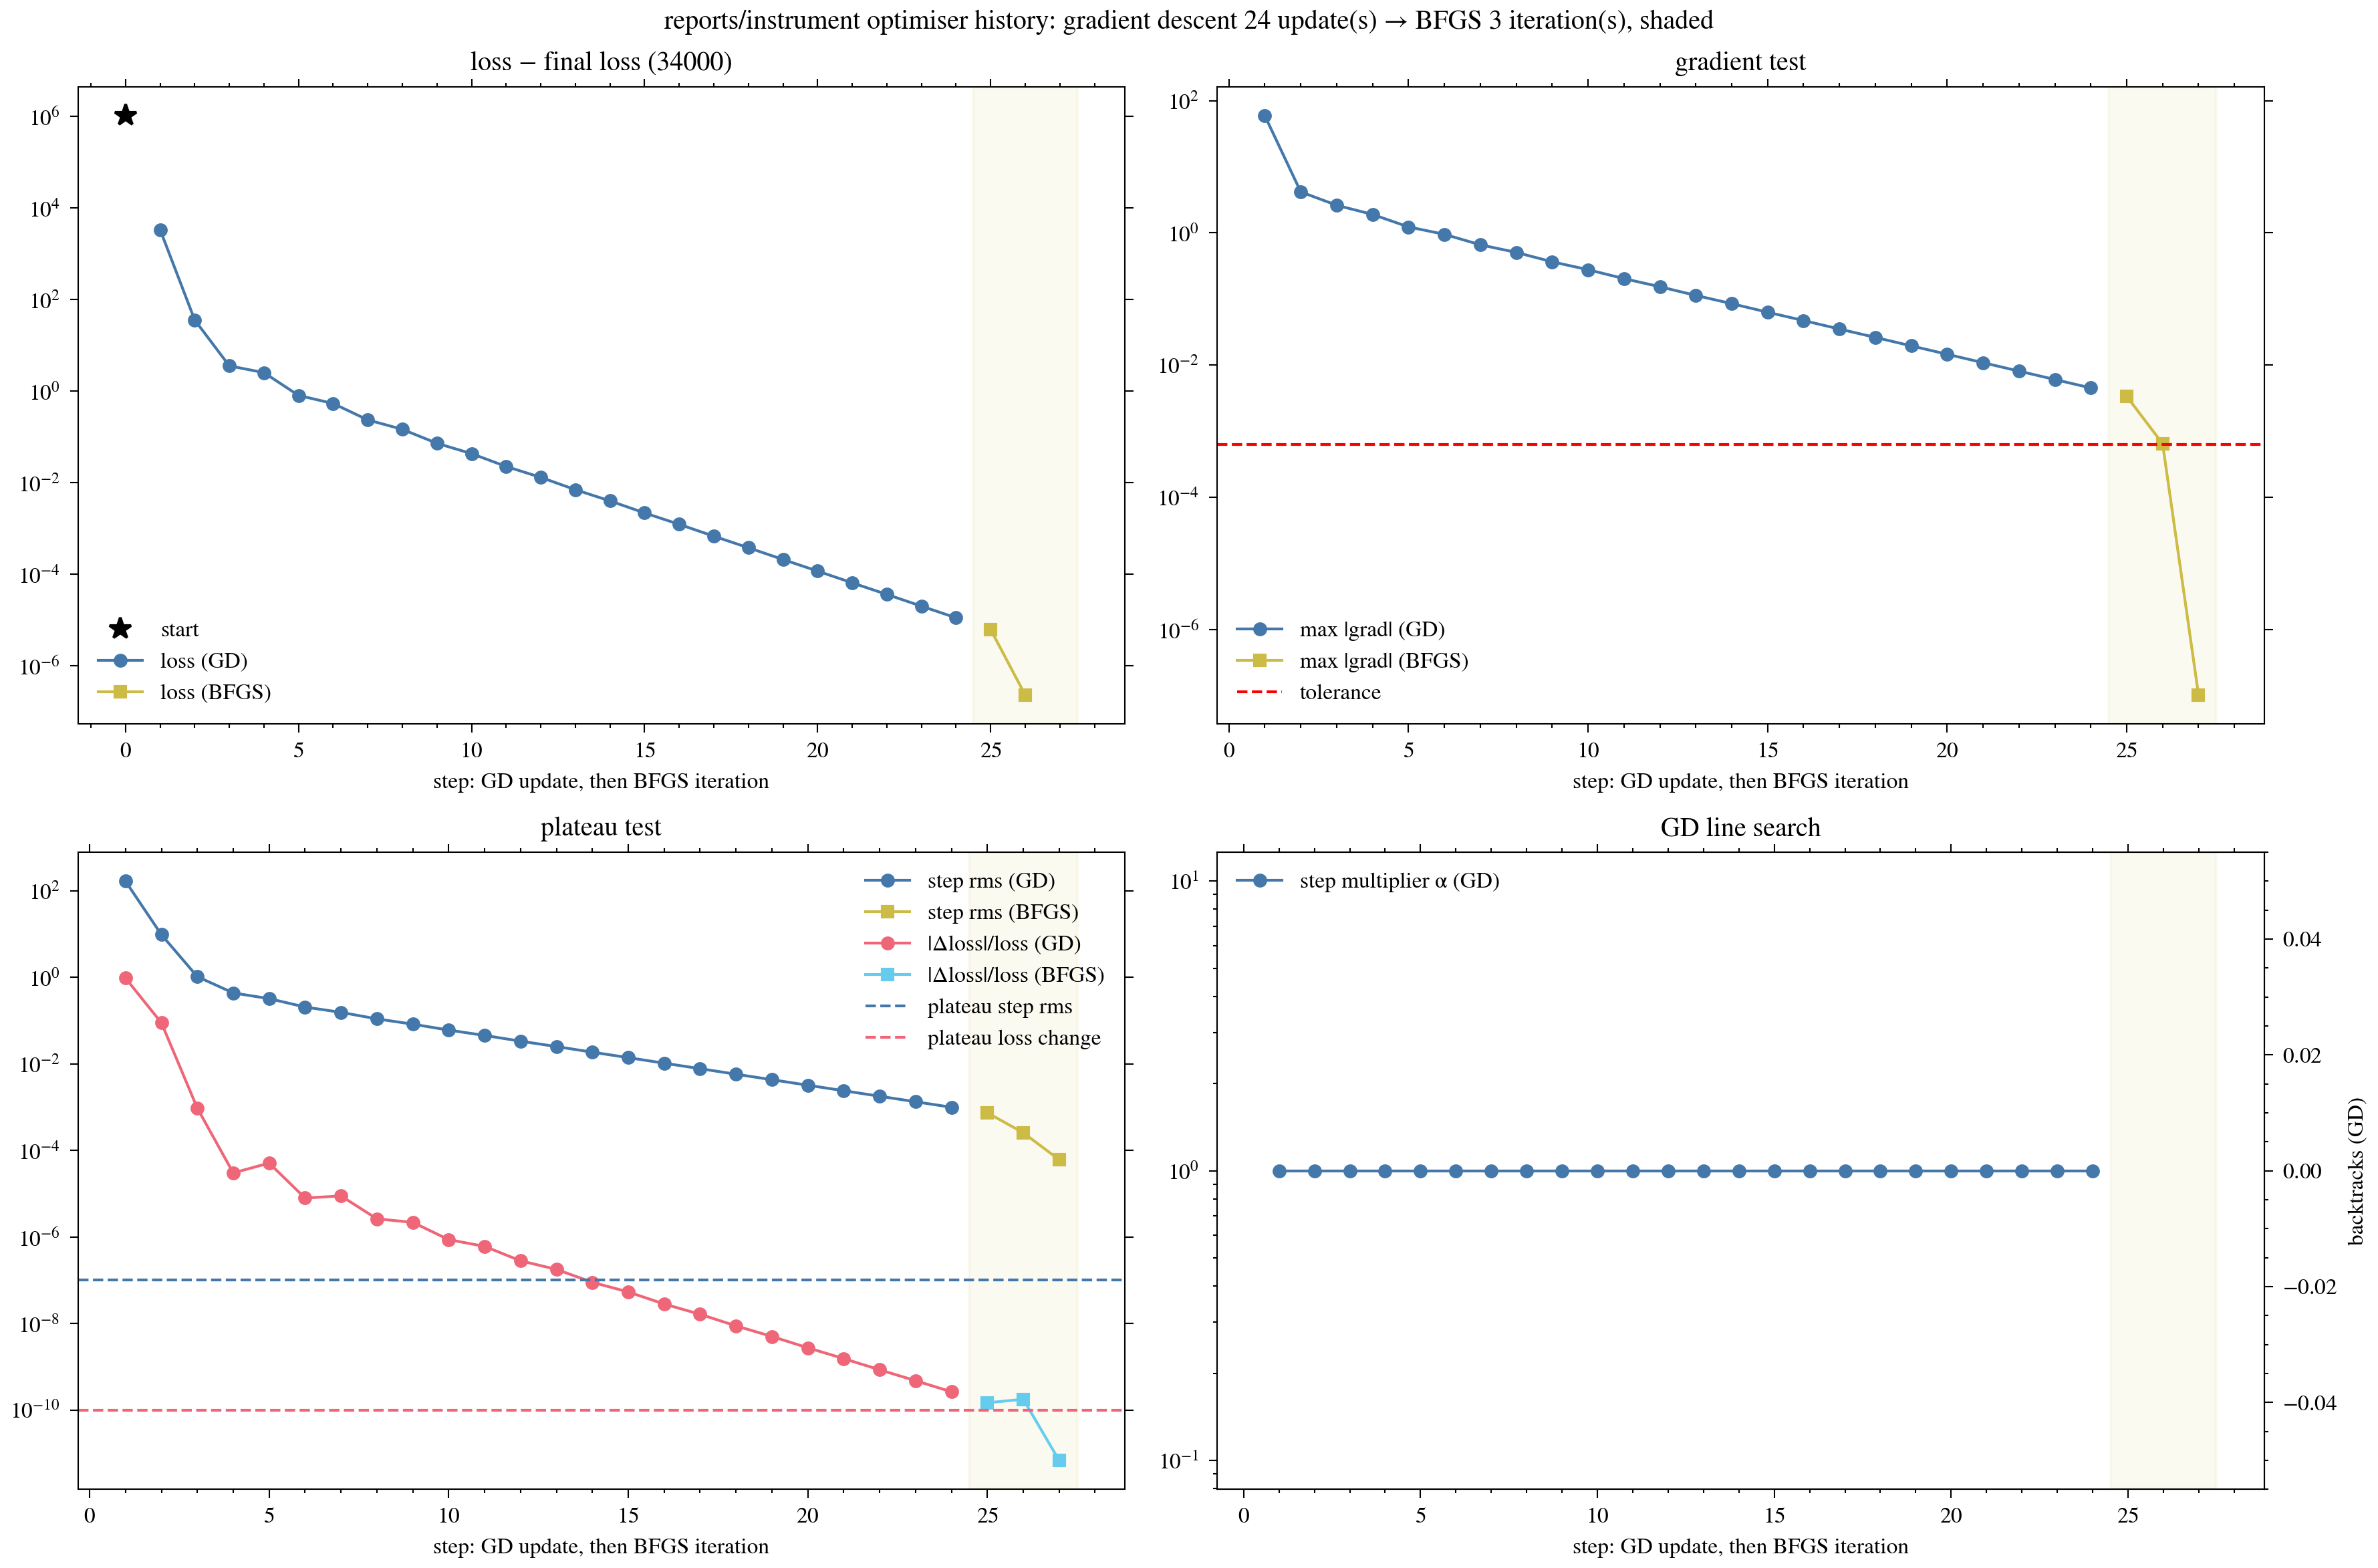

,value
preconditioner.method,exact_autodiff_jvp_vjp
preconditioner.finite_differences,False
preconditioner.checkpointed_residual,True
preconditioner.parameter_dimension,71
preconditioner.residual_dimension,45720
preconditioner.batch_size,2
preconditioner.relative_asymmetry,0.0
preconditioner.whitening_max_abs_error,0.0
preconditioner.eigenvalue_flooring,False
preconditioner.diagonal_scaling,True


#### `instrument` optimiser trajectories

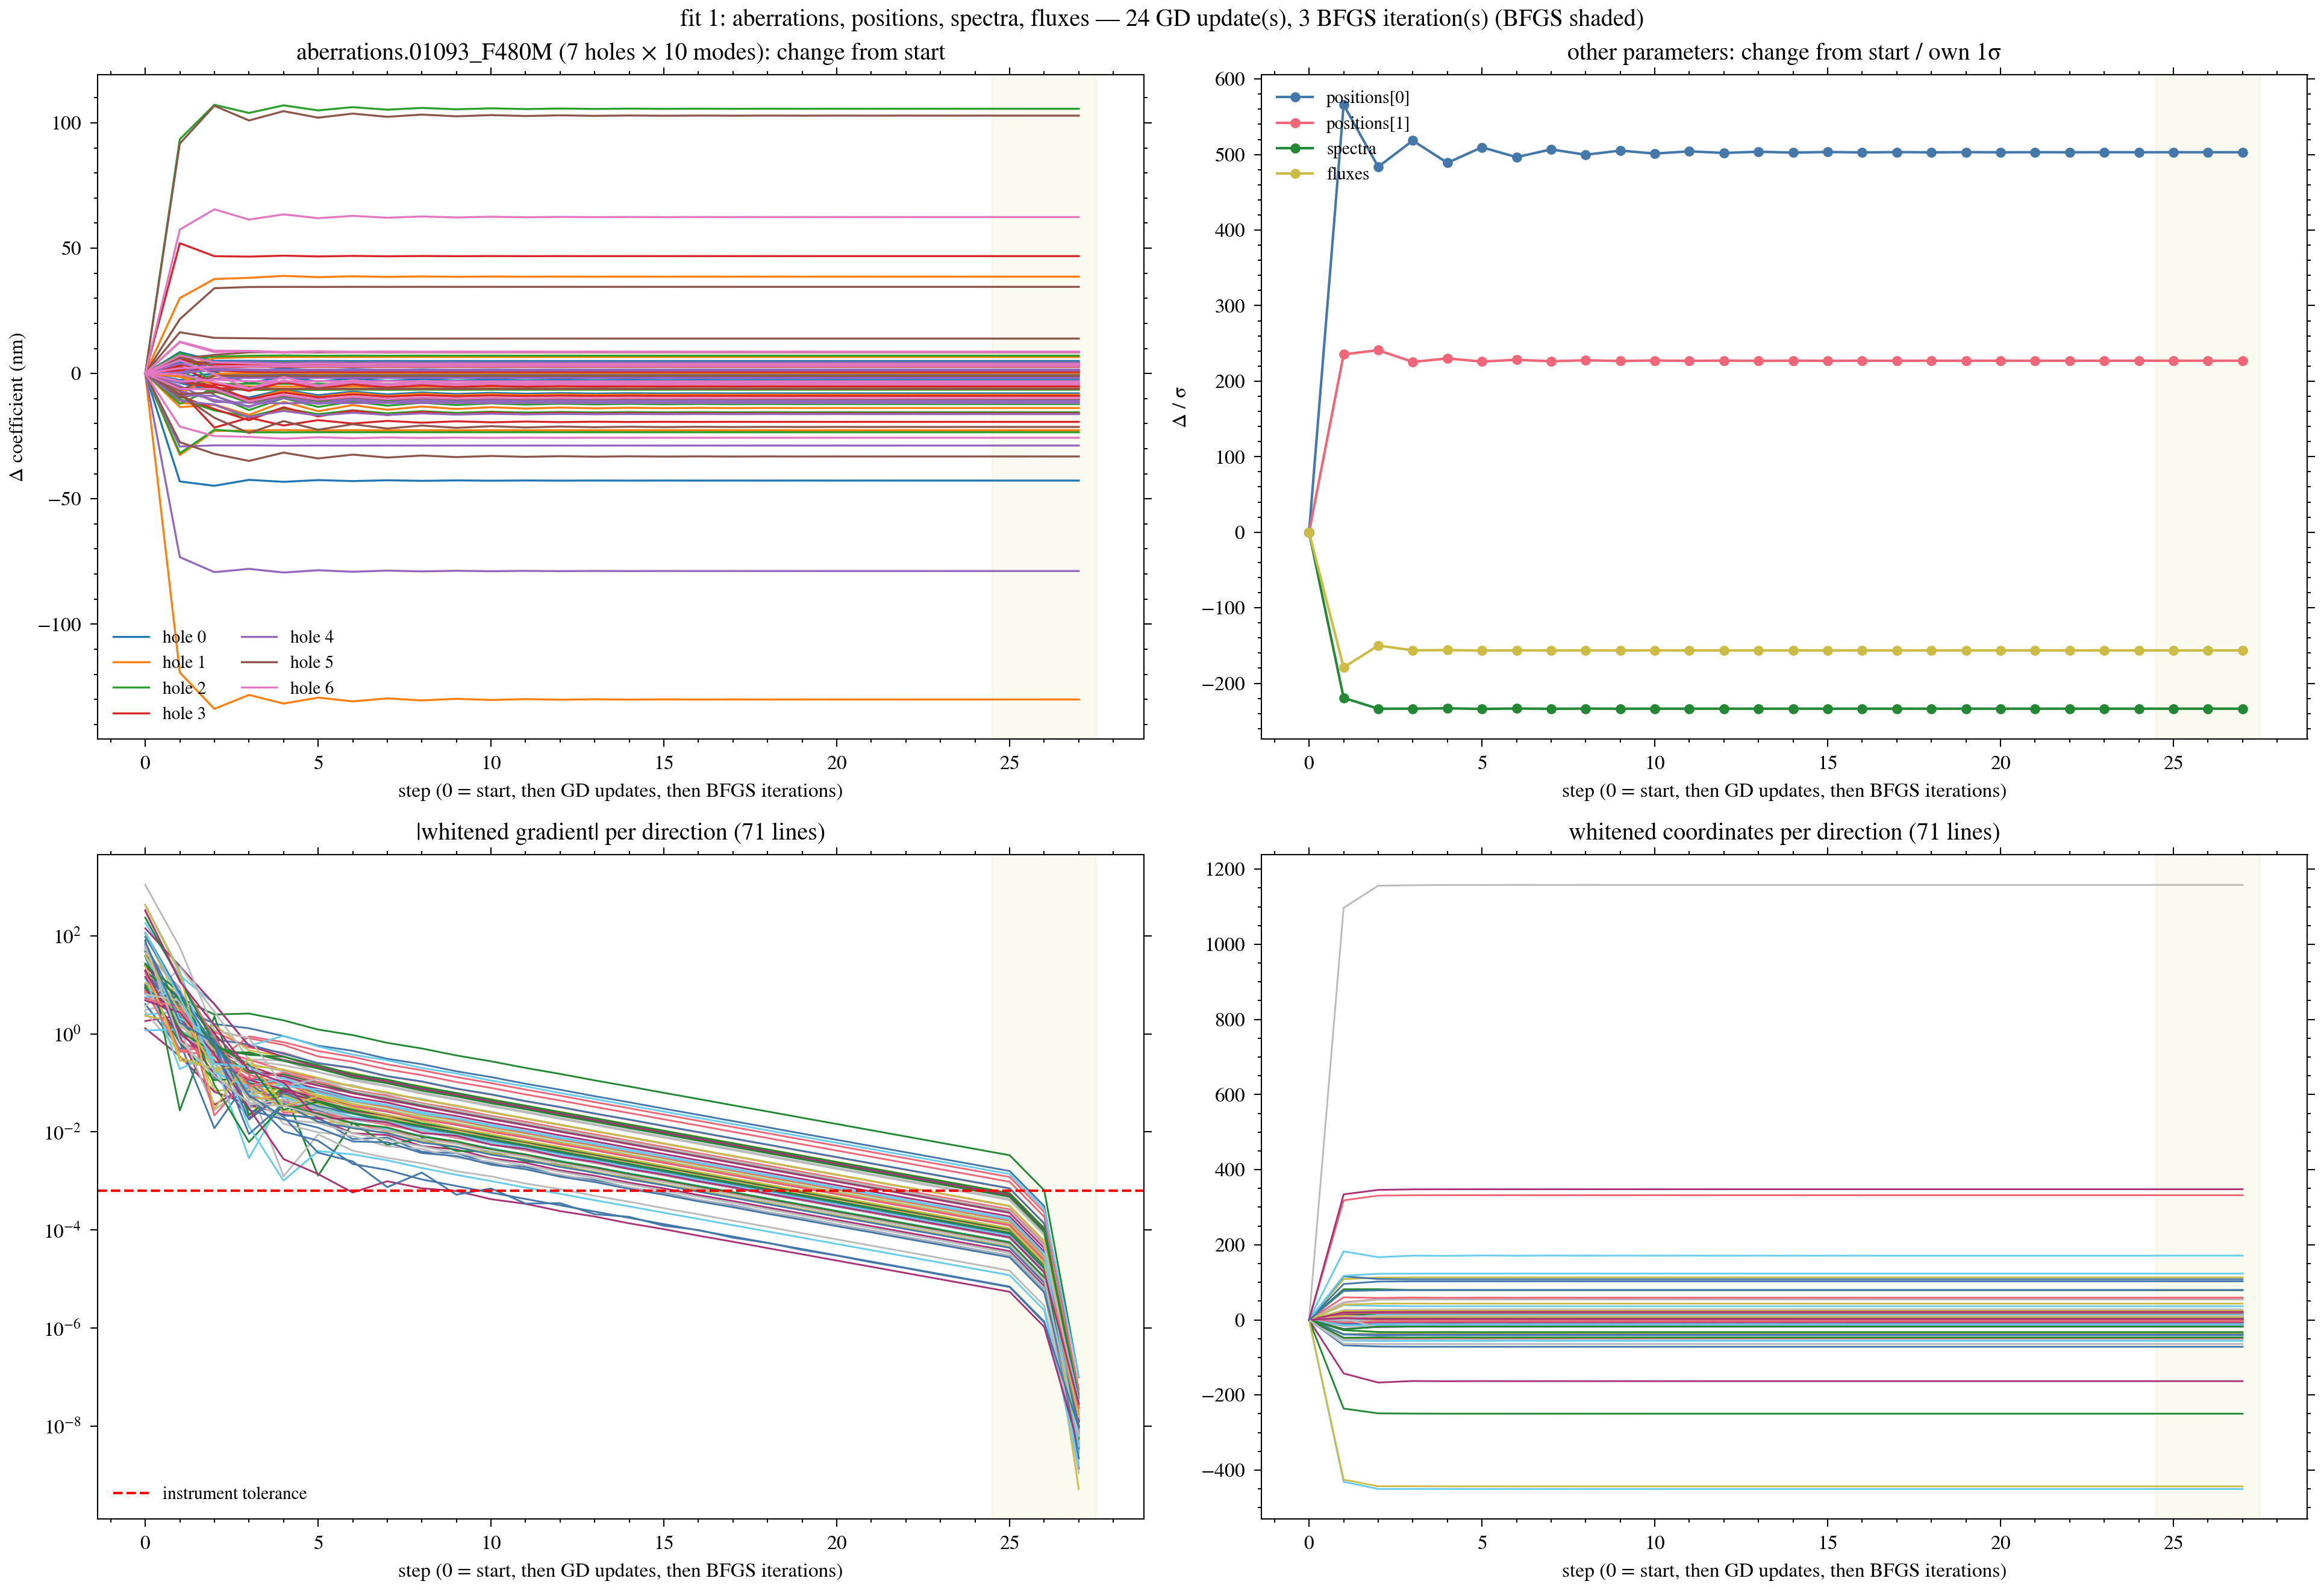

#### `instrument` outputs

File 01093_020_02_03_25
Star HD-36805
Filter F480M
nints 65
ngroups 9



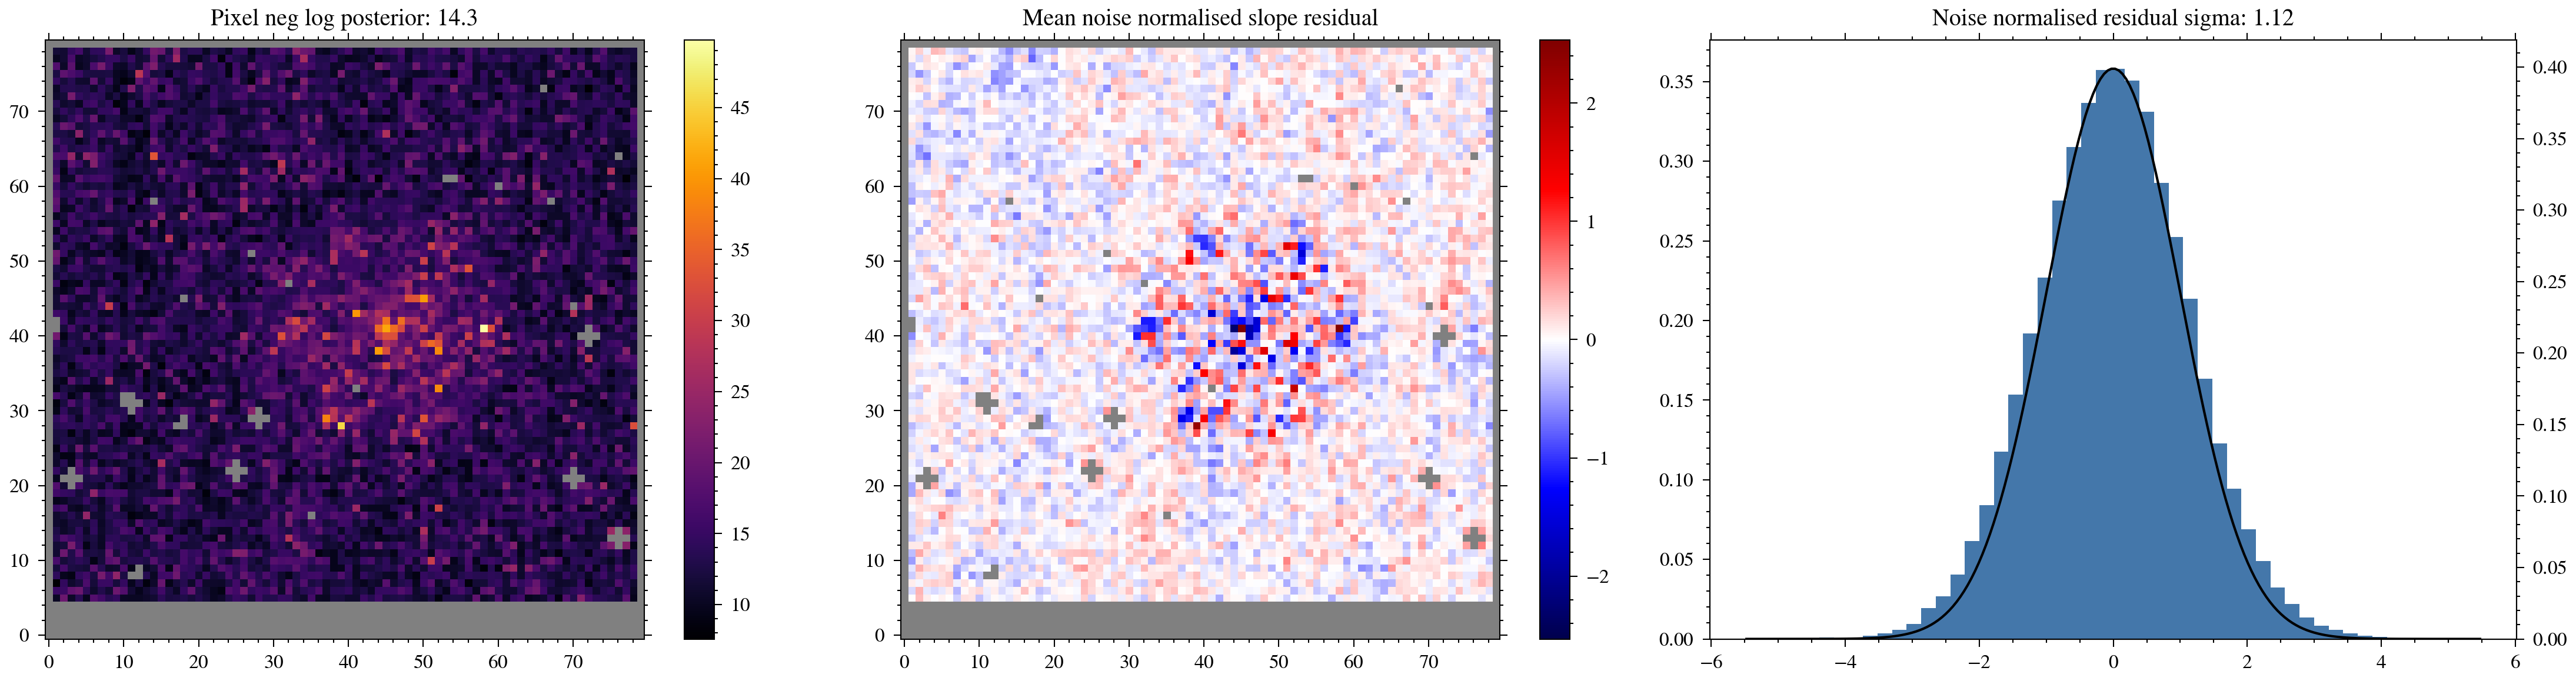

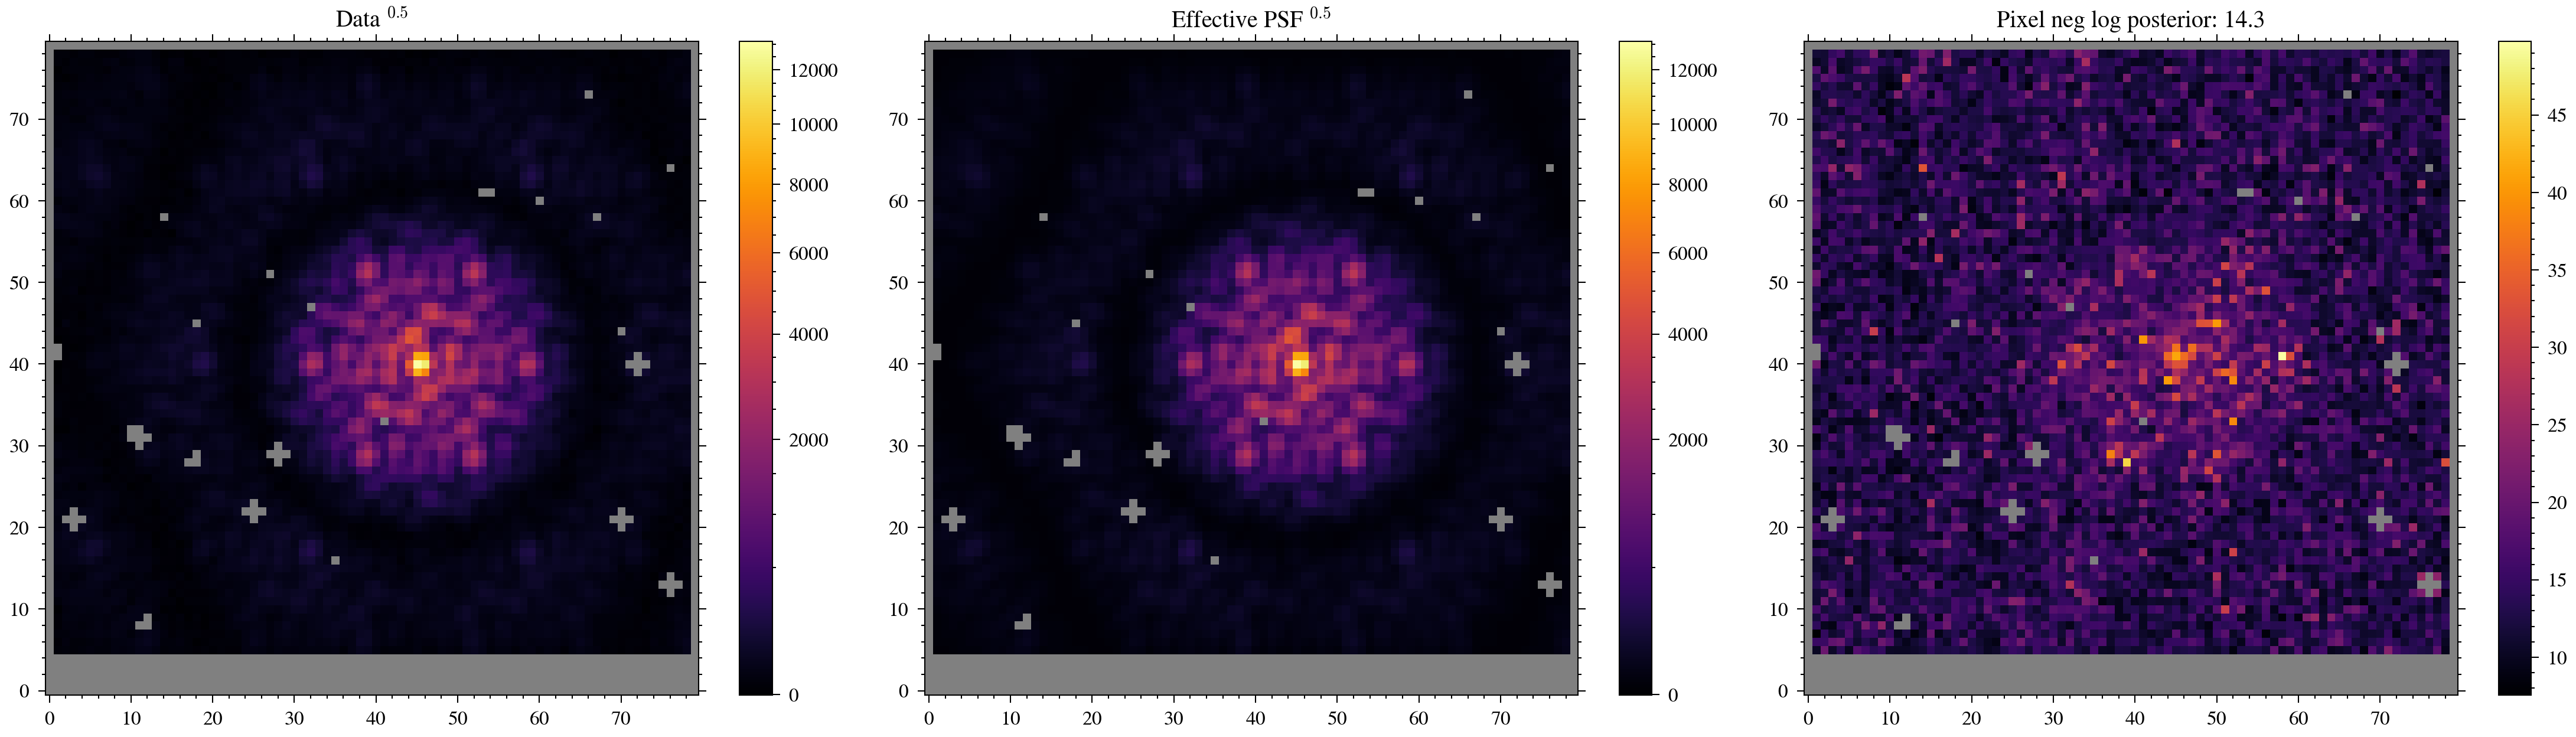

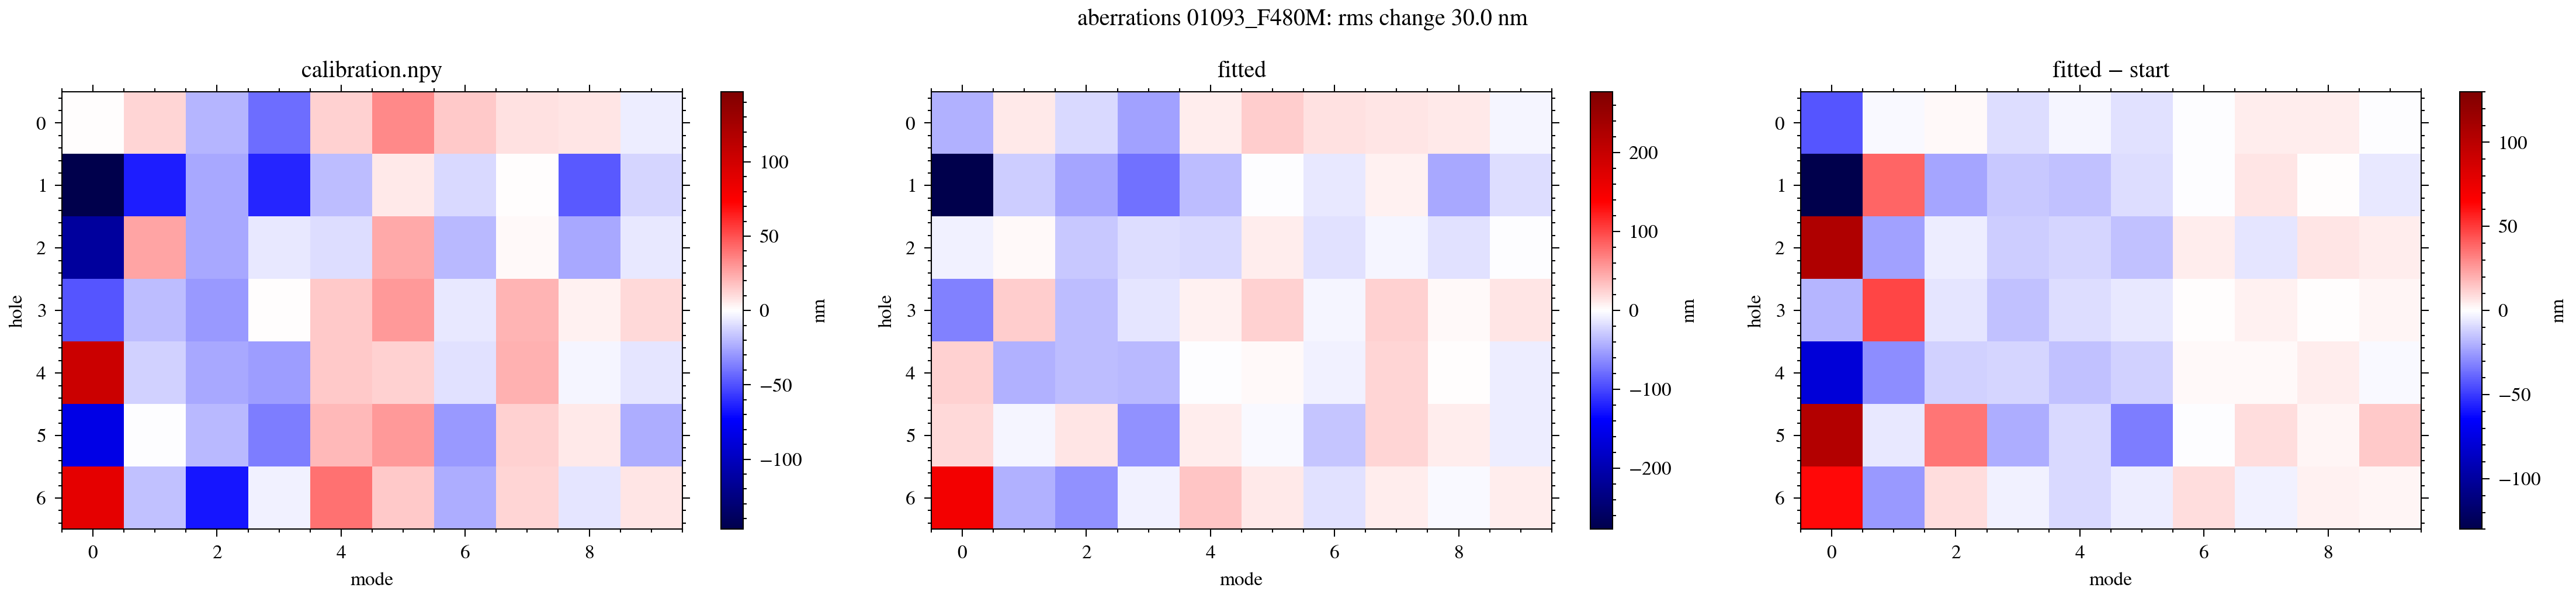

detector rotation: 0.561267 deg (not fitted)


In [16]:
run_stage("instrument")

### `science_reference`
The science exposures as point sources on the calibrated wavefront (held fixed); only position, flux and spectrum are fitted. Outputs: `summarise_fit` for each science exposure and the fitted nuisance parameters.

#### `science_reference` report

**reports/science_reference: accepted** (gradient (float64 floor)), loss 151484 → 85251.9  
fitted: positions.01093_014_02_03_5, spectra.AB-DOR_F480M, fluxes.01093_014_02_03_5  
parameter directions: 4 native, **4 optimised**, 0 held fixed as unidentified (unit-free (diagonally scaled) JTJ eigenvalues 0.896 … 1.09, cutoff 1.09e-08 = rank_rtol 1e-08 × largest)

**1. Gradient descent** (Armijo backtracking): 9 update(s) of at most 16; stopped: max |normalised gradient| 9.66e-06 reached the tolerance 1.2306e-05.

**2. BFGS** (SciPy, from where gradient descent stopped): 1 pass(es), 0 iteration(s) in total; final max |normalised gradient| 9.66e-06 (tolerance 1.2306e-05).
- pass 1: 0 iteration(s), 64 evaluation(s) — no progress: it could not find any step that lowers the loss (SciPy: "Desired error not necessarily achieved due to precision loss.")

Convergence tests (applied to the combined gradient-descent + BFGS history):

,passed,threshold
finite,True,
non_worsening,True,
gradient_gate,True,max |normalised gradient| < 1.2306e-05 (reques...
plateau_gate,False,3 steps with step_rms < 1e-07 and relative los...


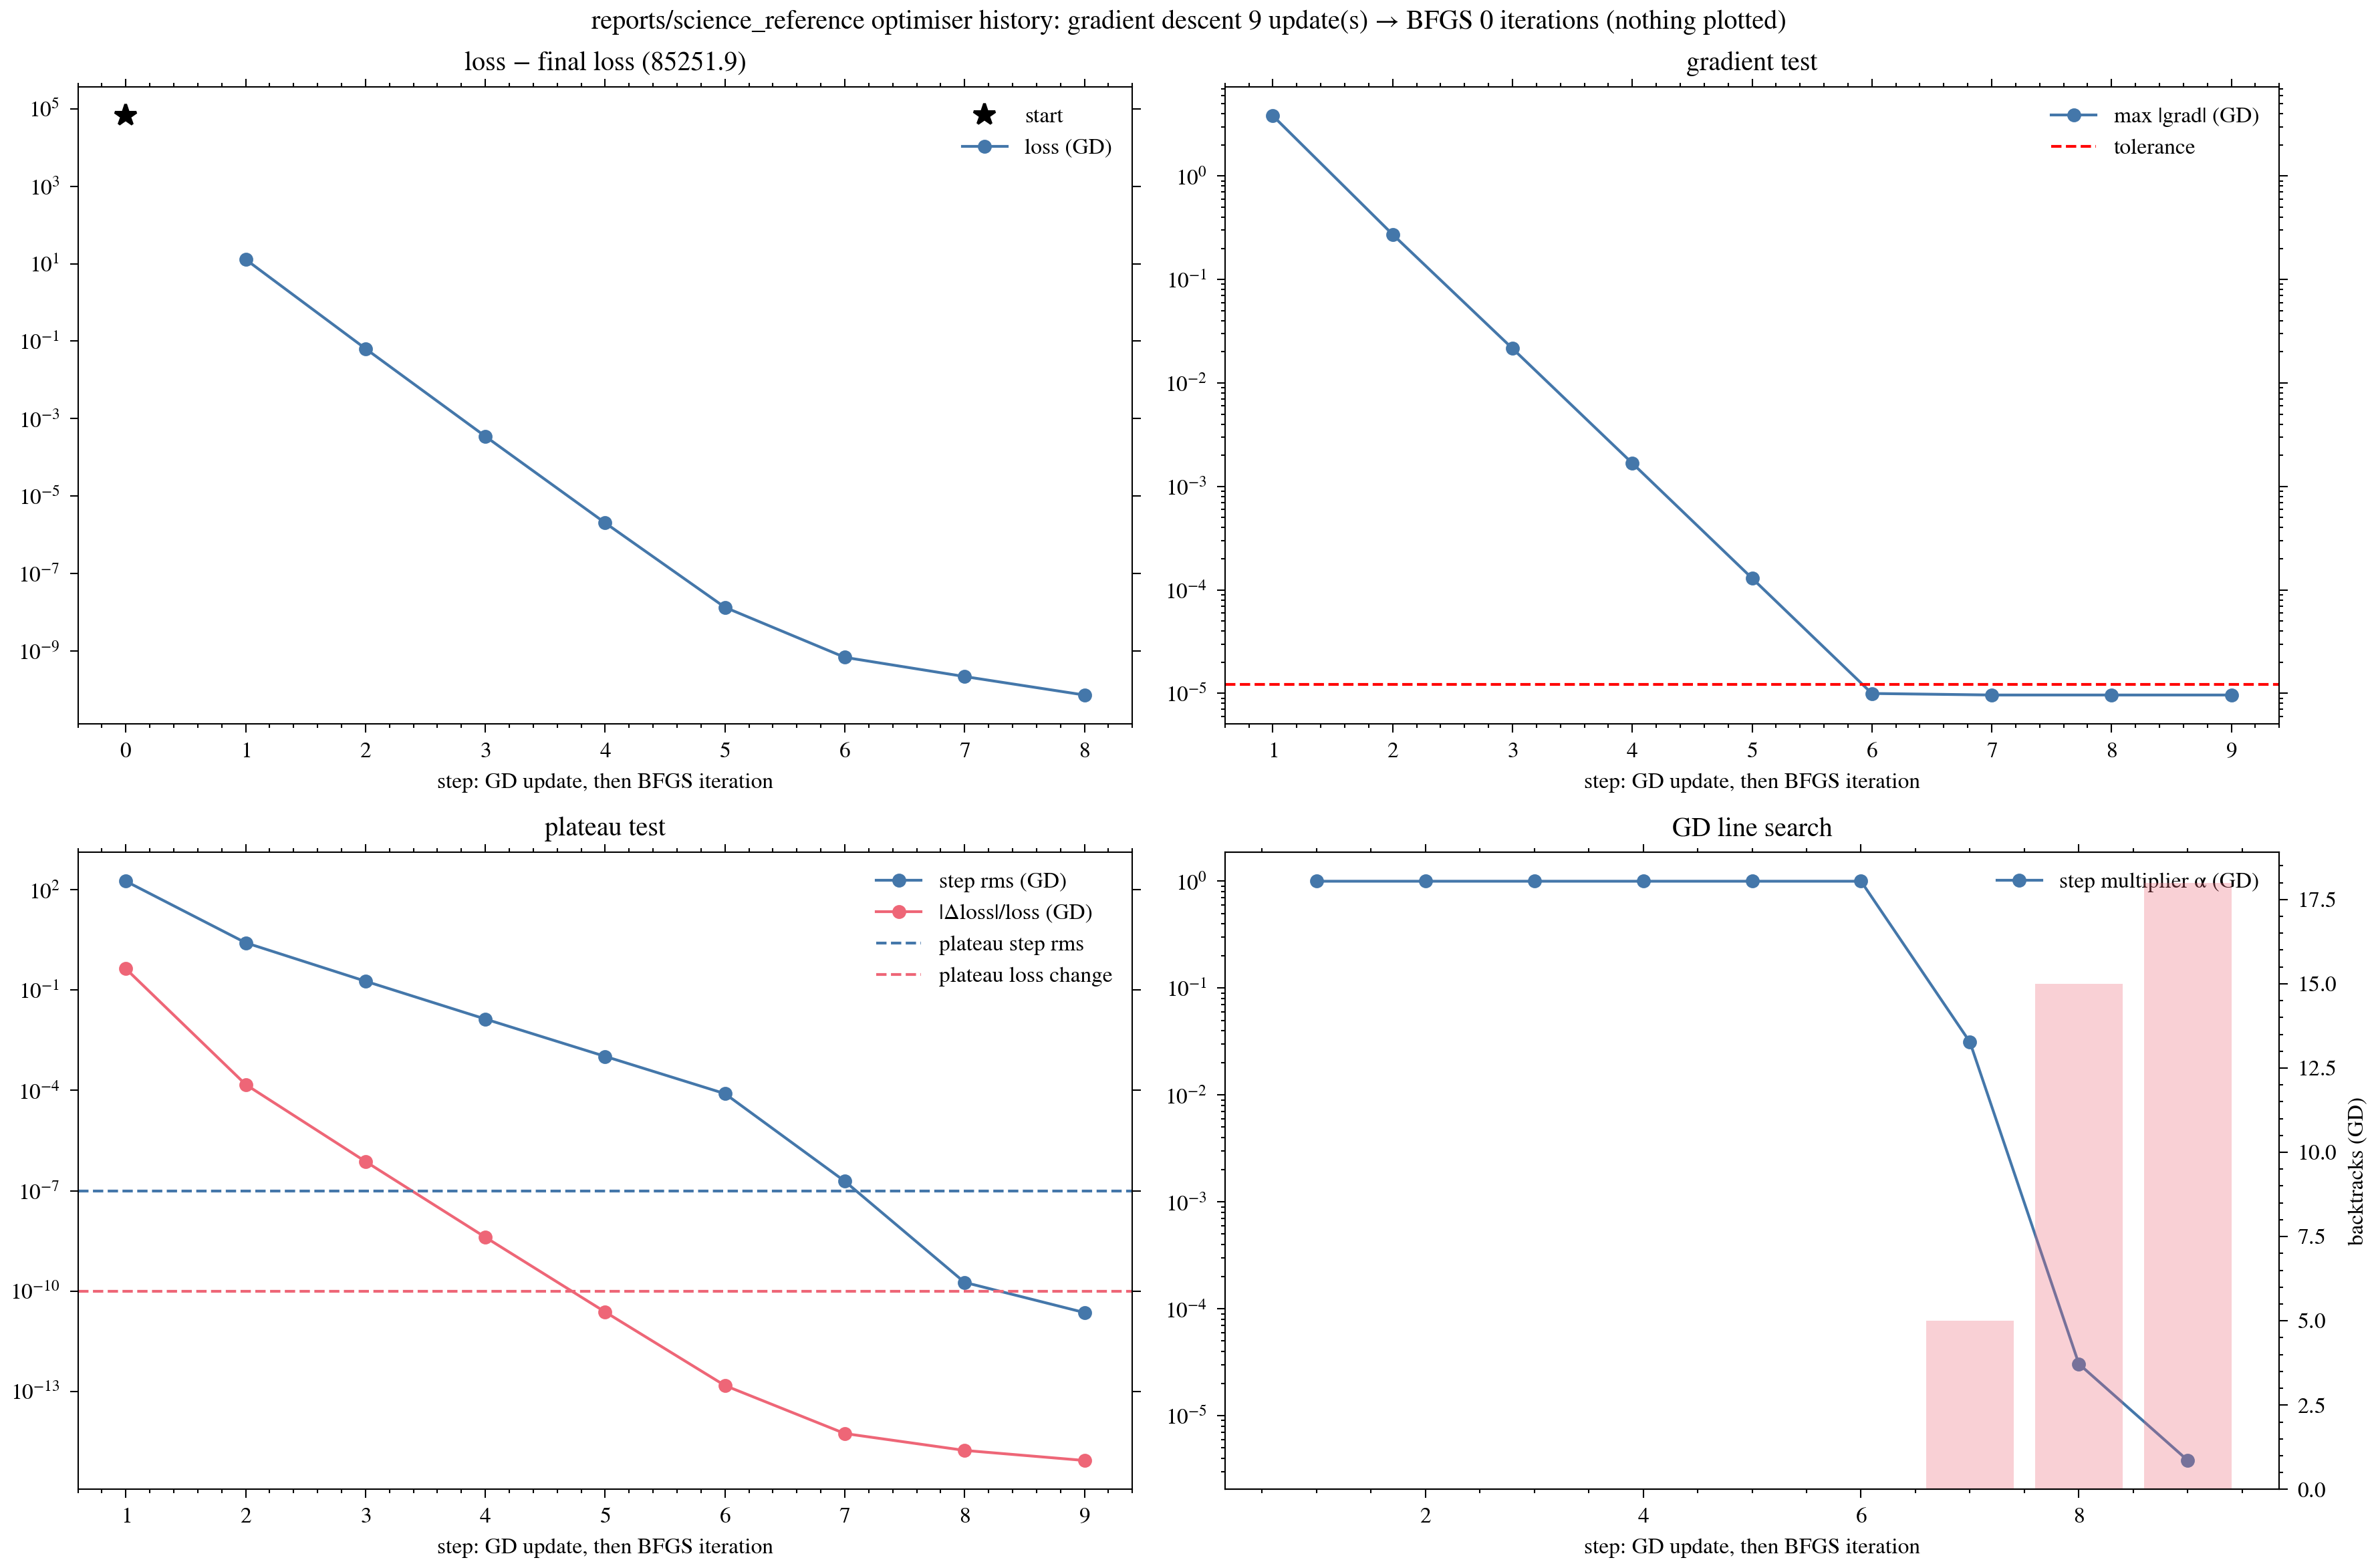

,value
preconditioner.method,exact_autodiff_jvp_vjp
preconditioner.finite_differences,False
preconditioner.checkpointed_residual,True
preconditioner.parameter_dimension,4
preconditioner.residual_dimension,22860
preconditioner.batch_size,2
preconditioner.relative_asymmetry,0.0
preconditioner.whitening_max_abs_error,0.0
preconditioner.eigenvalue_flooring,False
preconditioner.diagonal_scaling,True


#### `science_reference` optimiser trajectories

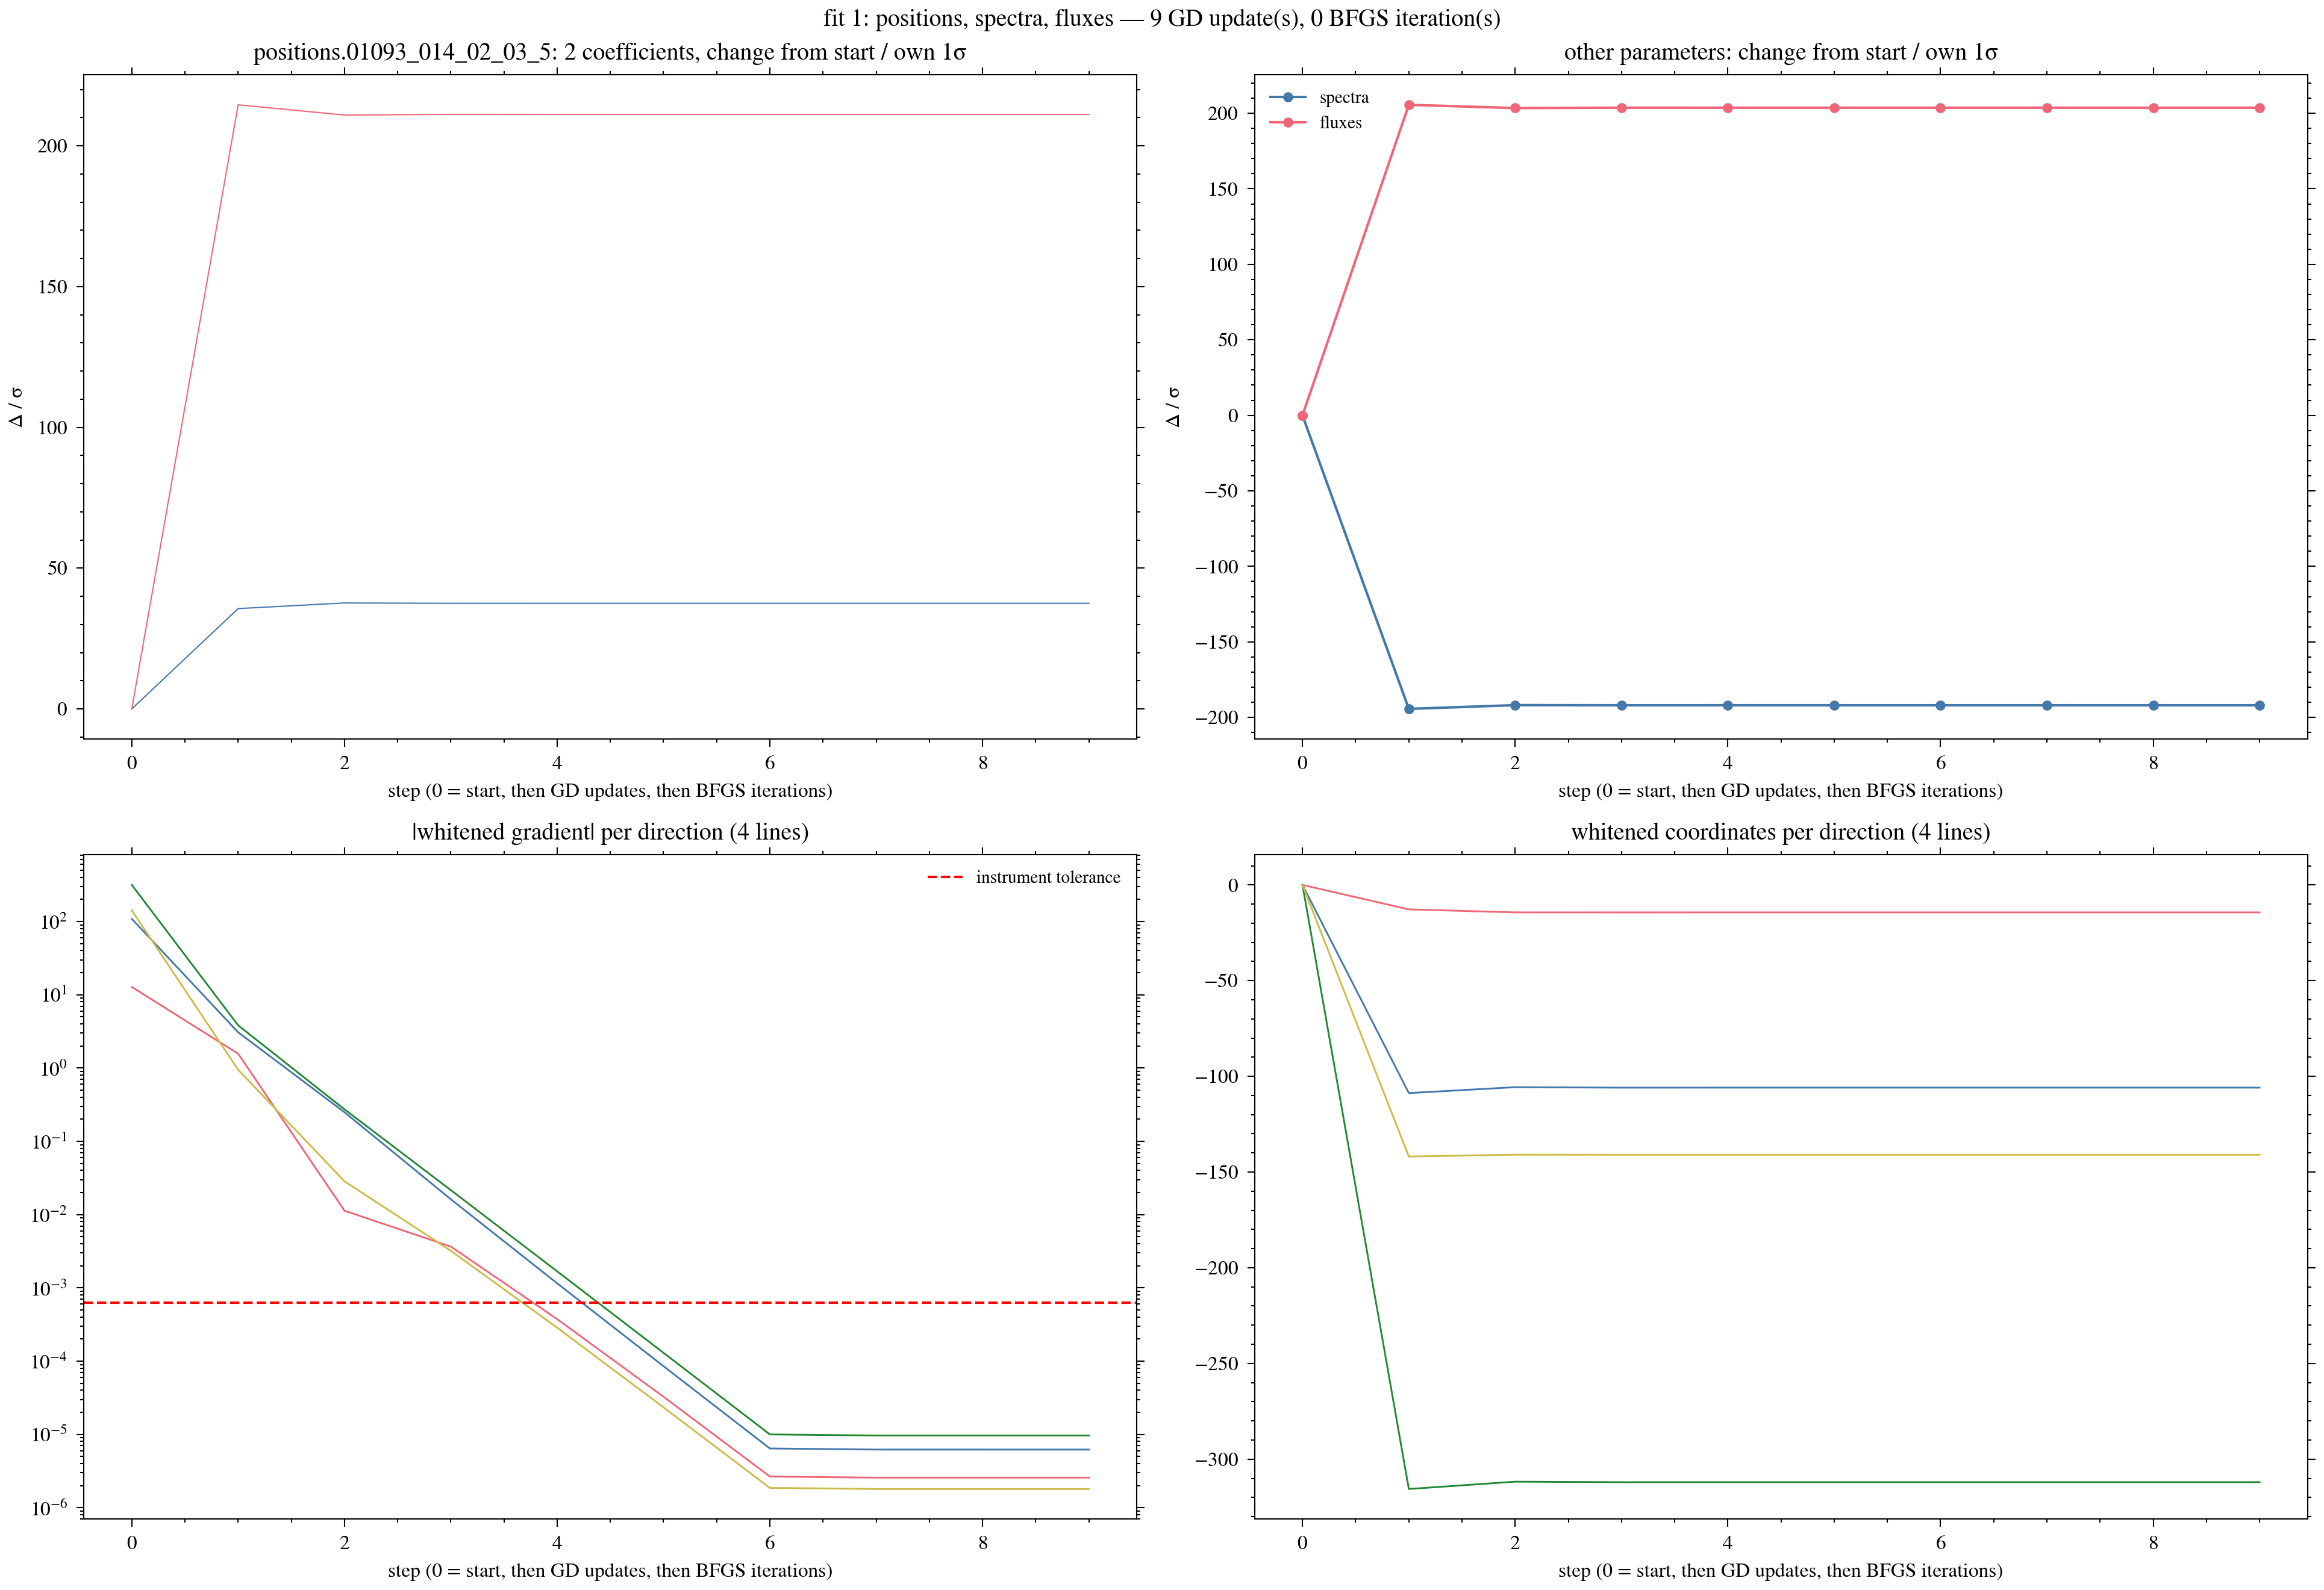

#### `science_reference` outputs

File 01093_014_02_03_5
Star AB-DOR
Filter F480M
nints 69
ngroups 5



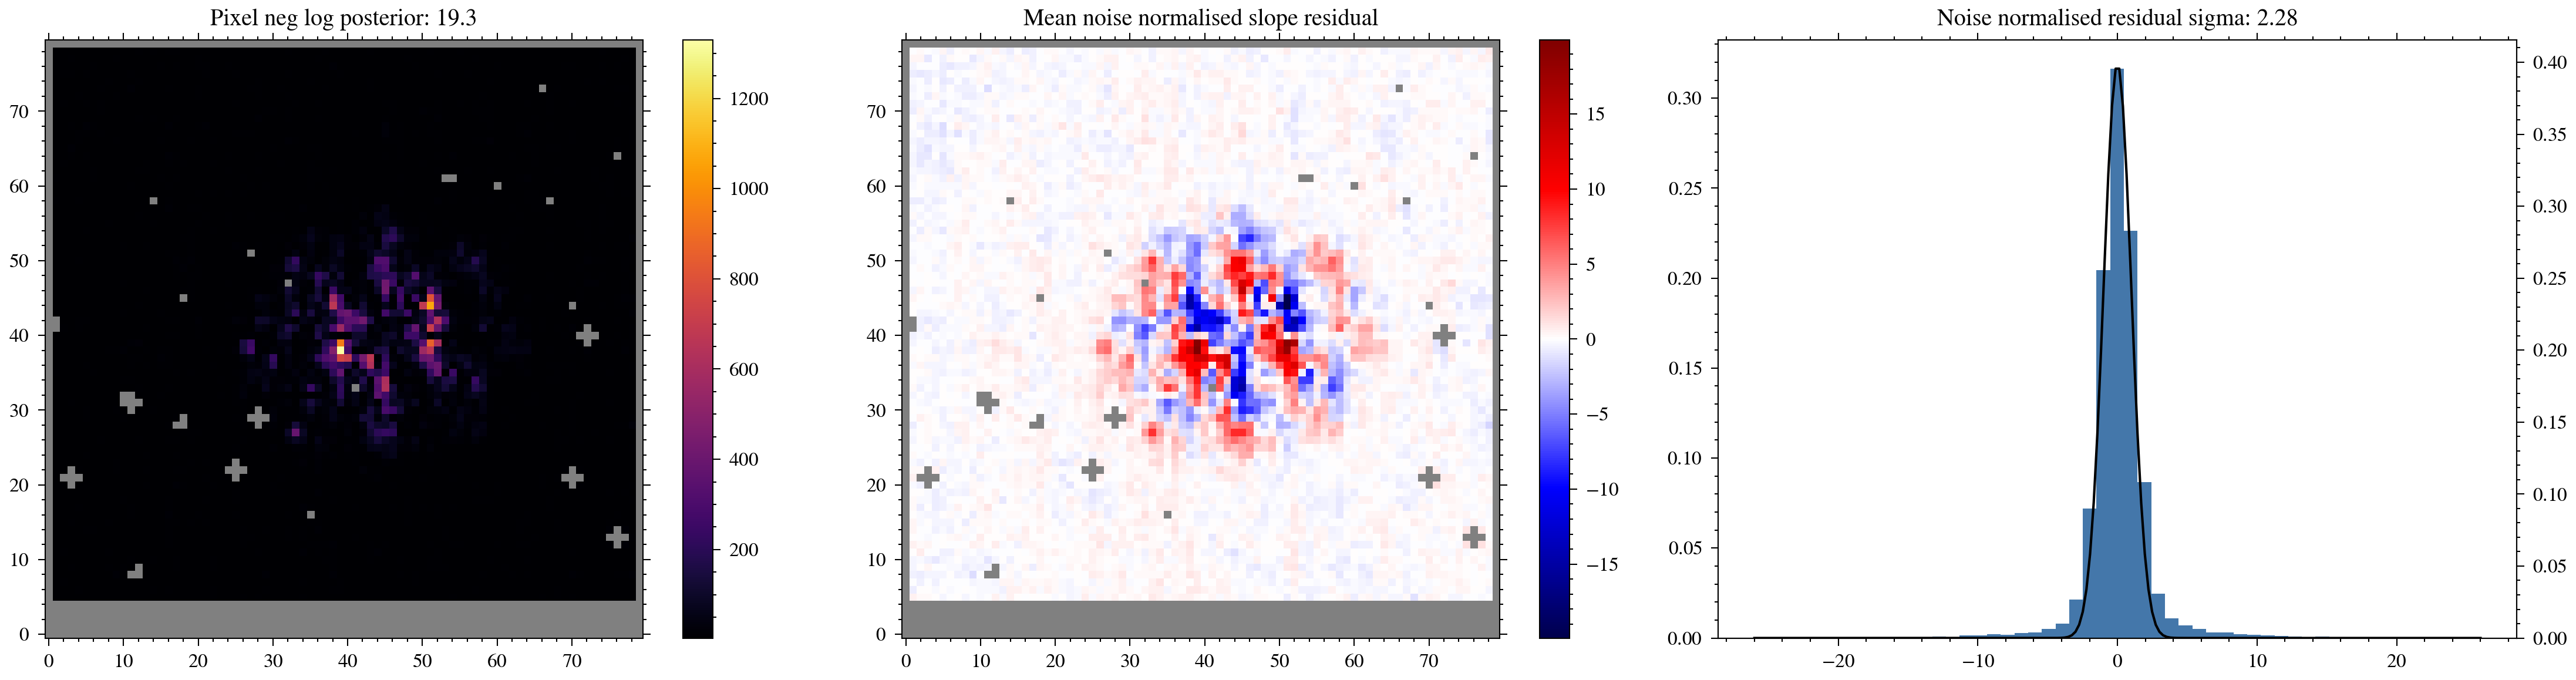

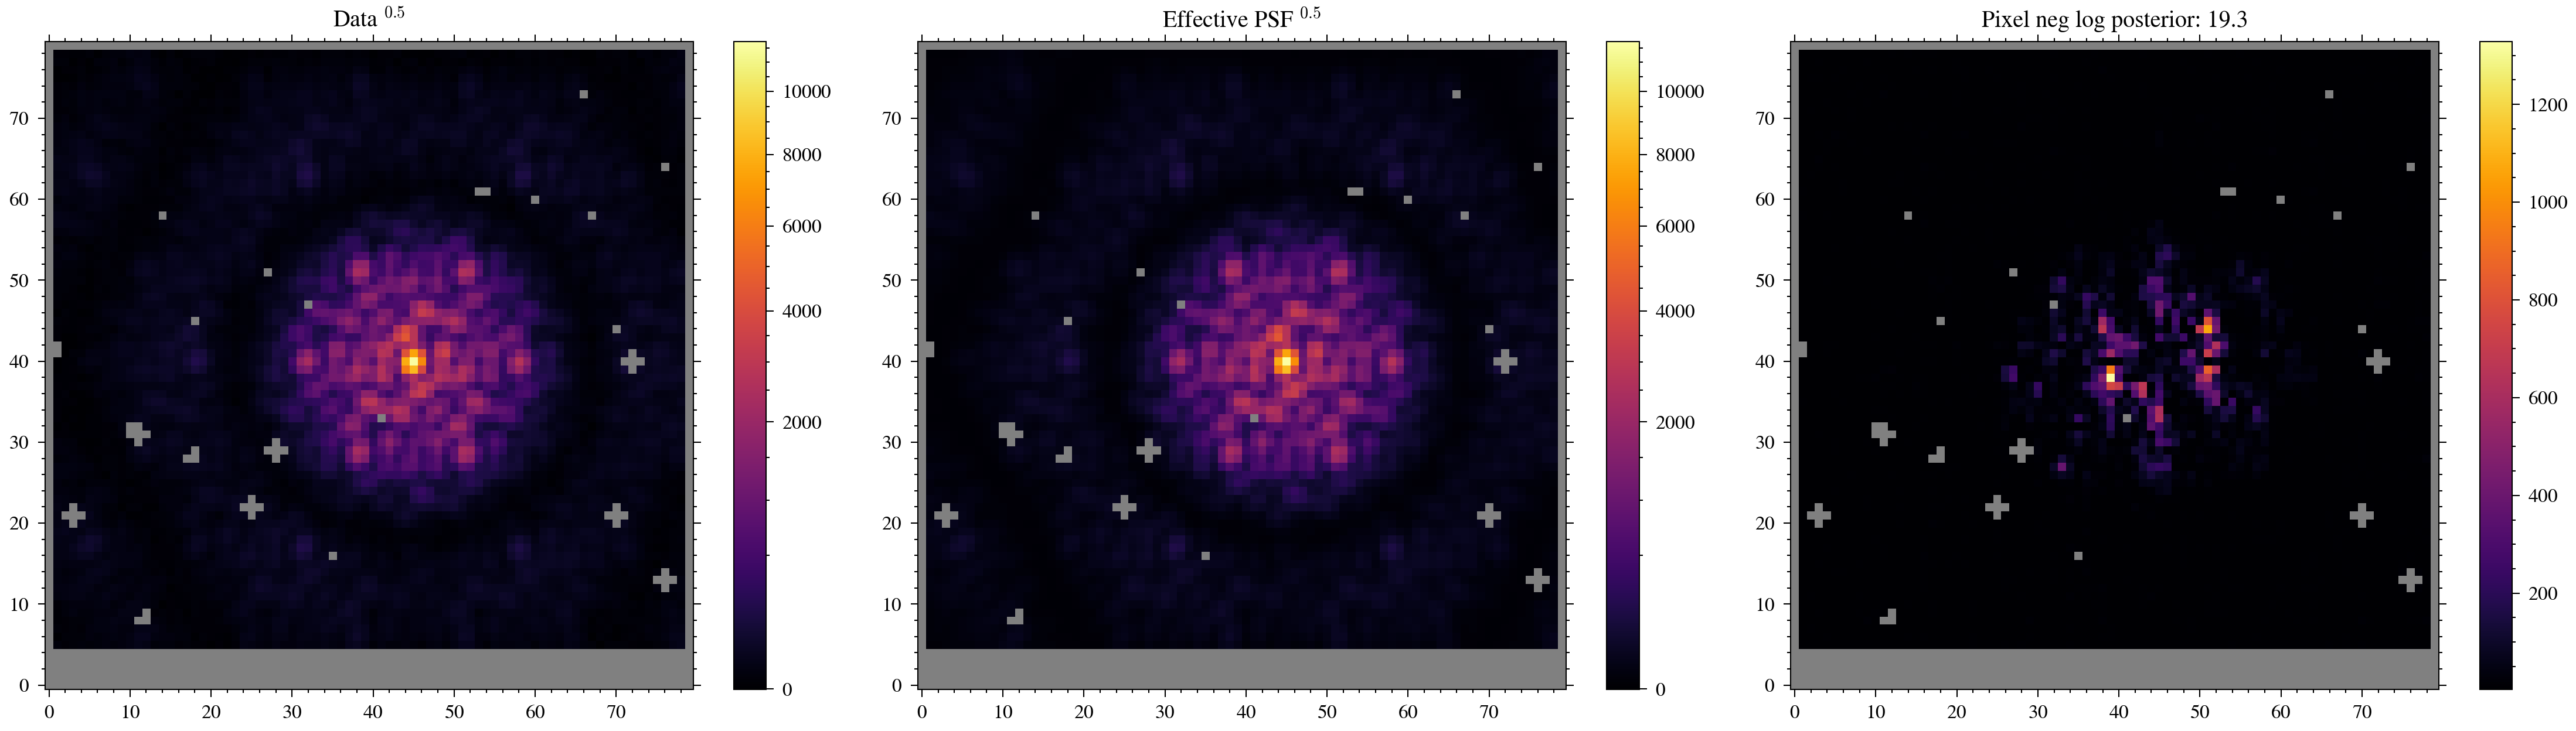

,position x (arcsec),position y (arcsec),flux,spectral slope
01093_014_02_03_5,0.344215,-0.025485,5.583308,-0.488686


In [17]:
run_stage("science_reference")

### `visibility_basis`
The per-filter mixed log-amplitude/phase basis, built from the calibrated optics alone and cut at `visibility_information` of its Fisher information. Outputs: the information spectrum and cut, where on the uv plane the retained modes reach, and the leading modes.

#### `visibility_basis` report

**reports/visibility_basis**

,value
schema,amigo-optical-mixed-visibility-basis-report-v1
filters.F480M.retained_modes,860
filters.F480M.psf_pixels,100
filters.F480M.selection.threshold,0.99
filters.F480M.selection.available_modes,3024
filters.F480M.selection.selected_modes,860
filters.F480M.selection.selected_information_fraction,0.990001
filters.F480M.orthogonality_max_abs,0.0
filters.F480M.jtj.method,exact_autodiff_jvp_vjp
filters.F480M.jtj.finite_differences,False


#### `visibility_basis` outputs

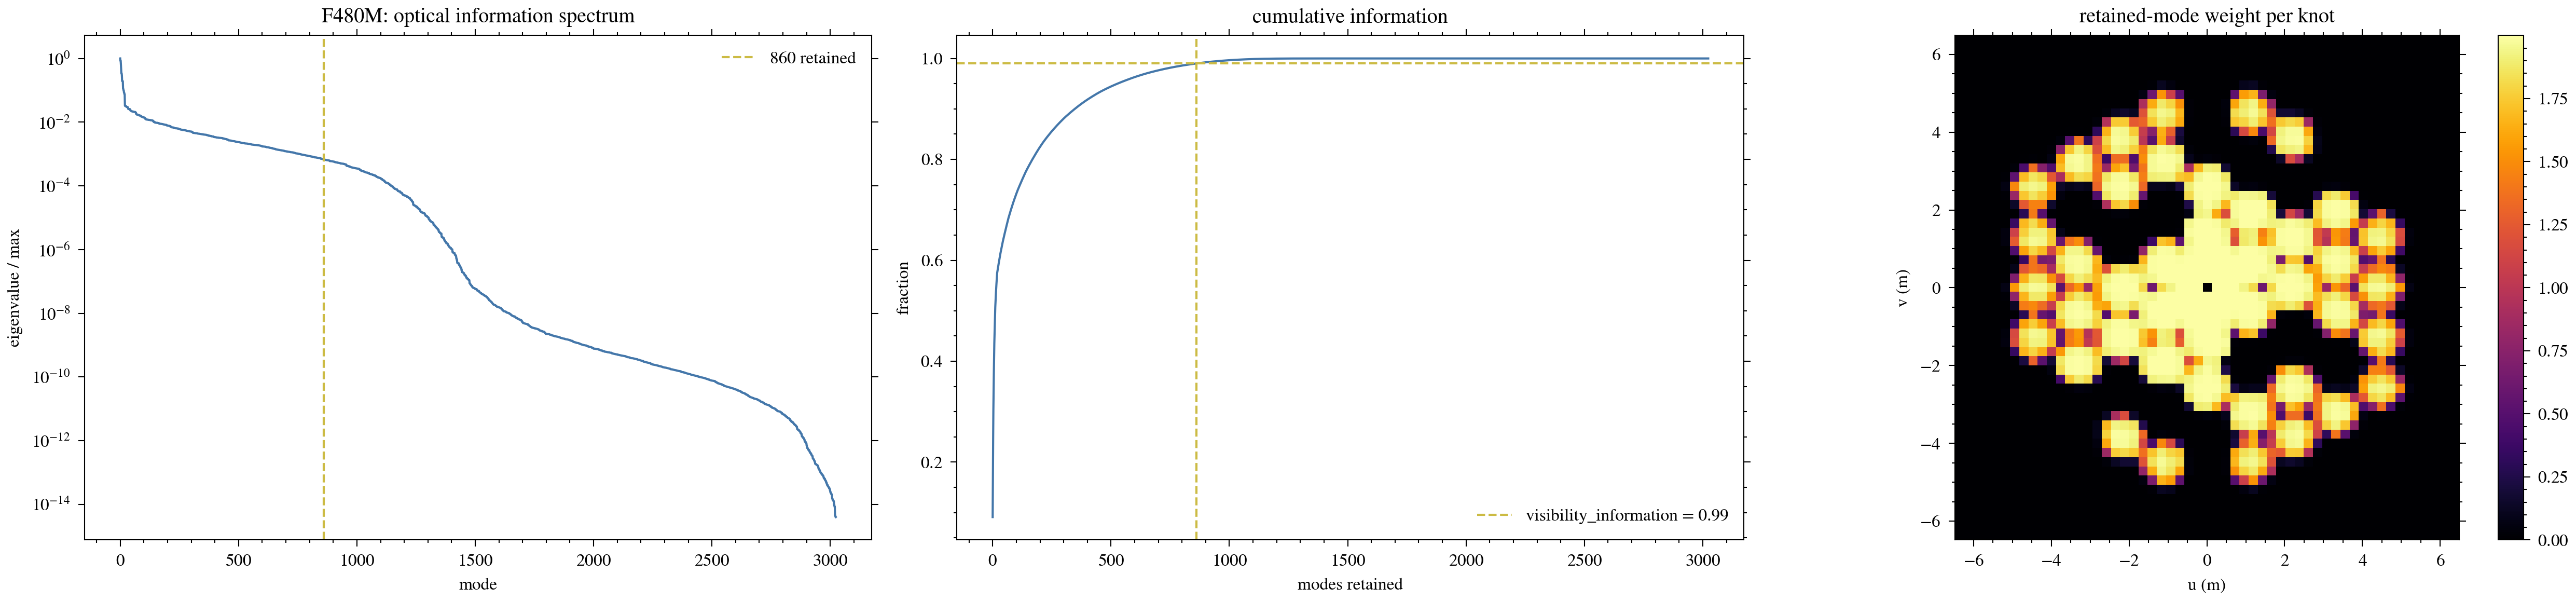

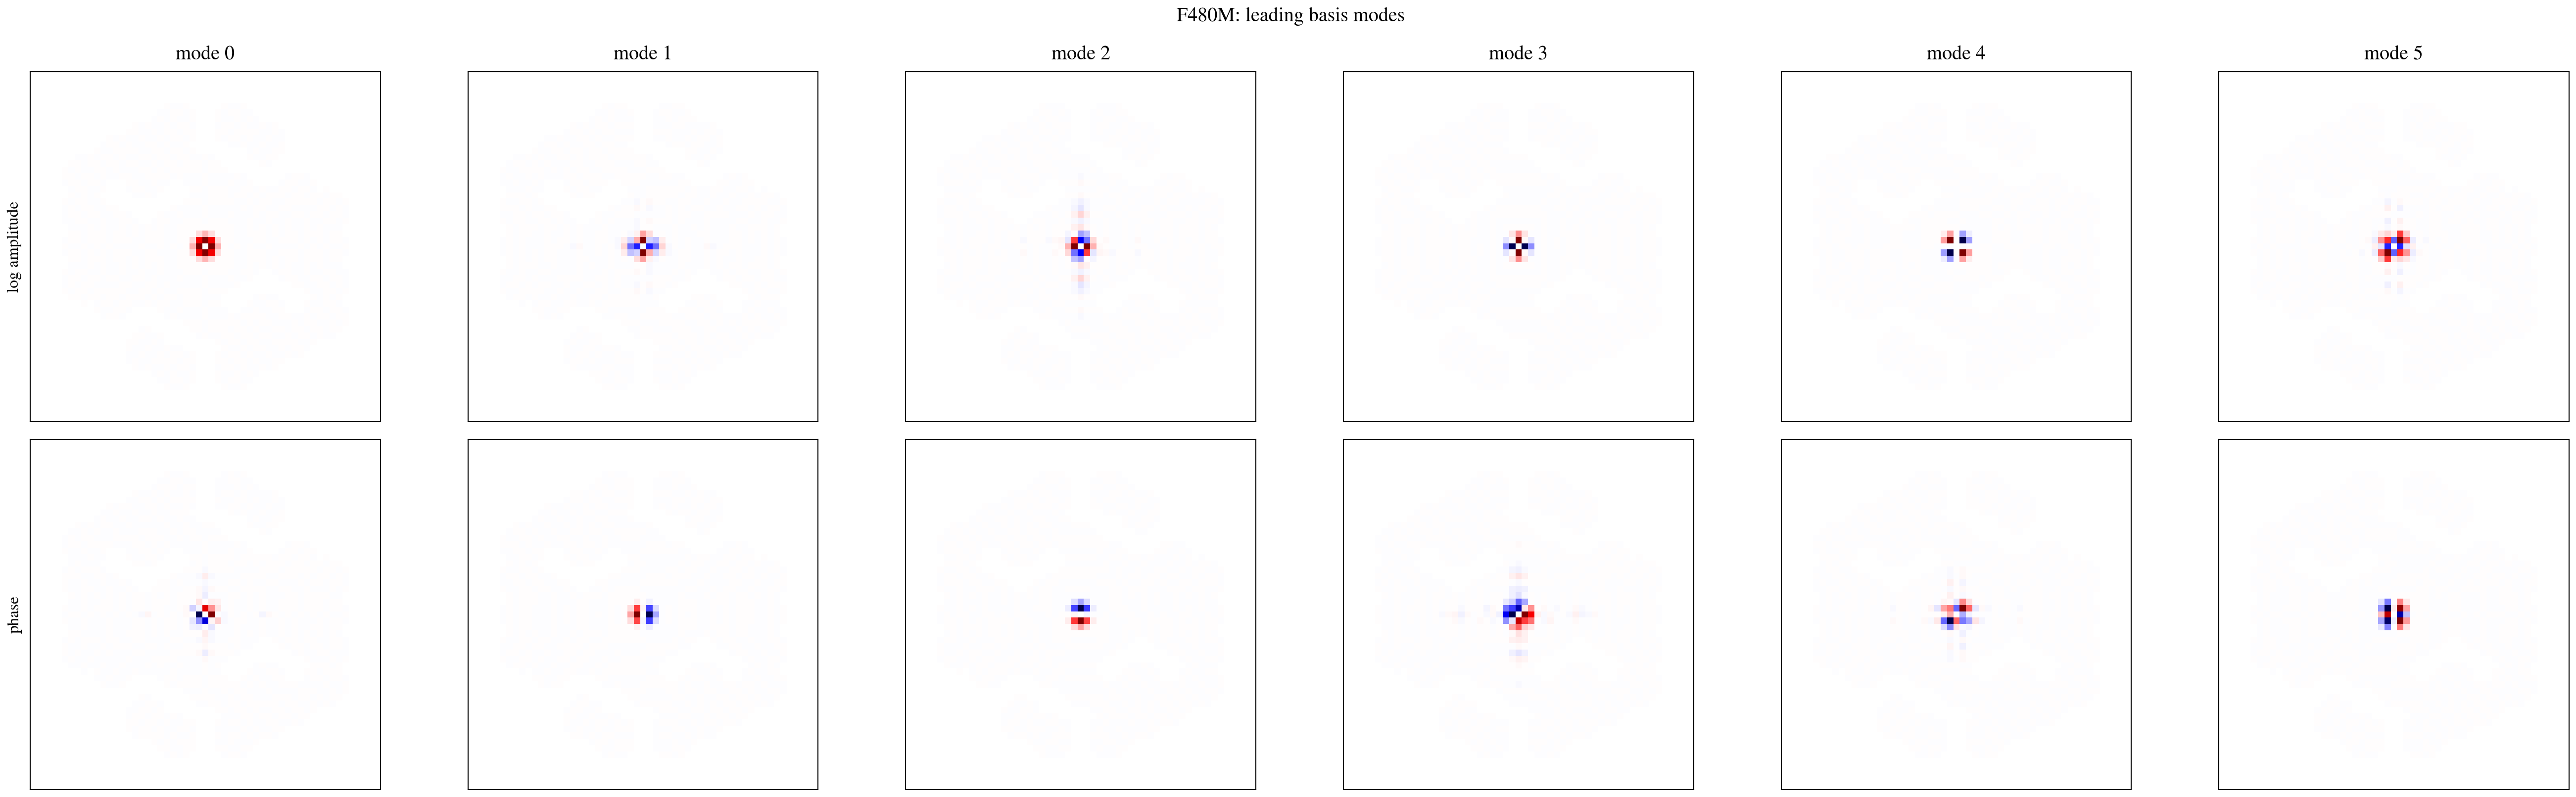

In [18]:
run_stage("visibility_basis")

### `visibility_fits`
Each star refitted with its own visibilities free (in the retained basis), on the same wavefront. Outputs: `summarise_fit` for each exposure and the fitted visibilities on the uv plane.

#### `visibility_fits` report

**reports/visibility_fits/F480M/calibrator/HD-36805: accepted** (gradient), loss 34000 → 31414.3  
fitted: amplitudes.HD-36805_F480M, positions.01093_020_02_03_25, spectra.HD-36805_F480M, fluxes.01093_020_02_03_25  
parameter directions: 864 native, **864 optimised**, 0 held fixed as unidentified (unit-free (diagonally scaled) JTJ eigenvalues 0.00357 … 2.09, cutoff 2.09e-08 = rank_rtol 1e-08 × largest)

**1. Gradient descent** (Armijo backtracking): 5 update(s) of at most 24; stopped: max |normalised gradient| 7.49e-07 reached the tolerance 7.47015e-06.

**2. BFGS** (SciPy, from where gradient descent stopped): 1 pass(es), 0 iteration(s) in total; final max |normalised gradient| 7.49e-07 (tolerance 7.47015e-06).
- pass 1: 0 iteration(s), 1 evaluation(s) — nothing to do: its starting gradient was already below tolerance (SciPy: "Optimization terminated successfully.")

Convergence tests (applied to the combined gradient-descent + BFGS history):

,passed,threshold
finite,True,
non_worsening,True,
gradient_gate,True,max |normalised gradient| < 7.47015e-06 (reque...
plateau_gate,False,3 steps with step_rms < 1e-07 and relative los...


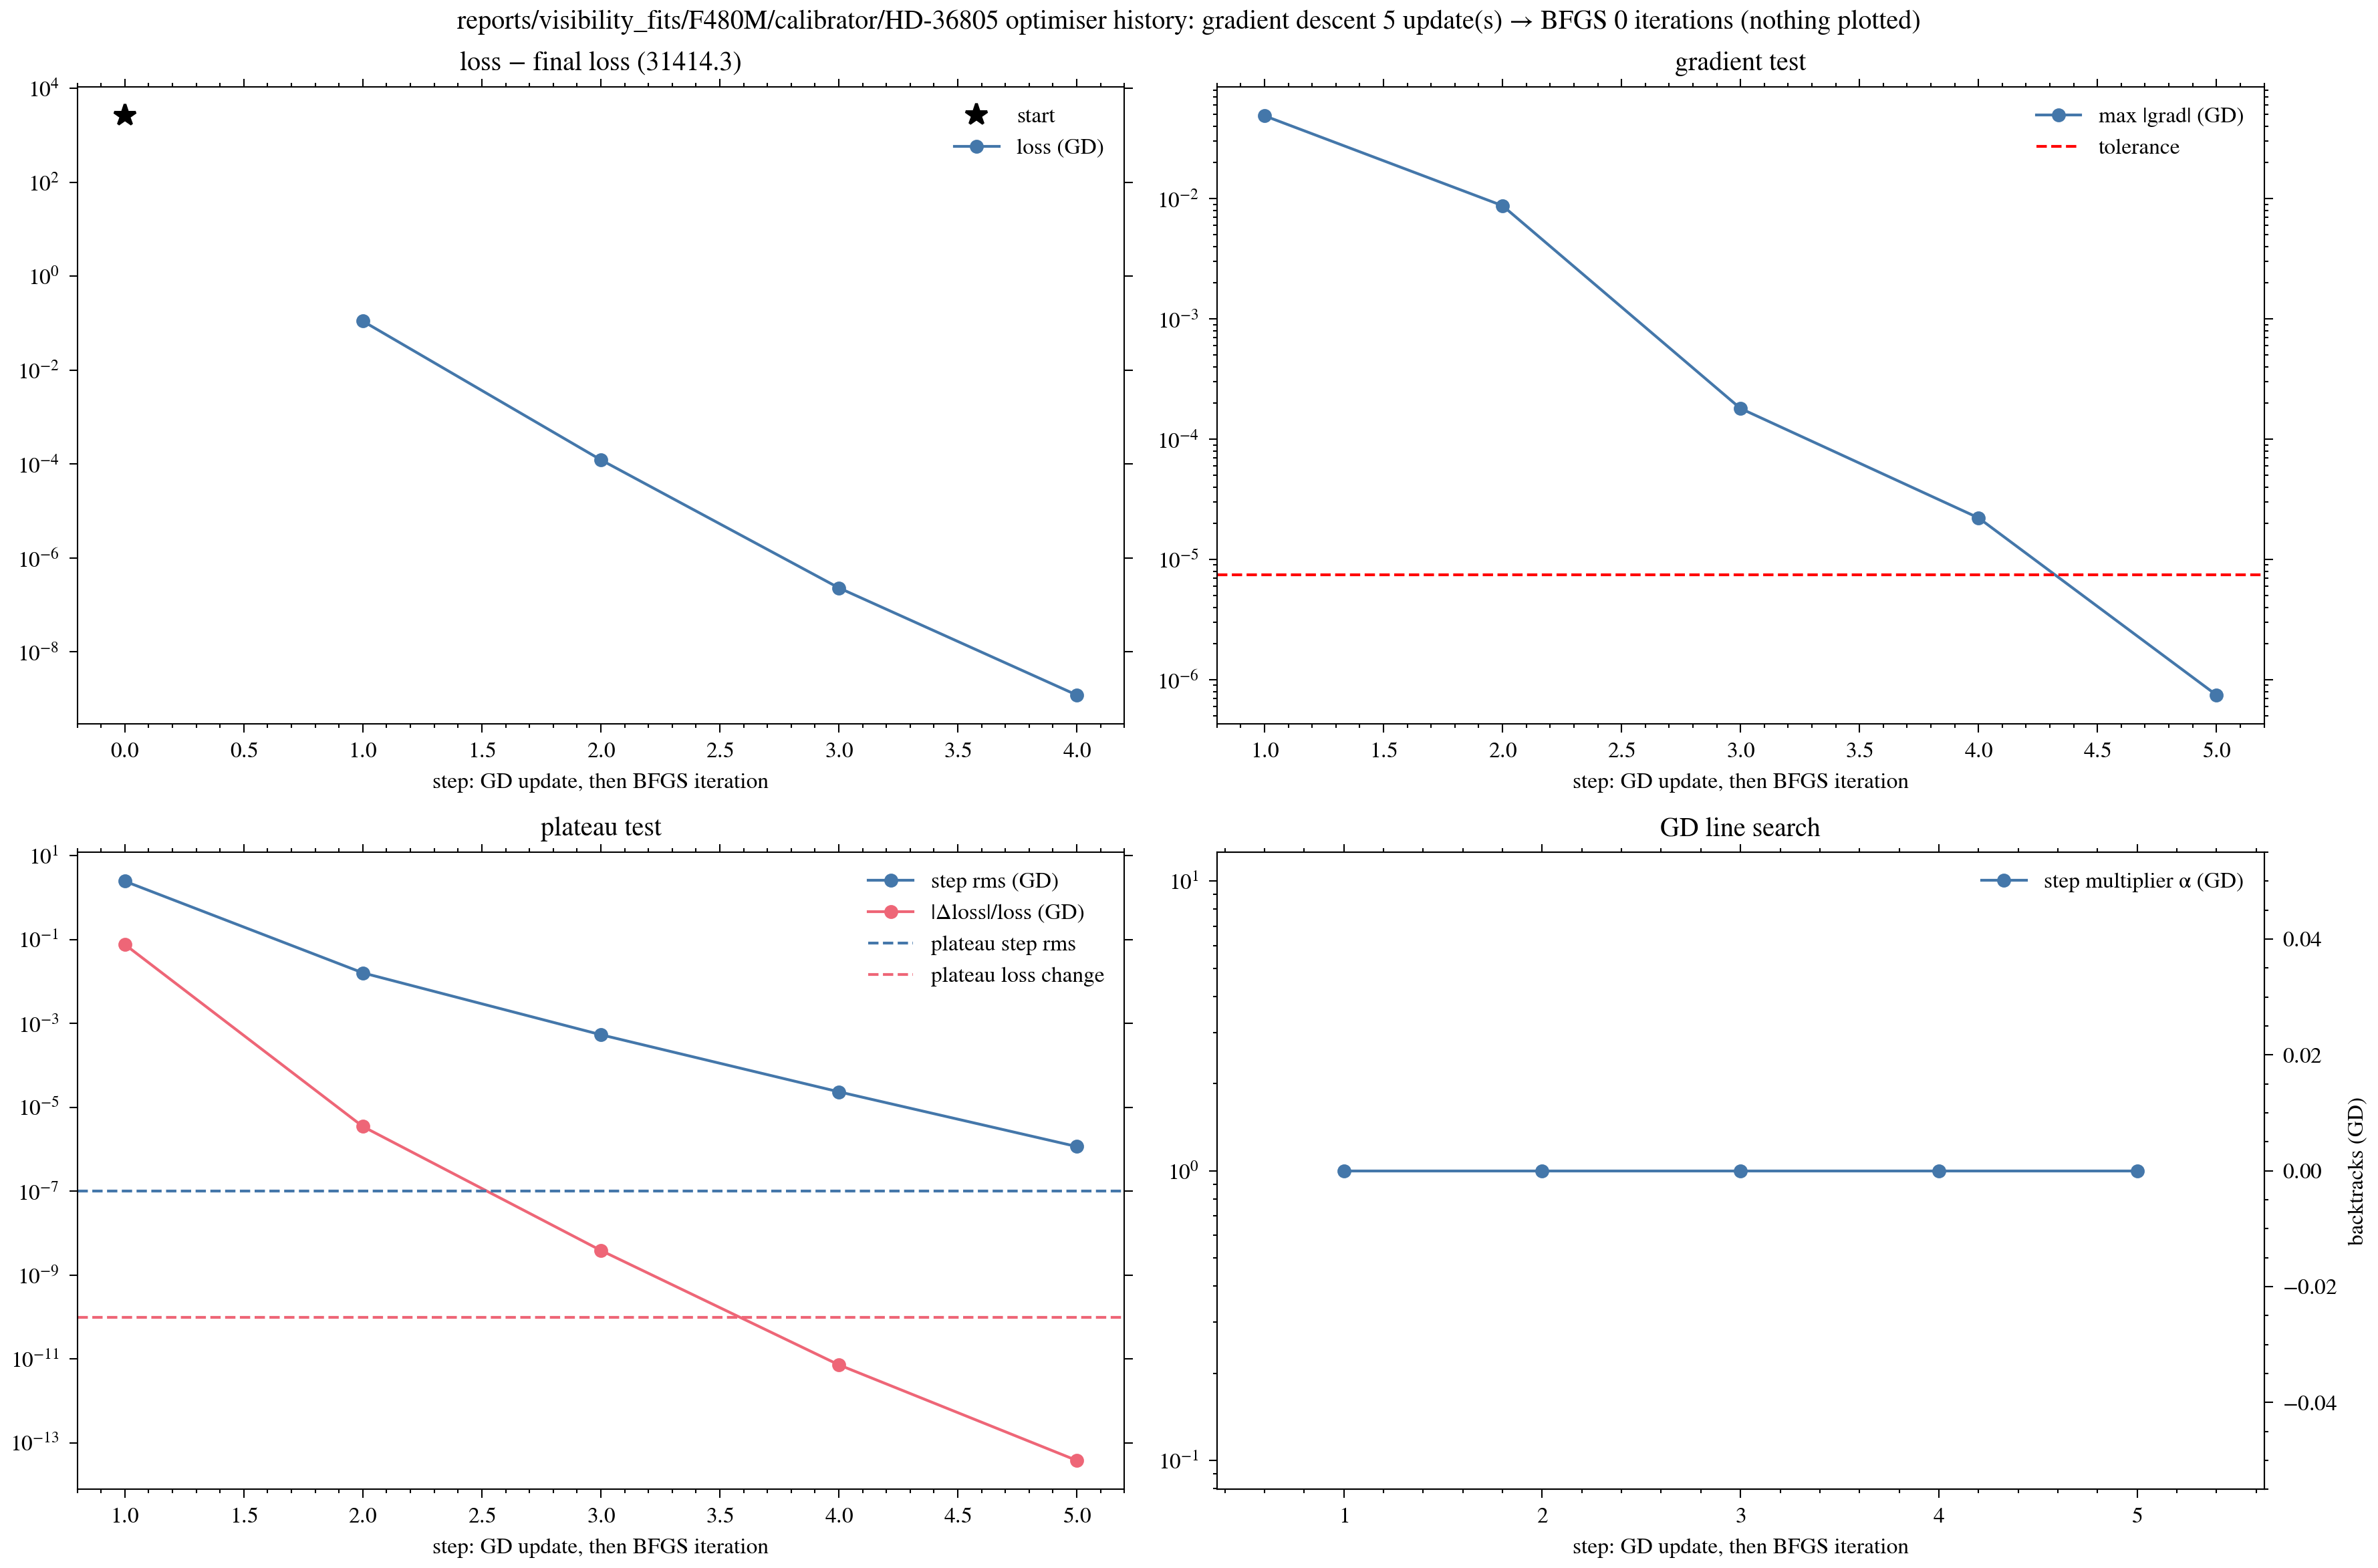

,value
preconditioner.method,exact_autodiff_jvp_vjp
preconditioner.finite_differences,False
preconditioner.checkpointed_residual,True
preconditioner.parameter_dimension,864
preconditioner.residual_dimension,45720
preconditioner.batch_size,2
preconditioner.relative_asymmetry,0.0
preconditioner.whitening_max_abs_error,0.0
preconditioner.eigenvalue_flooring,False
preconditioner.diagonal_scaling,True


fisher_refresh_policy: {"maximum_attempts": 2, "refresh_only_after_finite_non_worsening_endpoint": true, "acceptance_thresholds_unchanged": true}
1 Fisher attempt(s): #1 accepted=True


**reports/visibility_fits/F480M/science/AB-DOR: accepted** (gradient (float64 floor)), loss 85251.9 → 16054.8  
fitted: amplitudes.AB-DOR_F480M, positions.01093_014_02_03_5, spectra.AB-DOR_F480M, fluxes.01093_014_02_03_5  
parameter directions: 864 native, **864 optimised**, 0 held fixed as unidentified (unit-free (diagonally scaled) JTJ eigenvalues 0.00351 … 1.88, cutoff 1.88e-08 = rank_rtol 1e-08 × largest)

**1. Gradient descent** (Armijo backtracking): 9 update(s) of at most 24; stopped: max |normalised gradient| 1.12e-06 reached the tolerance 5.34032e-06.

**2. BFGS** (SciPy, from where gradient descent stopped): 1 pass(es), 0 iteration(s) in total; final max |normalised gradient| 1.12e-06 (tolerance 5.34032e-06).
- pass 1: 0 iteration(s), 37 evaluation(s) — no progress: it could not find any step that lowers the loss (SciPy: "Desired error not necessarily achieved due to precision loss.")

Convergence tests (applied to the combined gradient-descent + BFGS history):

,passed,threshold
finite,True,
non_worsening,True,
gradient_gate,True,max |normalised gradient| < 5.34032e-06 (reque...
plateau_gate,False,3 steps with step_rms < 1e-07 and relative los...


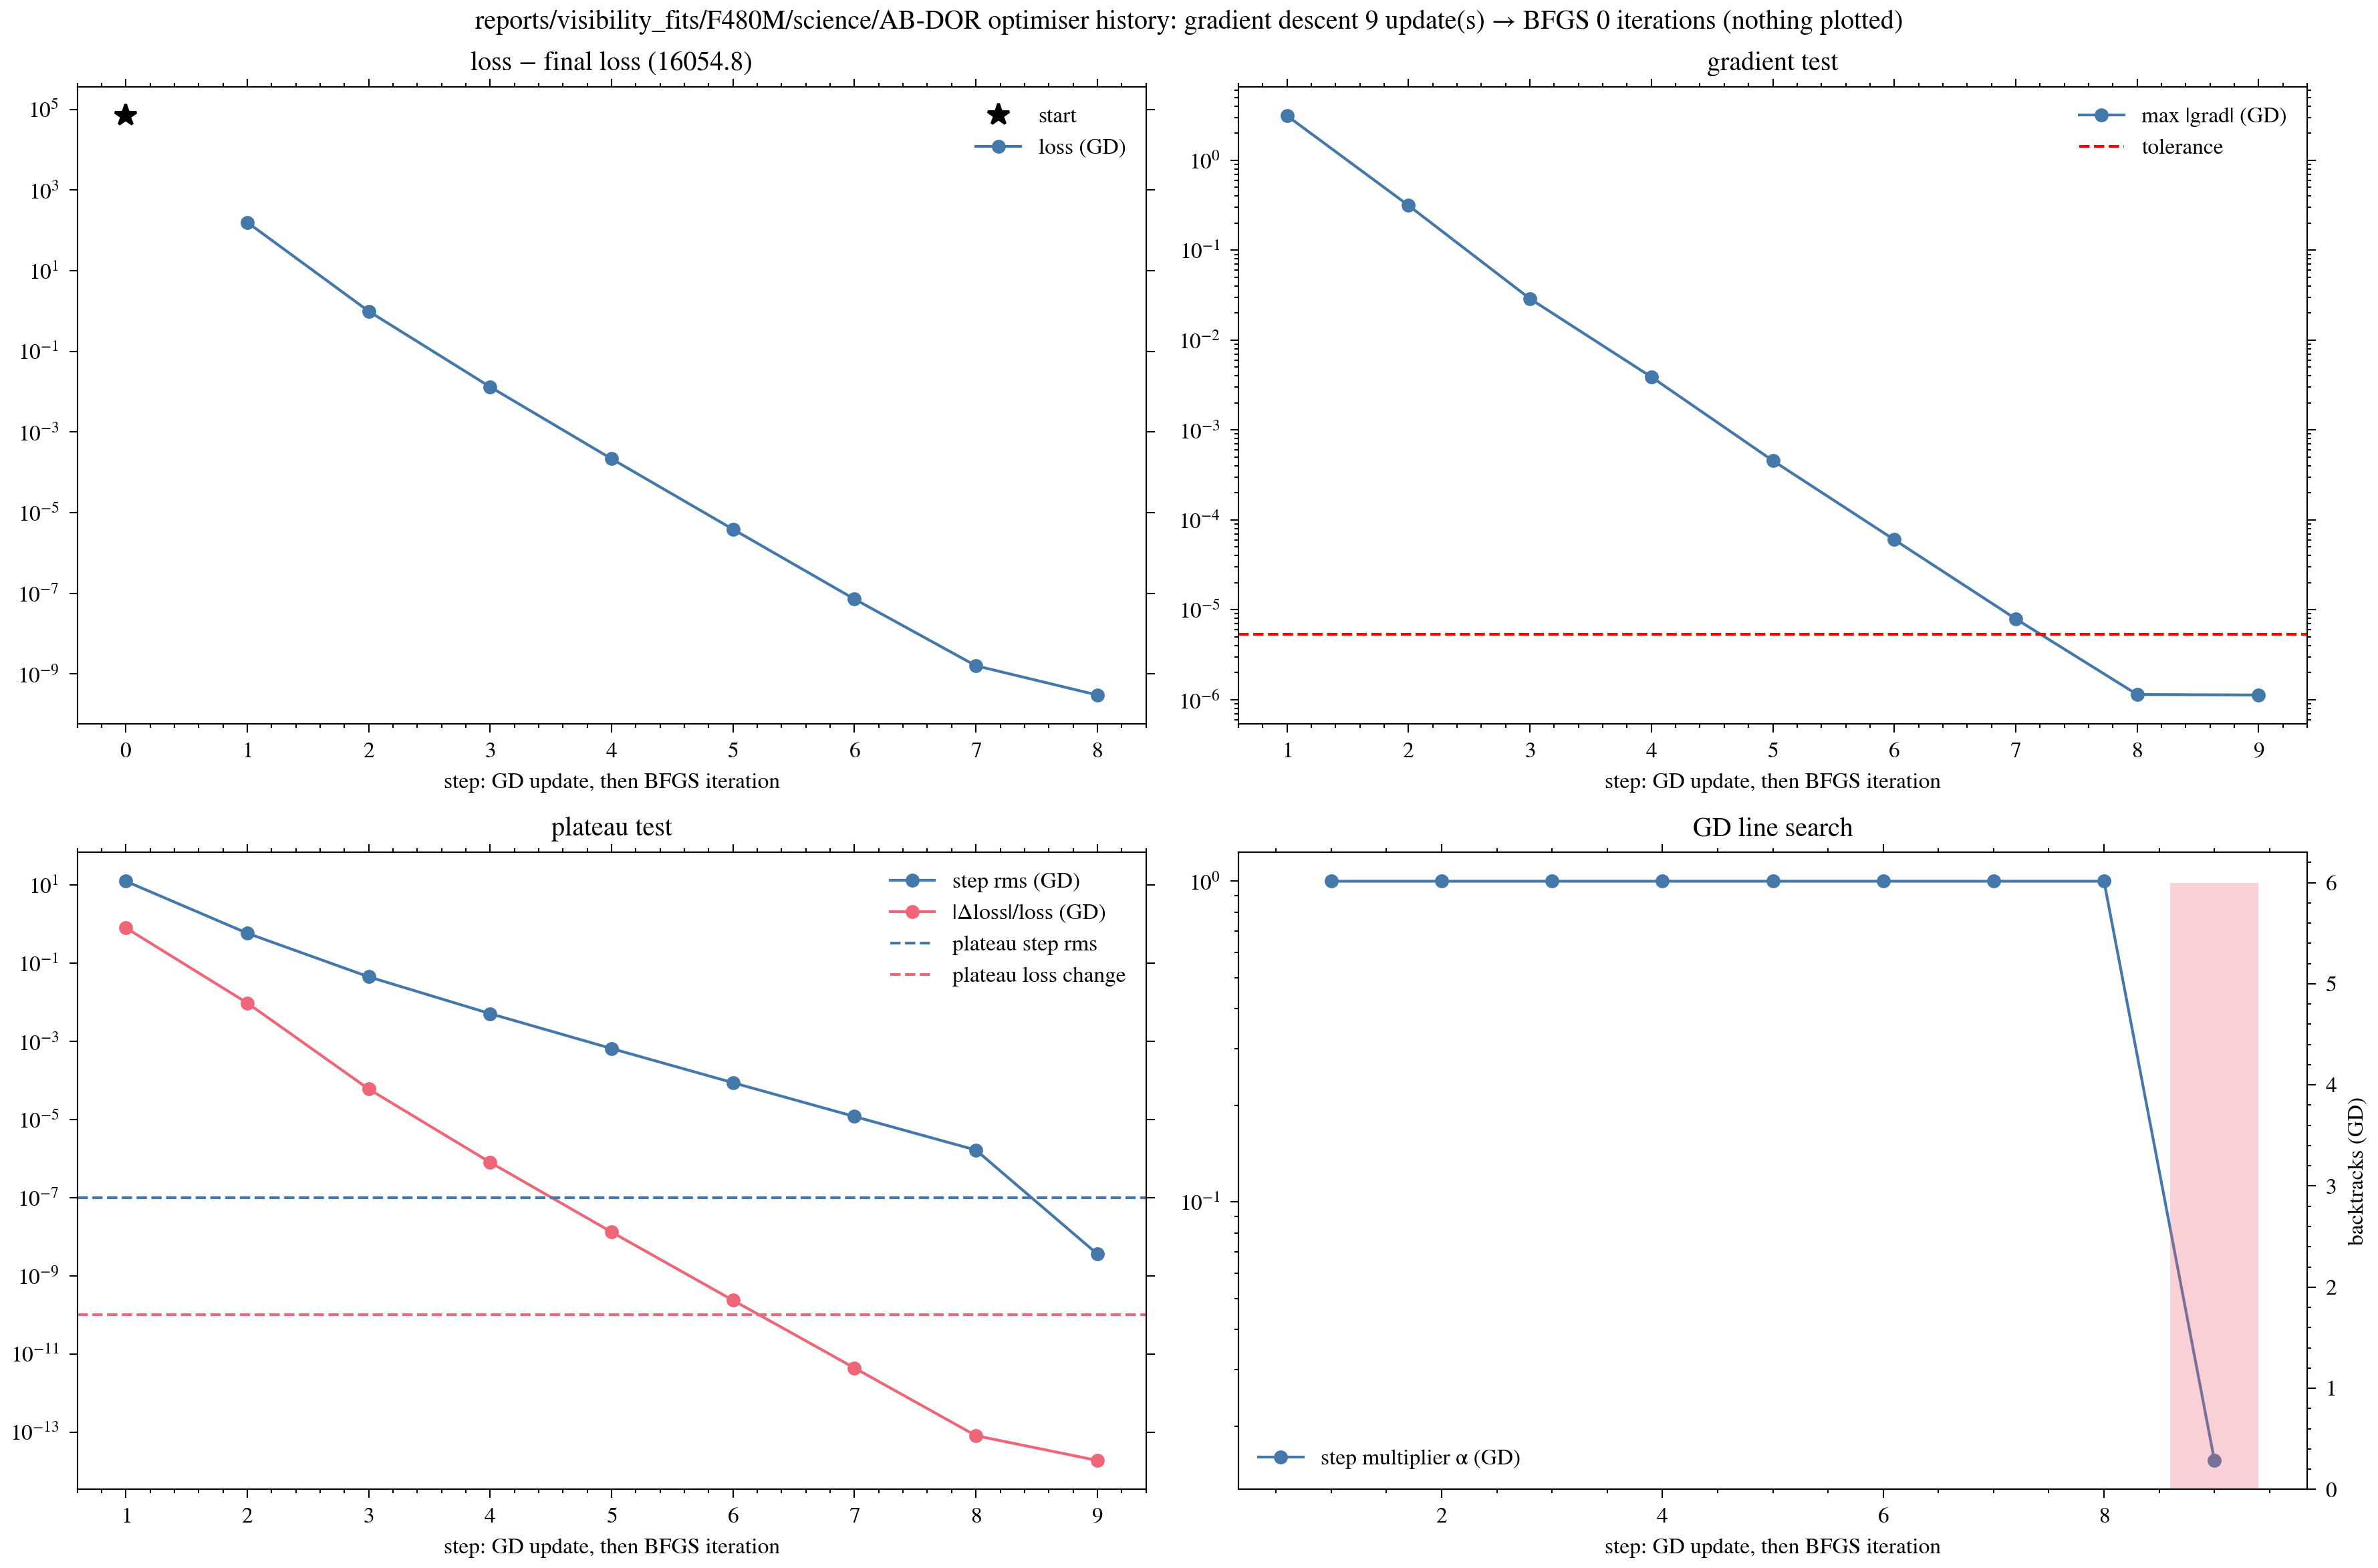

,value
preconditioner.method,exact_autodiff_jvp_vjp
preconditioner.finite_differences,False
preconditioner.checkpointed_residual,True
preconditioner.parameter_dimension,864
preconditioner.residual_dimension,22860
preconditioner.batch_size,2
preconditioner.relative_asymmetry,0.0
preconditioner.whitening_max_abs_error,0.0
preconditioner.eigenvalue_flooring,False
preconditioner.diagonal_scaling,True


fisher_refresh_policy: {"maximum_attempts": 2, "refresh_only_after_finite_non_worsening_endpoint": true, "acceptance_thresholds_unchanged": true}
1 Fisher attempt(s): #1 accepted=True


#### `visibility_fits` optimiser trajectories

no fits run here: reloaded from disk (RESUME)


#### `visibility_fits` outputs

#### `F480M/calibrator/HD-36805`

File 01093_020_02_03_25
Star HD-36805
Filter F480M
nints 65
ngroups 9



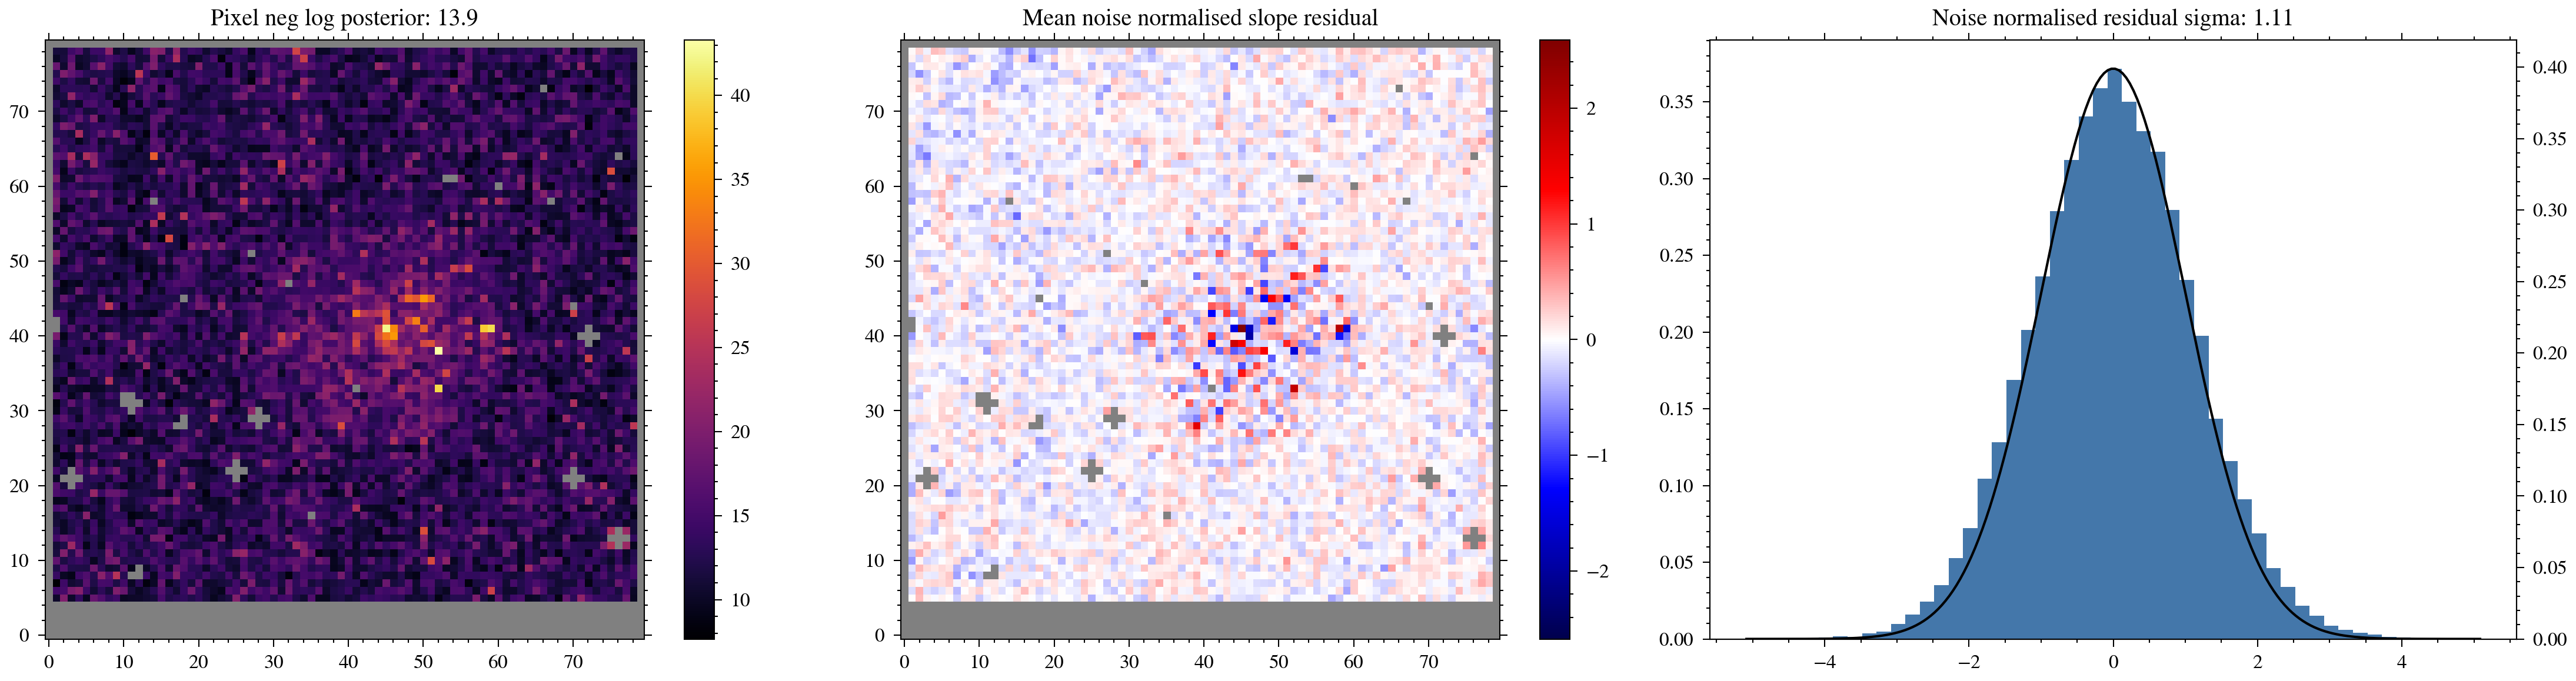

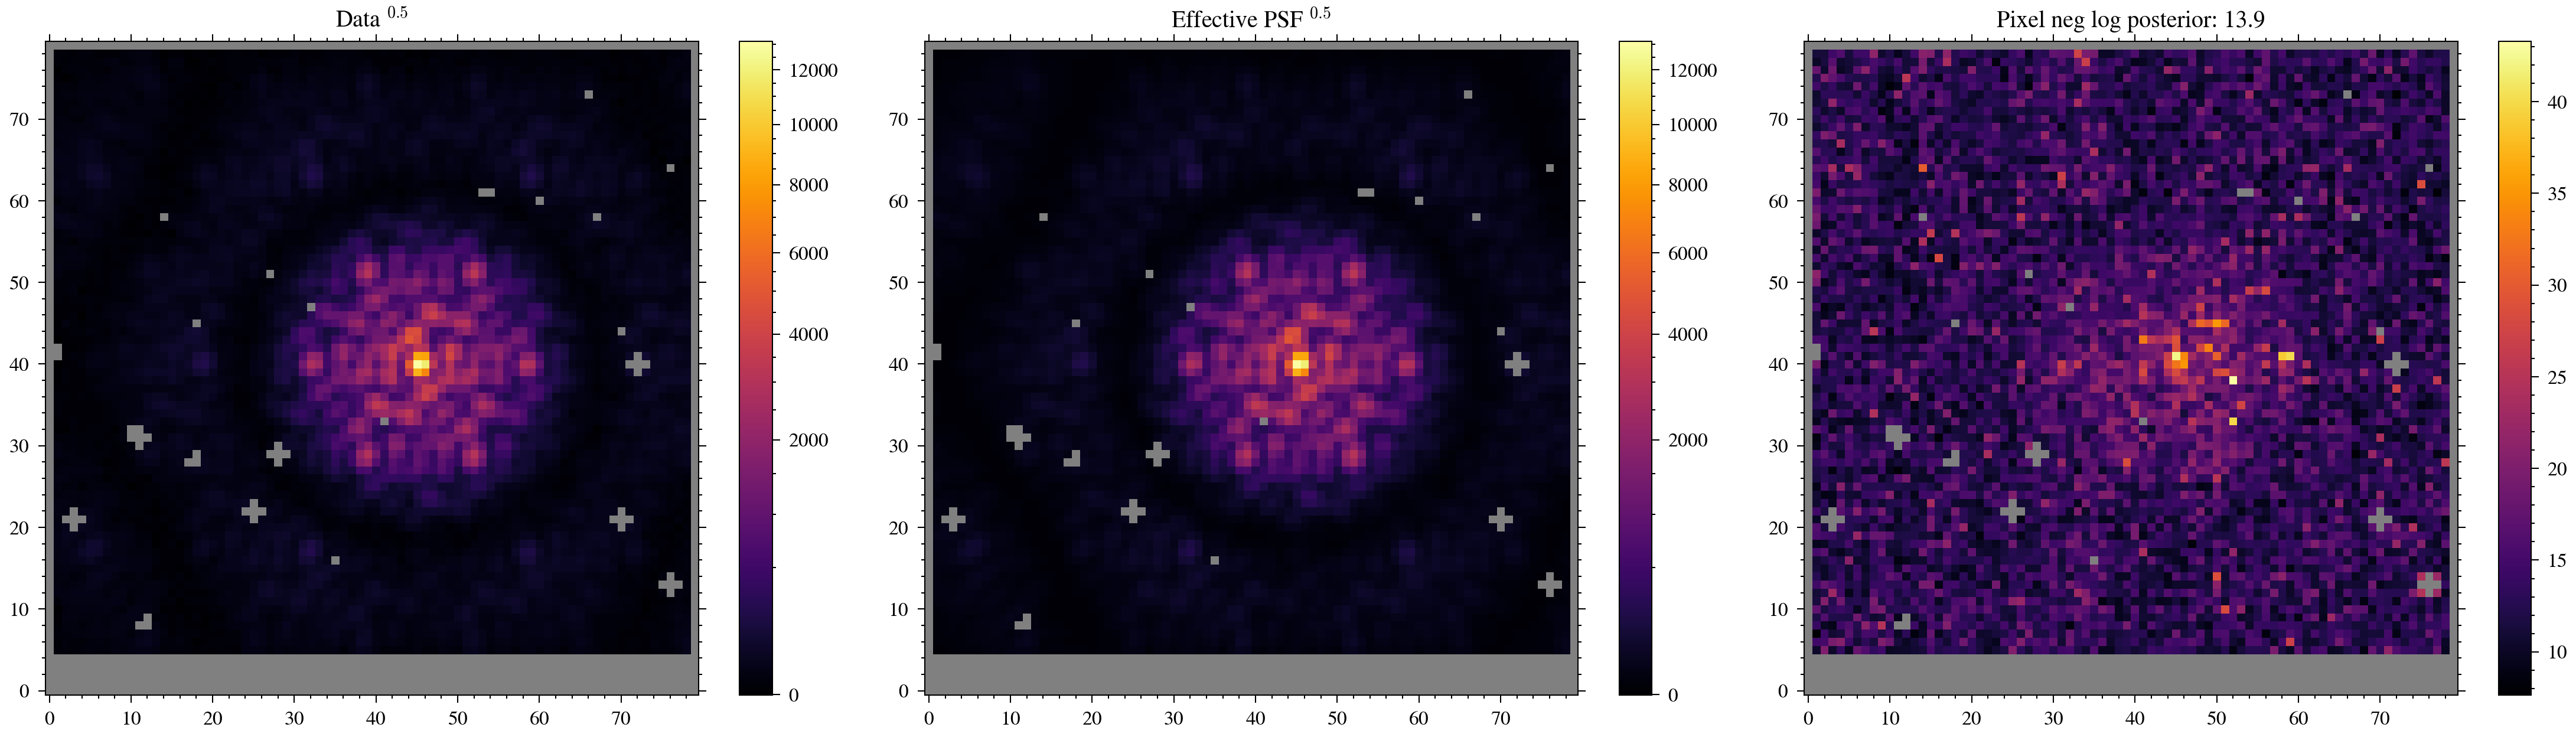

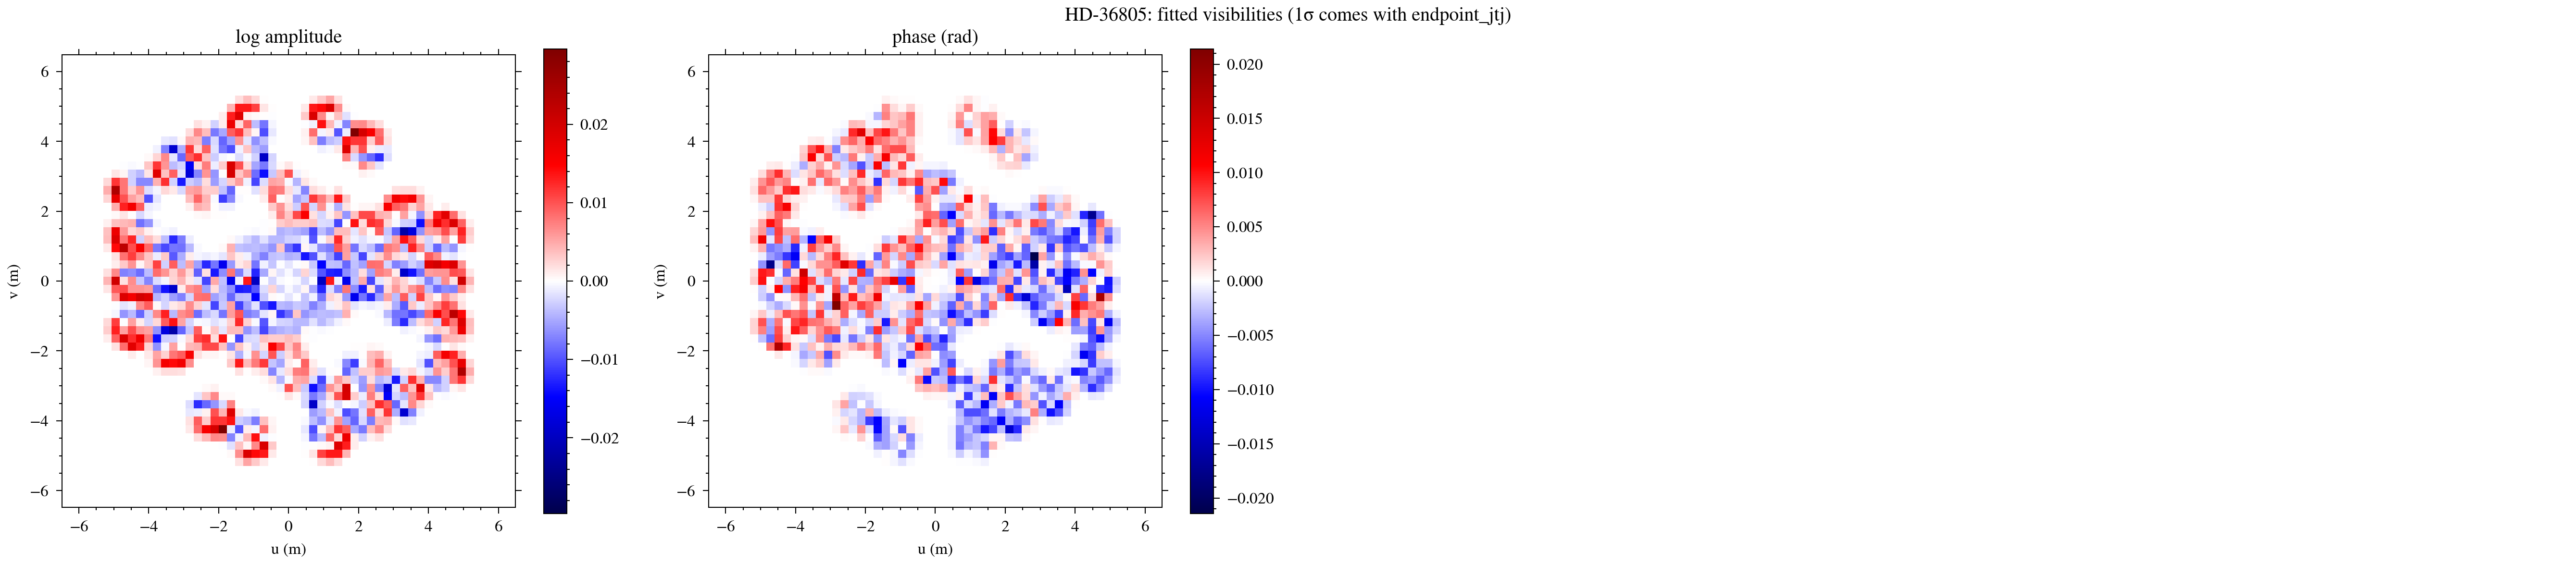

#### `F480M/science/AB-DOR`

File 01093_014_02_03_5
Star AB-DOR
Filter F480M
nints 69
ngroups 5



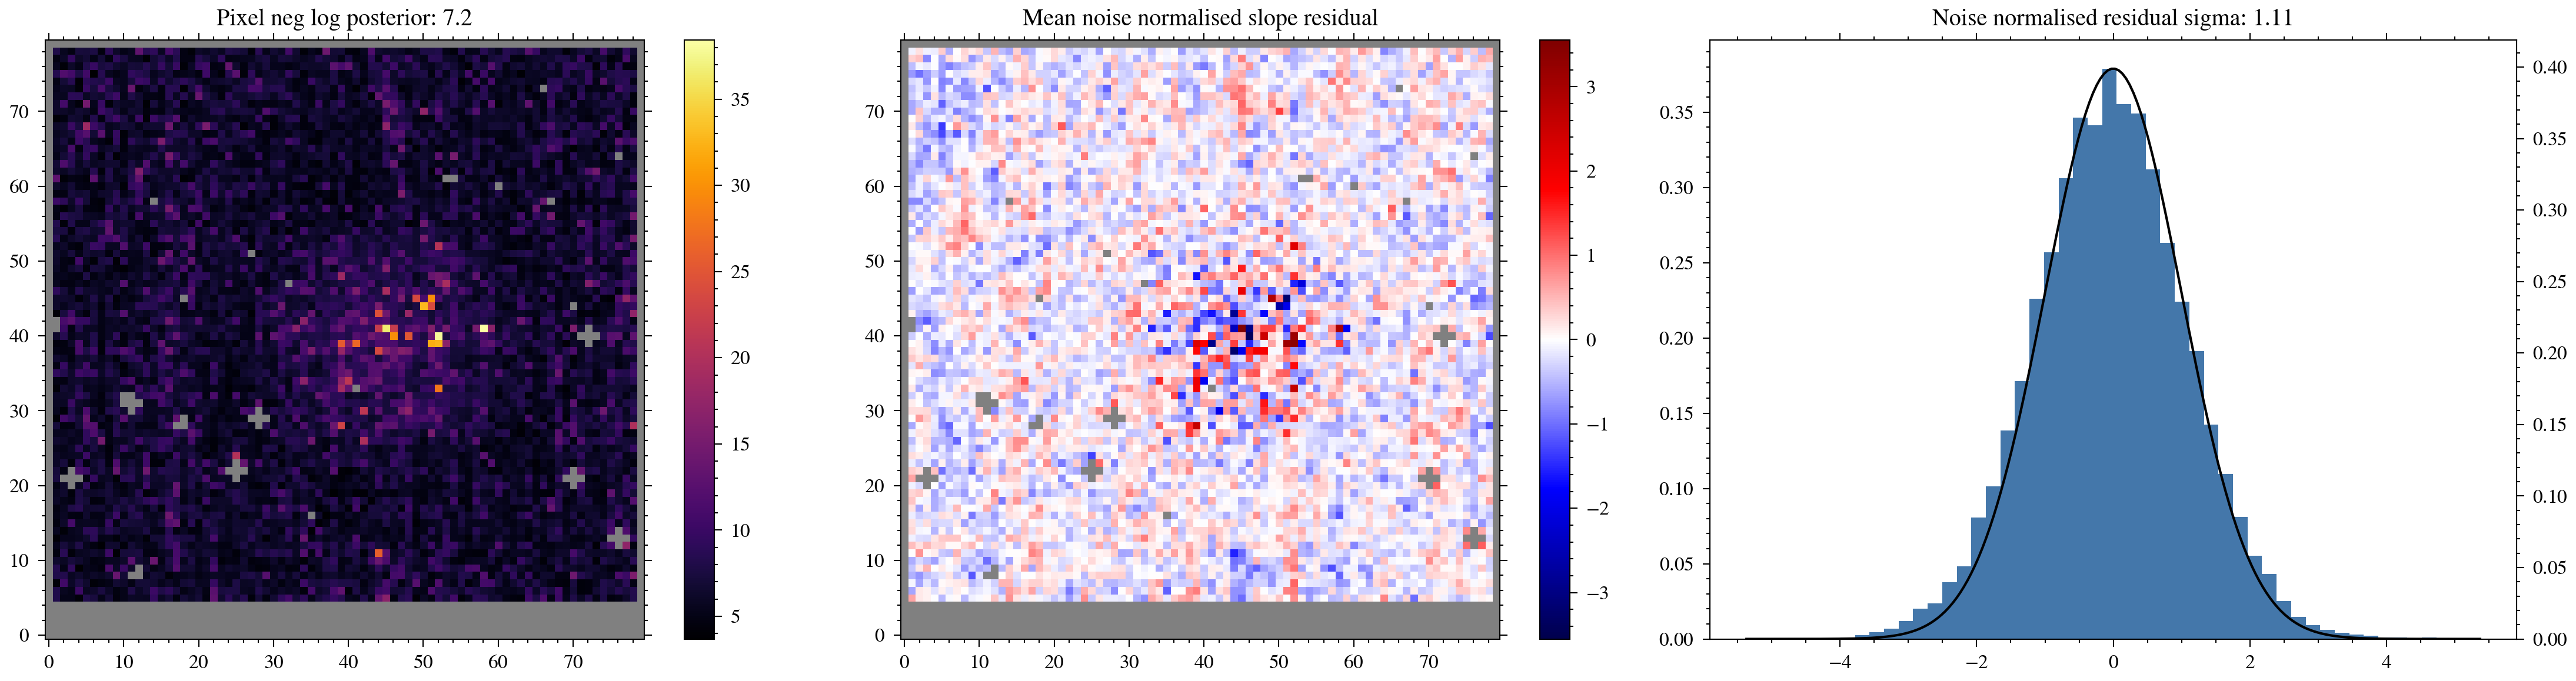

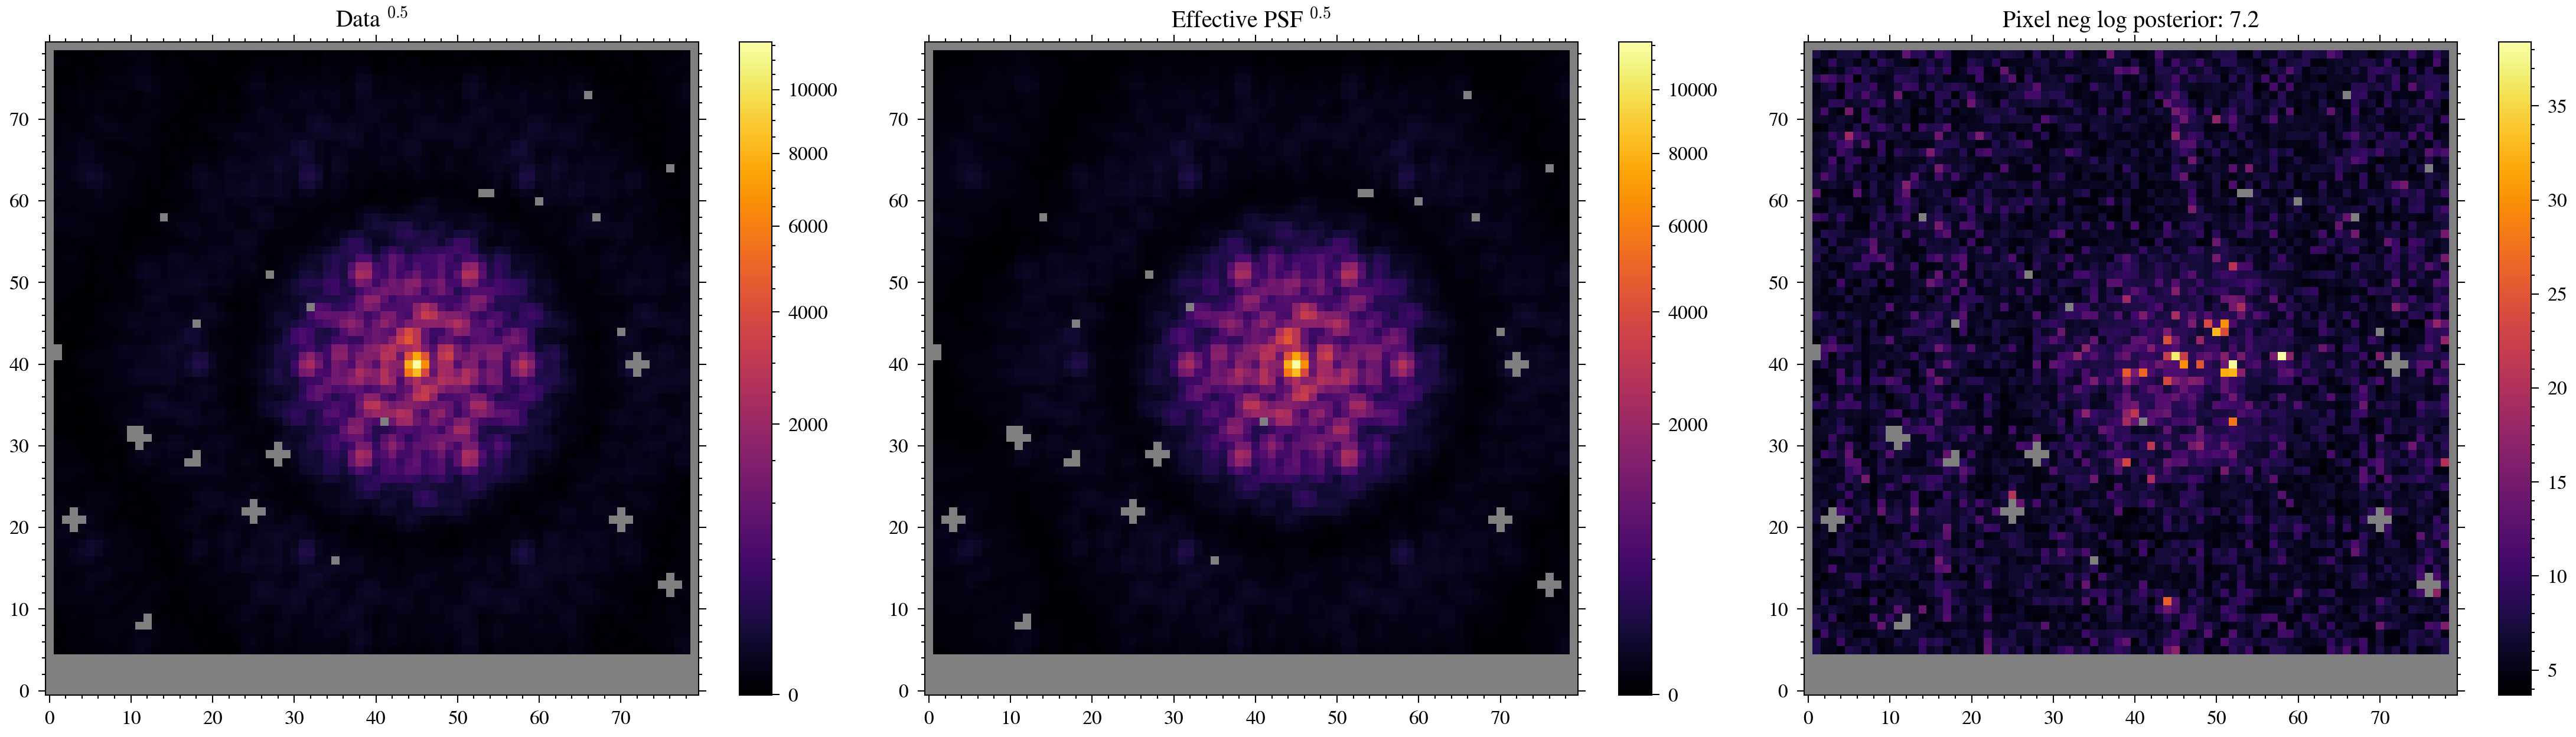

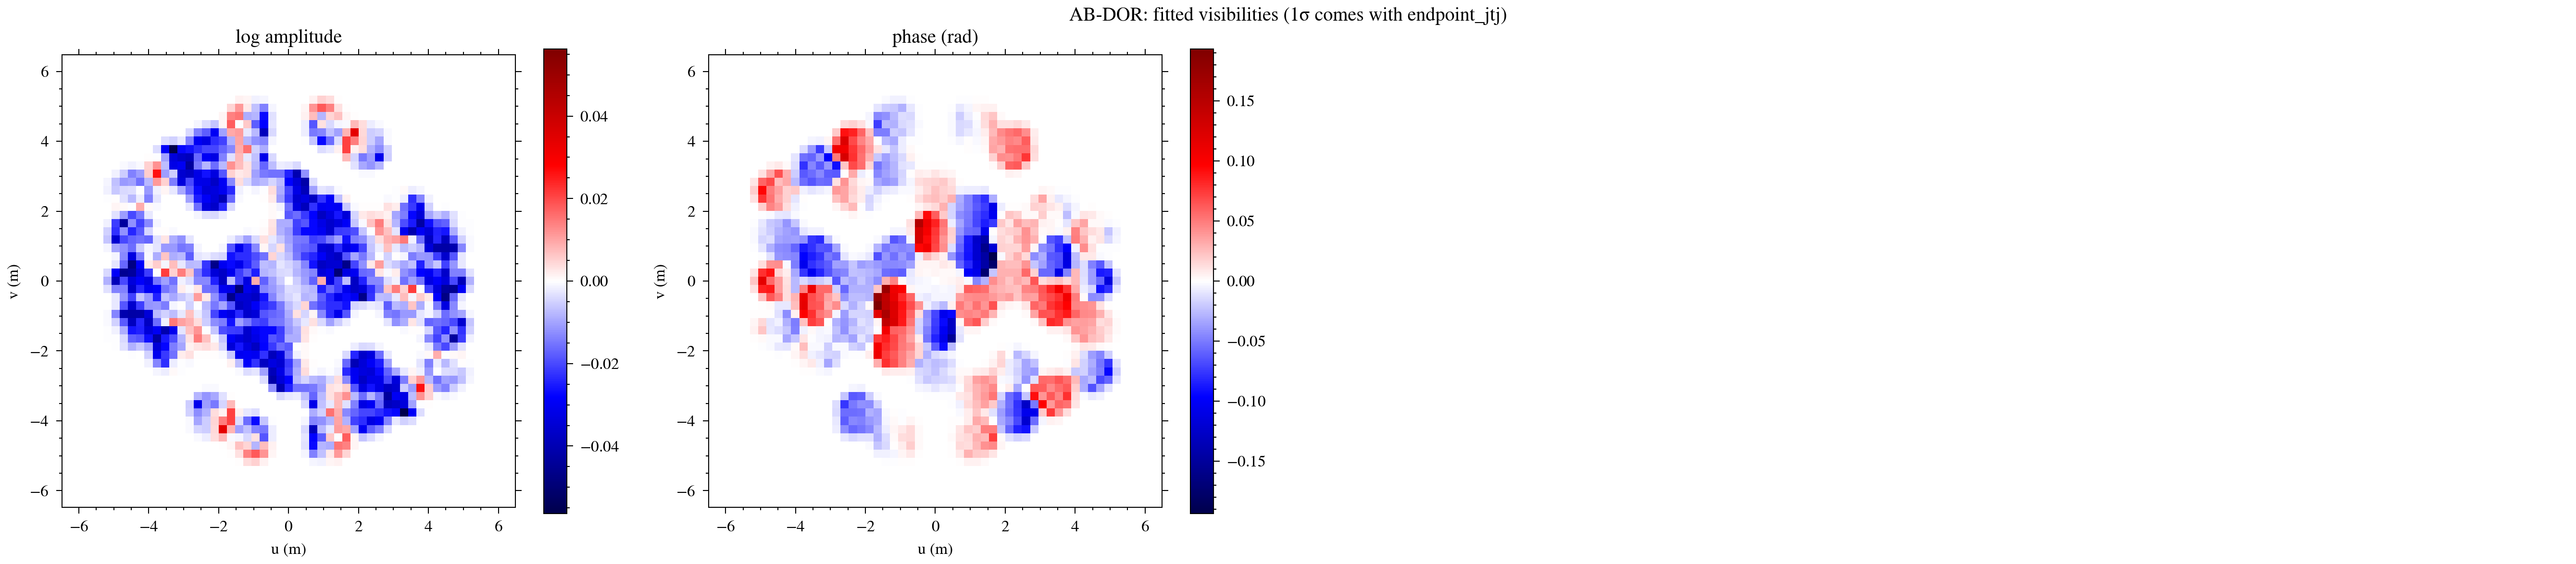

In [19]:
run_stage("visibility_fits")

### `endpoint_jtj`
The exact Fisher matrix at each visibility fit's endpoint, with the star's nuisance parameters (position, flux, spectrum) marginalised out. Outputs: each star's fitted visibilities in units of their marginal 1σ, and the precision spectrum with the nuisances known vs marginalised (what marginalising them costs).

#### `endpoint_jtj` report

**endpoint_jtj/F480M/calibrator/HD-36805**

,value
method,exact_autodiff_jvp_vjp
finite_differences,False
checkpointed_residual,True
parameter_dimension,864
residual_dimension,45720
batch_size,2
relative_asymmetry,0.0
visibility_dimension,860
nuisance_dimension,4
nuisance_inverse_max_abs_error,0.0


**endpoint_jtj/F480M/science/AB-DOR**

,value
method,exact_autodiff_jvp_vjp
finite_differences,False
checkpointed_residual,True
parameter_dimension,864
residual_dimension,22860
batch_size,2
relative_asymmetry,0.0
visibility_dimension,860
nuisance_dimension,4
nuisance_inverse_max_abs_error,0.0


#### `endpoint_jtj` outputs

#### `F480M/calibrator/HD-36805`

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


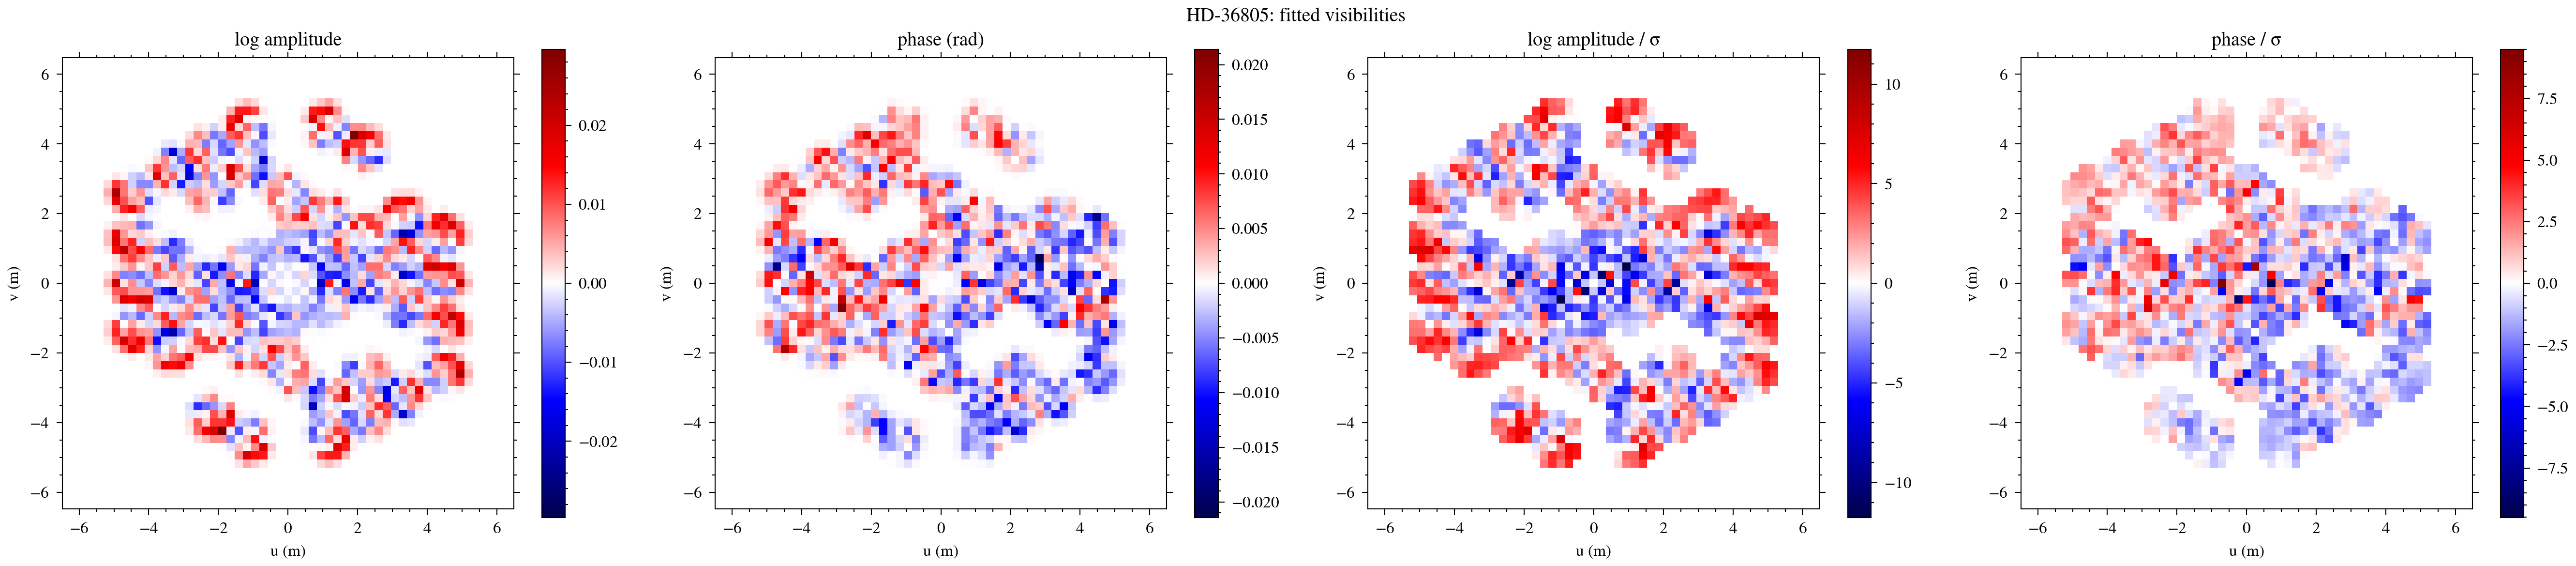

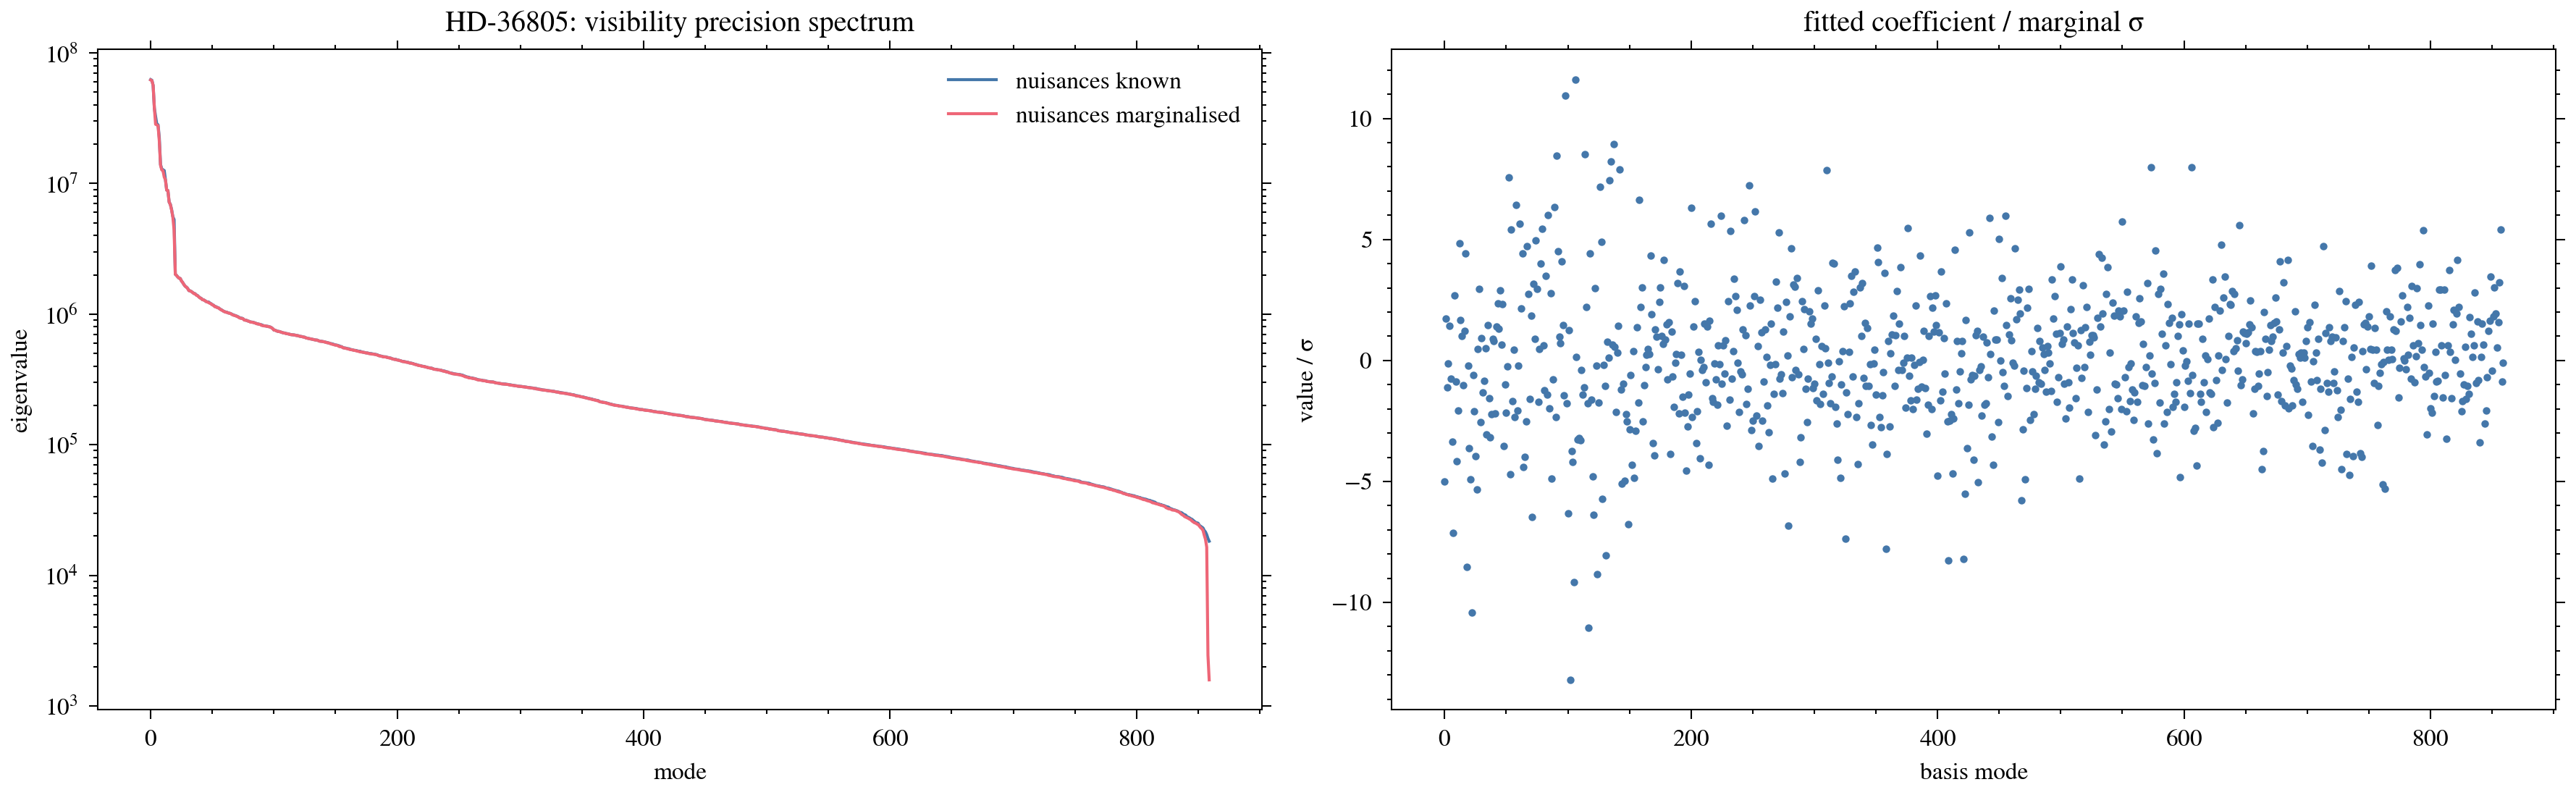

#### `F480M/science/AB-DOR`

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


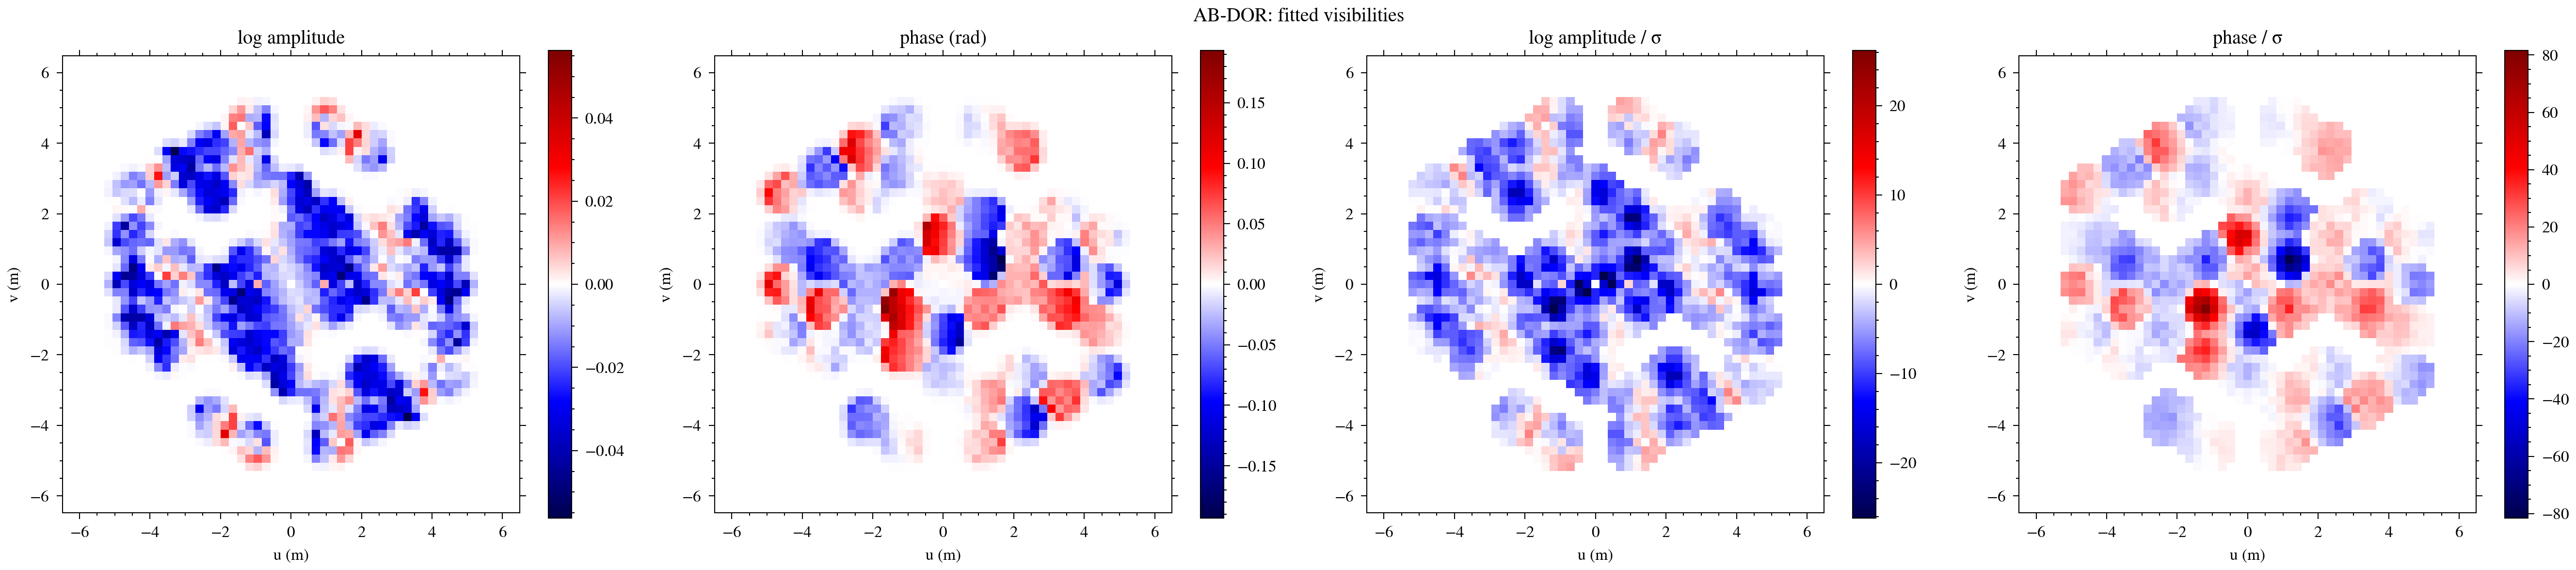

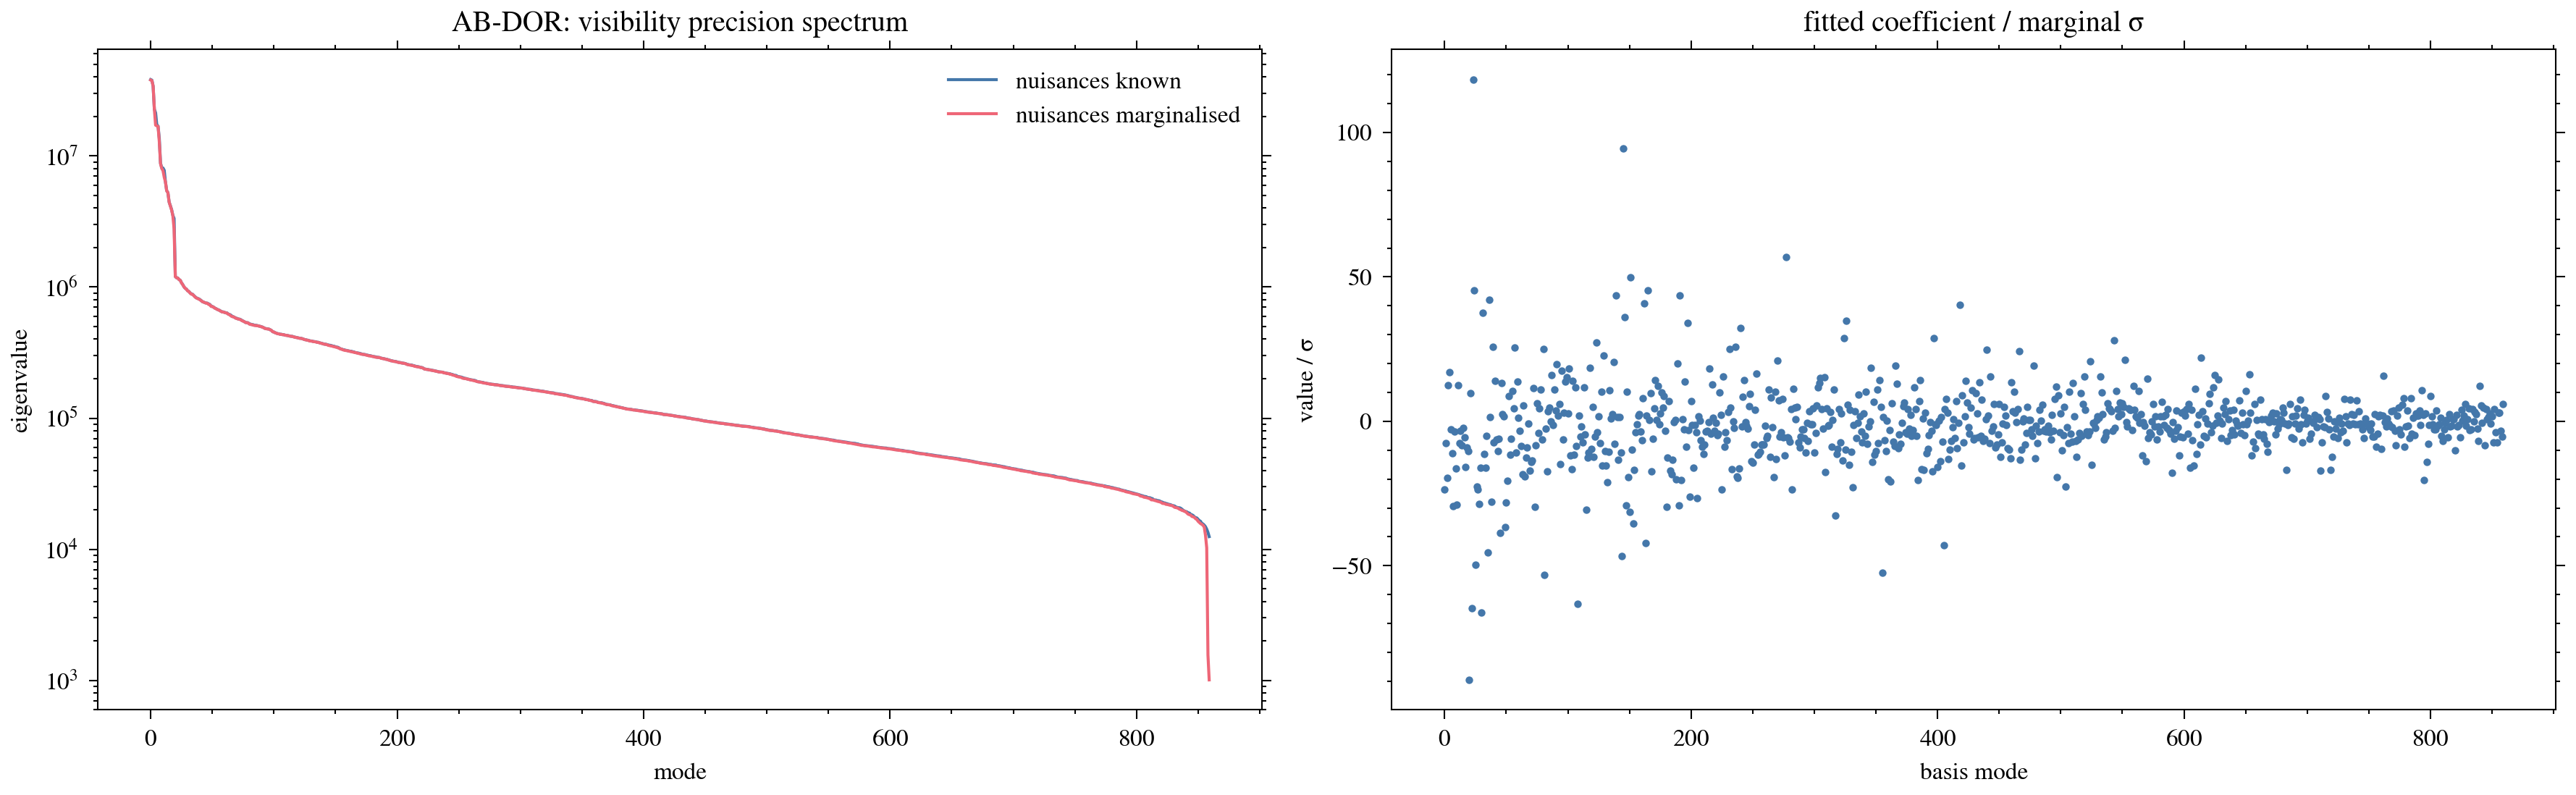

In [20]:
run_stage("endpoint_jtj")

### `calibrated_visibility`
Science minus calibrator in the modes both constrain, for each product (`marginalised`: nuisances marginalised; `null_full`: also projecting out the directions correlated with the model nuisances). Outputs: calibrator, science and calibrated visibilities with their 1σ, and the nuisance-correlated directions removed.

#### `calibrated_visibility` report

**reports/calibrated_visibility**

,value
F480M.dimension,8.600000e+02
F480M.native_dimension,8.600000e+02
F480M.discarded_unidentified_dimension,0.000000e+00
F480M.common_identifiable_range.dimension,8.600000e+02
F480M.common_identifiable_range.expected_minimum_dimension,8.600000e+02
F480M.common_identifiable_range.intersection_atol,1.000000e-07
F480M.common_identifiable_range.largest_principal_sine,8.560065e-08
F480M.common_identifiable_range.left_projection_max_abs_error,6.938894e-16
F480M.common_identifiable_range.right_projection_max_abs_error,6.661338e-16
F480M.science_rank,8.600000e+02


#### `calibrated_visibility` outputs

#### `marginalised` (F480M)

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


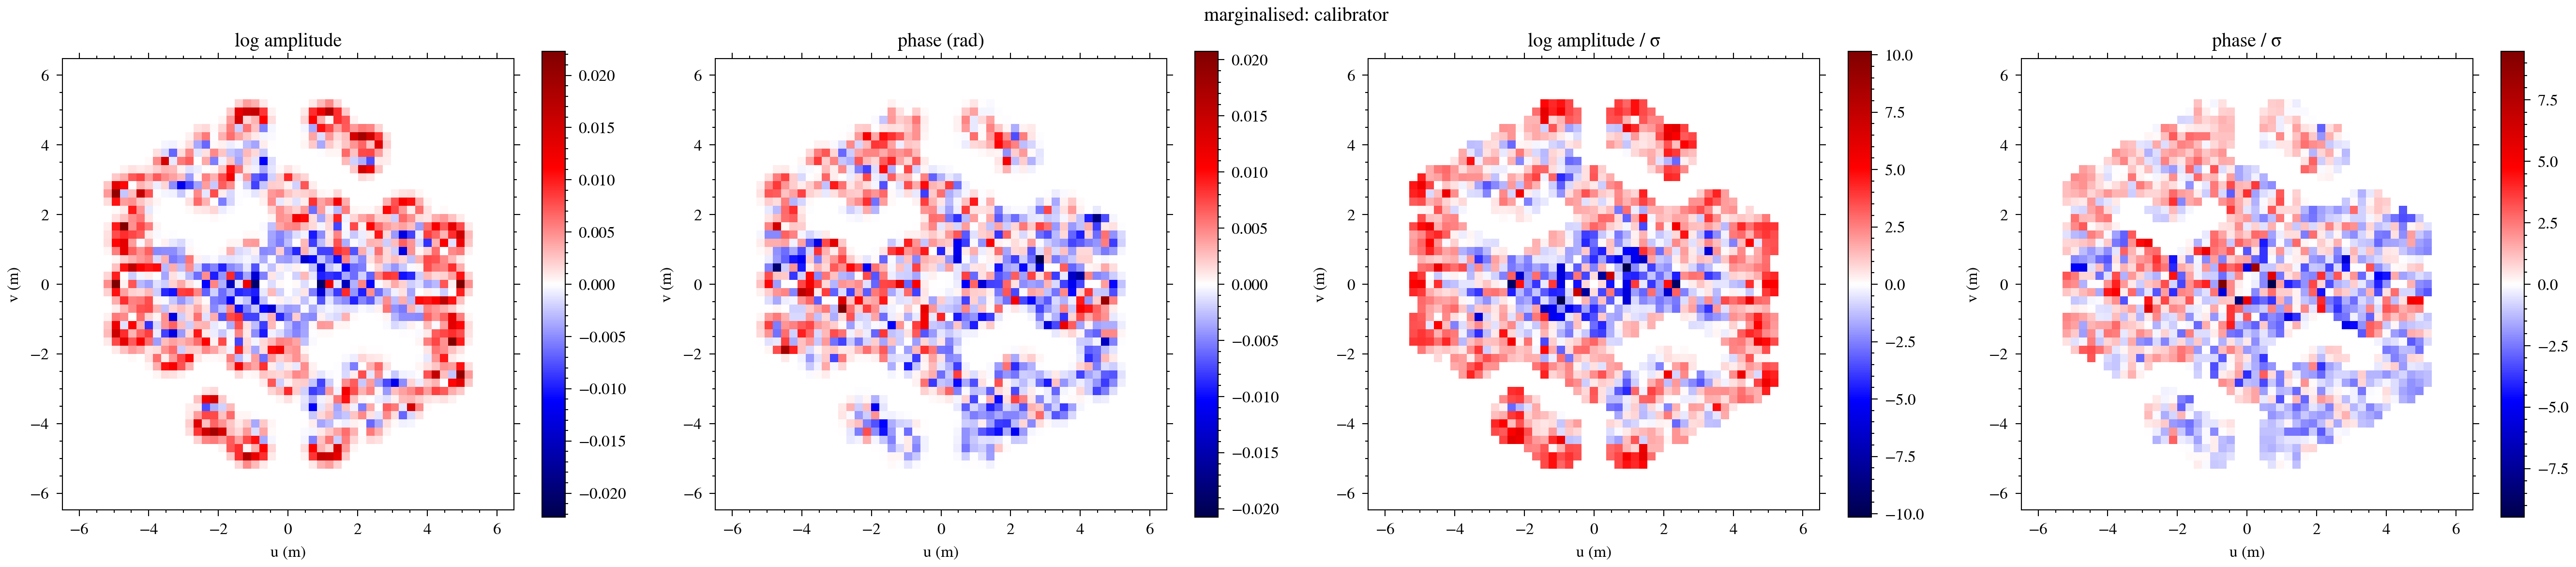

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


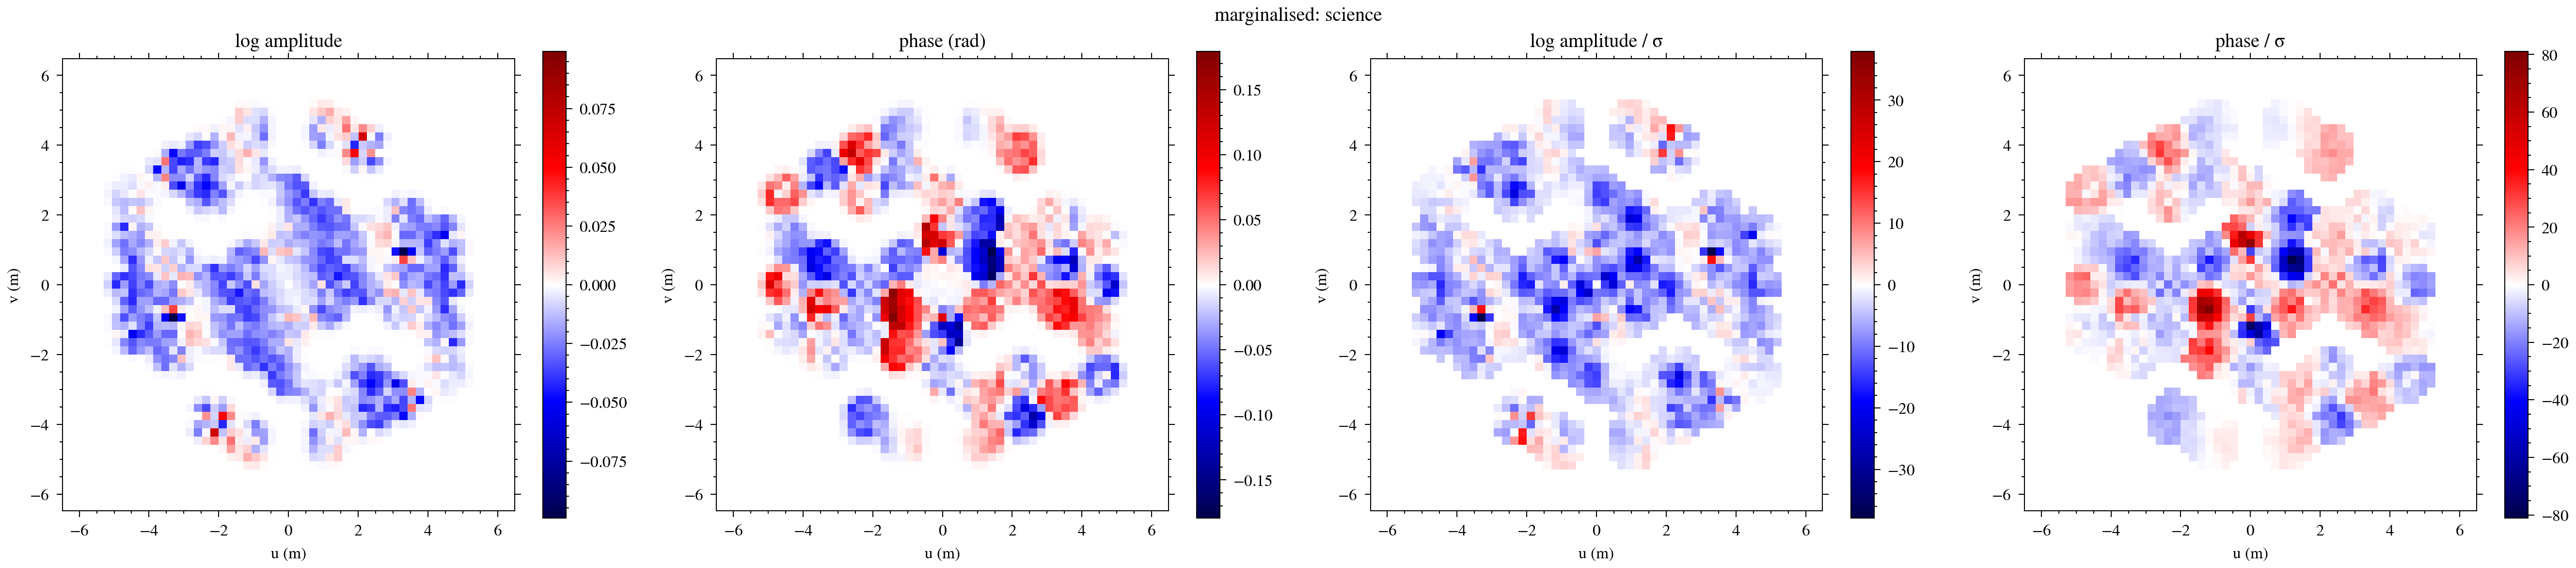

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


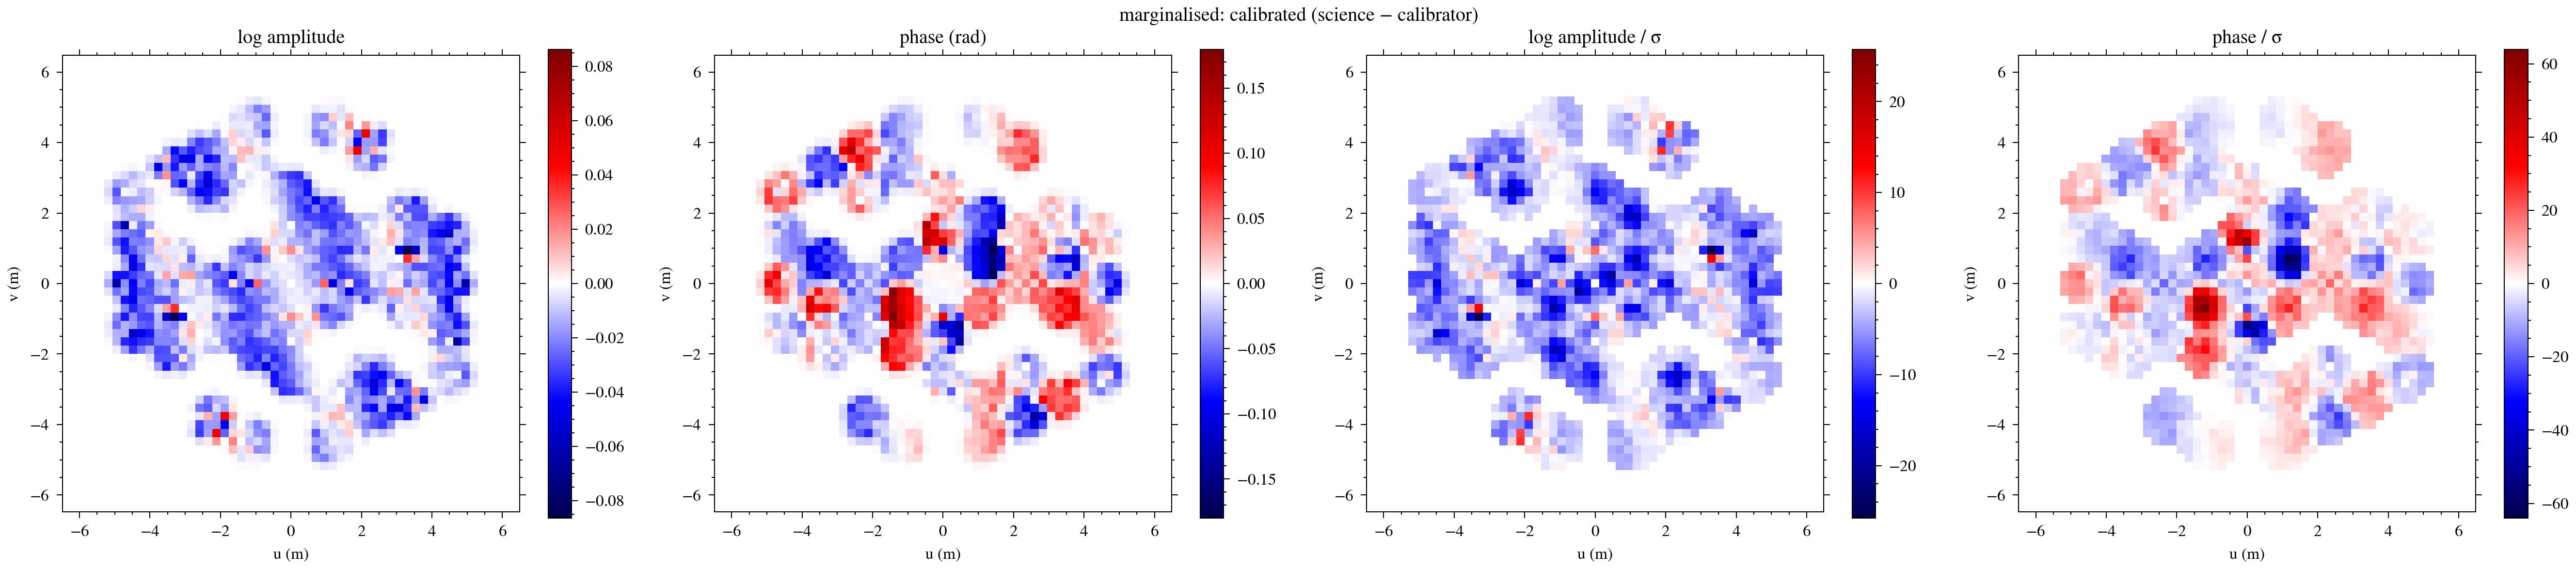

860 calibrated directions; wavelength 4.800 µm; parallactic angle 171.84 ± 0.00 deg


#### `null_full` (F480M)

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


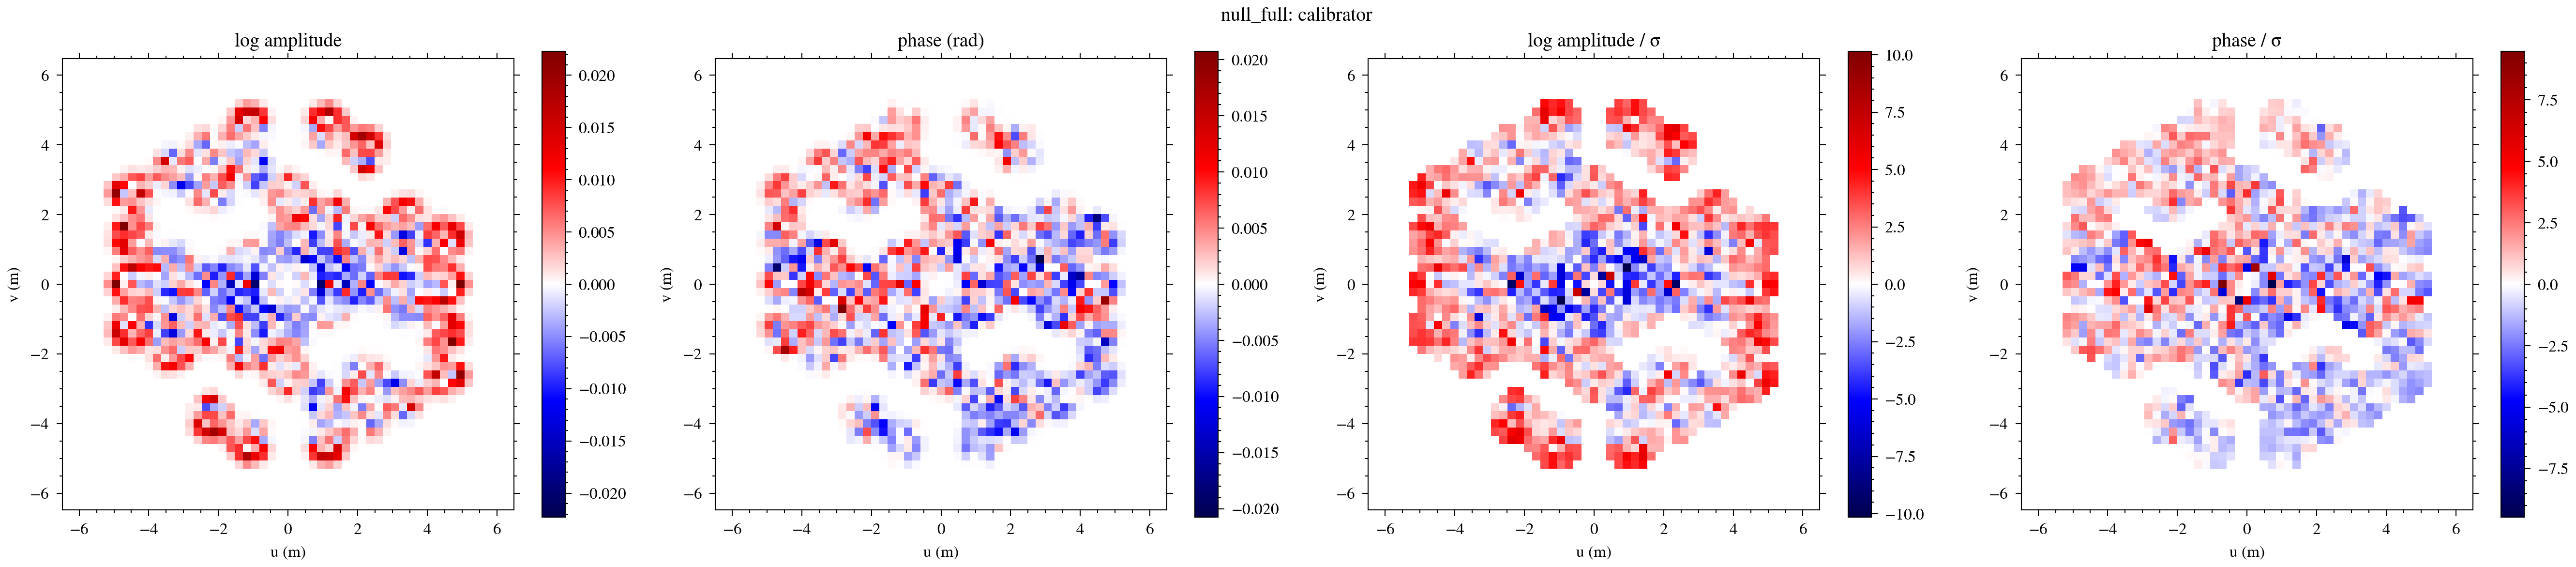

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


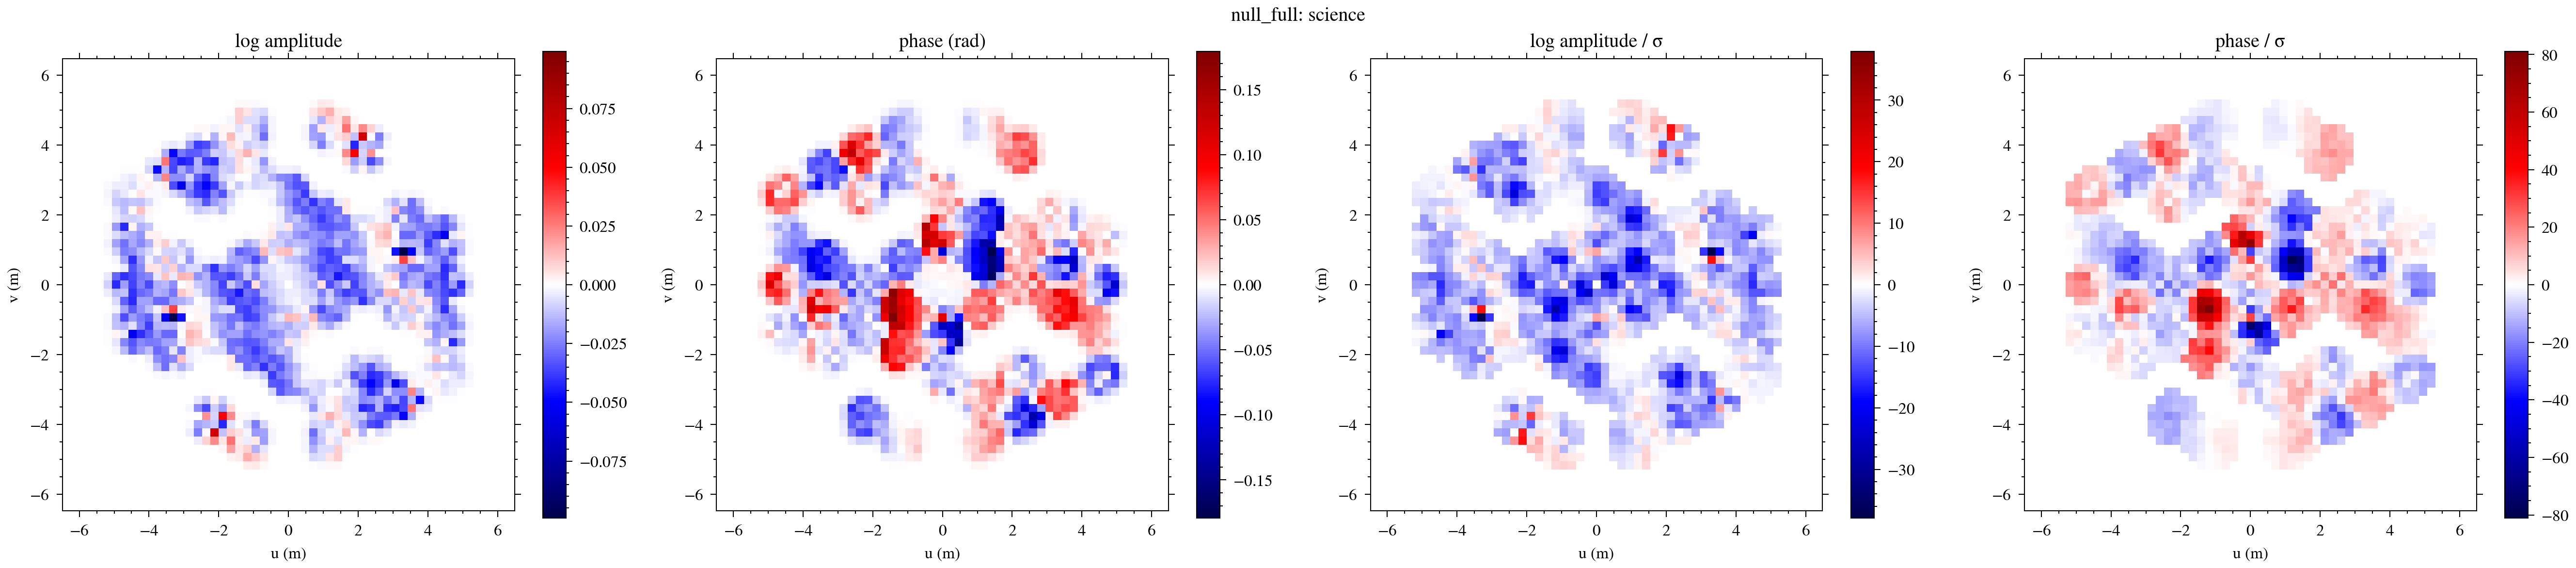

/tmp/ipykernel_74142/531227430.py:112: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[2], la / sa, "log amplitude / σ", support)
/tmp/ipykernel_74142/531227430.py:113: RuntimeWarning: invalid value encountered in divide
  uv_panel(ax[3], ph / sp, "phase / σ", support)


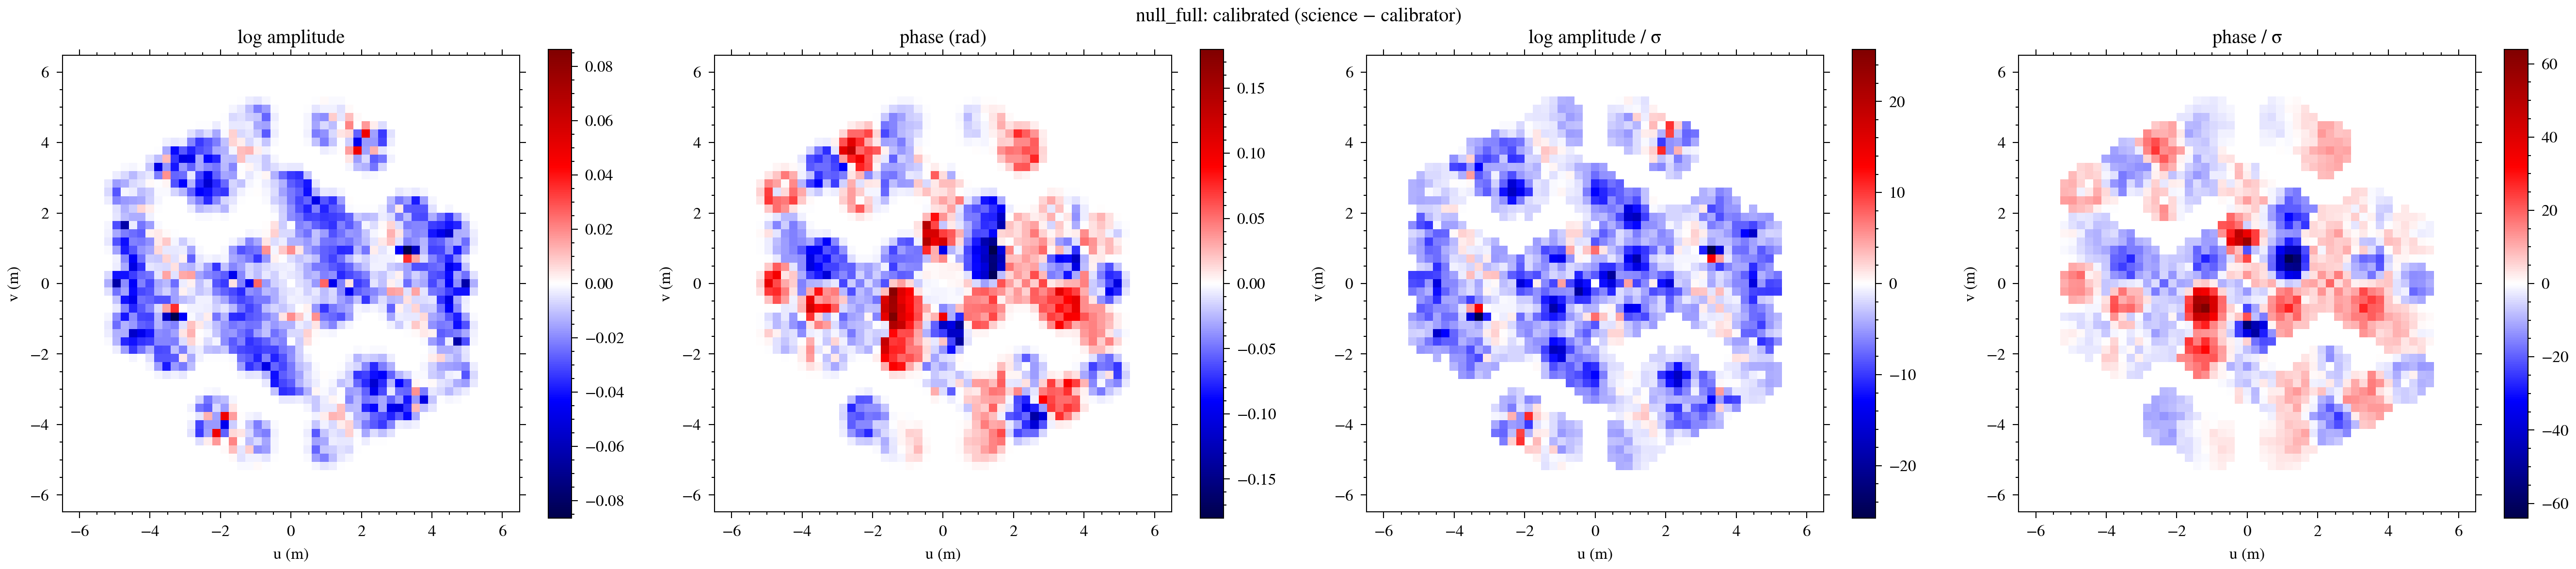

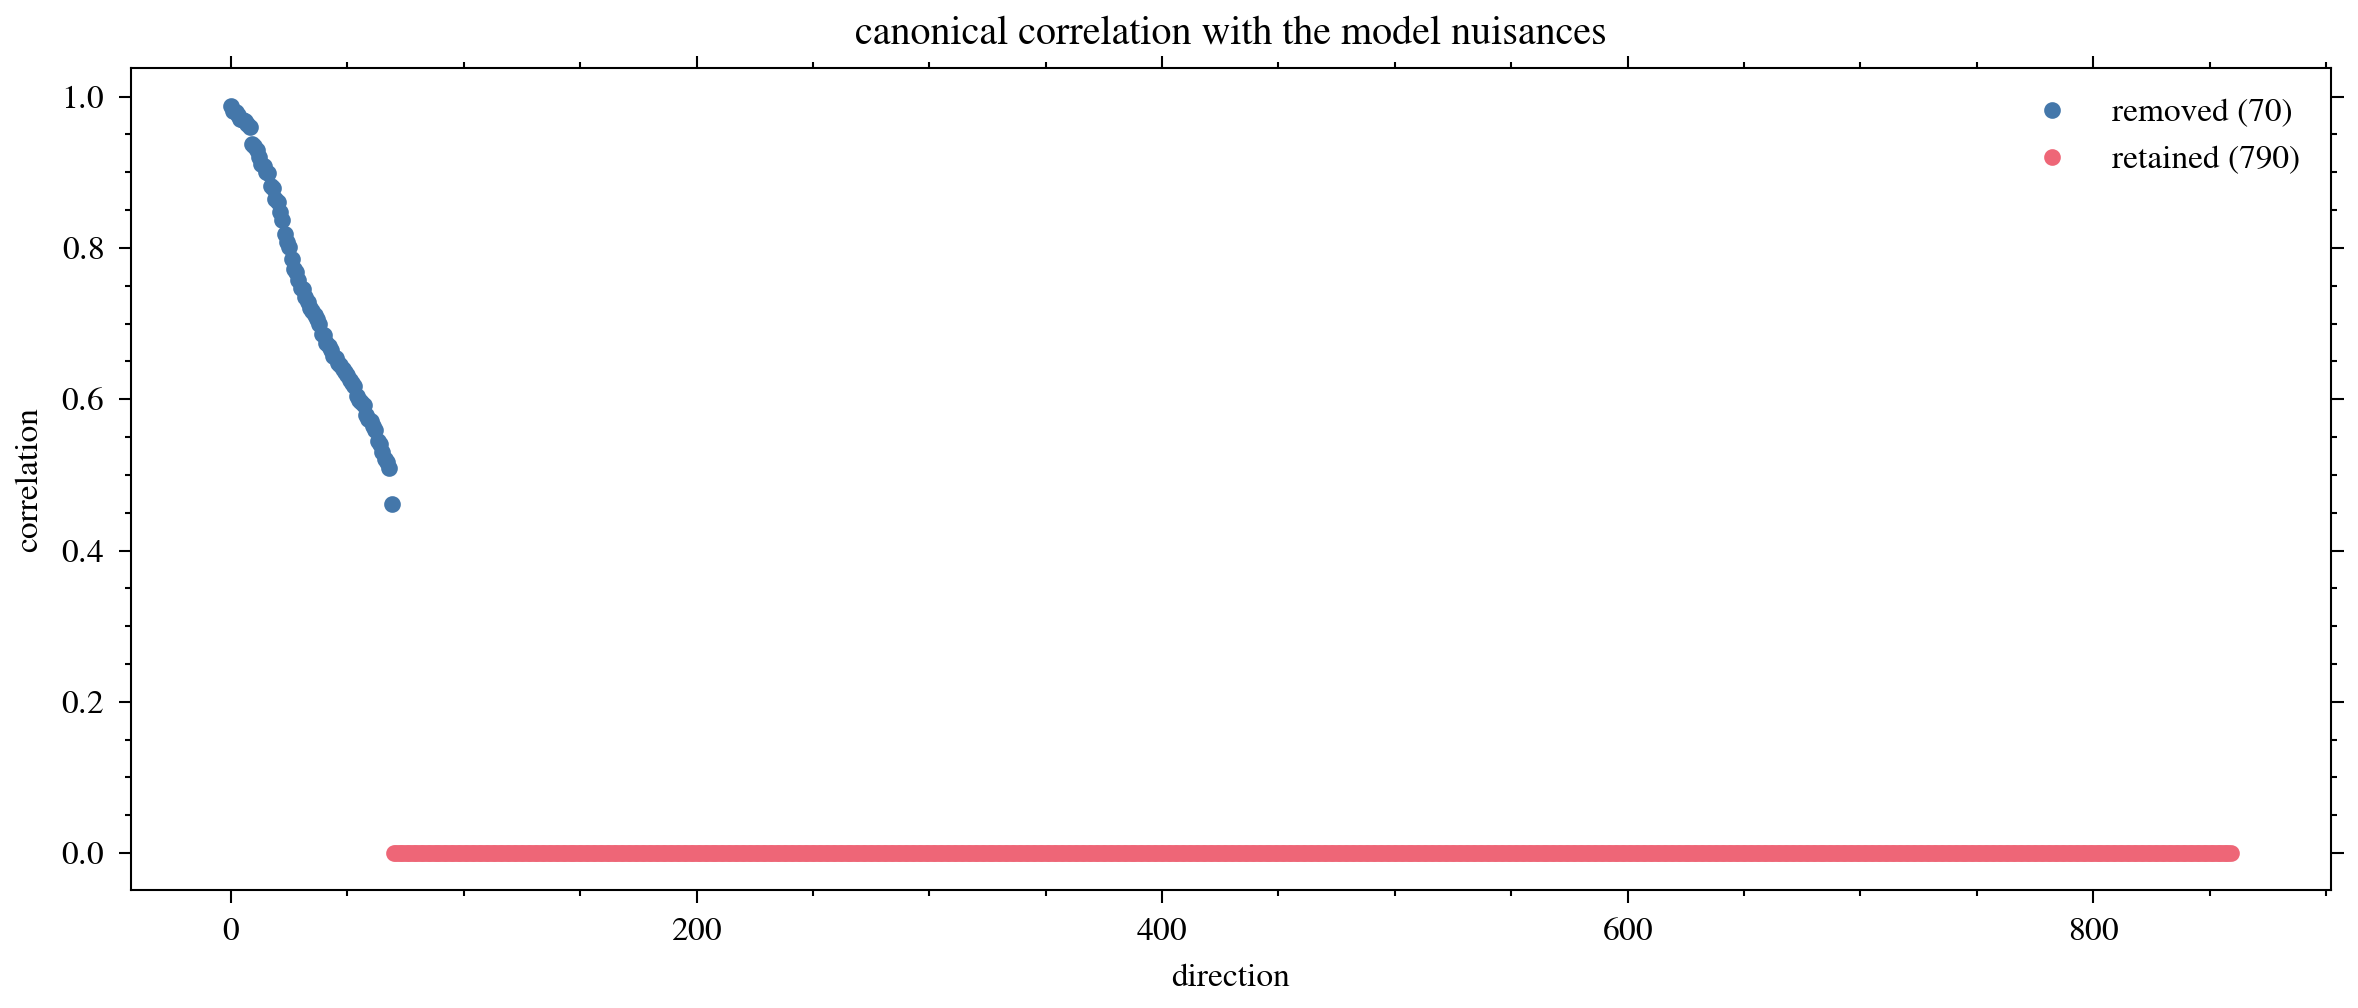

790 calibrated directions; wavelength 4.800 µm; parallactic angle 171.84 ± 0.00 deg


In [21]:
run_stage("calibrated_visibility")

### `discos`
The final DISCOs: independent, whitened combinations of calibrated visibilities, reduced to `disco_information` of the precision. Outputs: each DISCO in units of its 1σ and their distribution (a point source scatters as N(0, 1), so χ²/dof well above 1 is signal or residual calibration error), their σ, and the smallest-norm visibilities that reproduce them.

#### `discos` report

**nuisance nulls (from run.json)**

,value
F480M.model_response.visibility_rank,860
F480M.model_response.nuisance_rank,71
F480M.model_response.visibility_dimension,860
F480M.model_response.wfe_dimension,67
F480M.model_response.definition,canonical correlations between mixed visibilit...
F480M.restriction.native_dimension,860
F480M.restriction.identifiable_dimension,860
F480M.restriction.input_nuisance_rank,70
F480M.restriction.restricted_nuisance_rank_bound,70
F480M.ranks.null_full.input_dimension,860


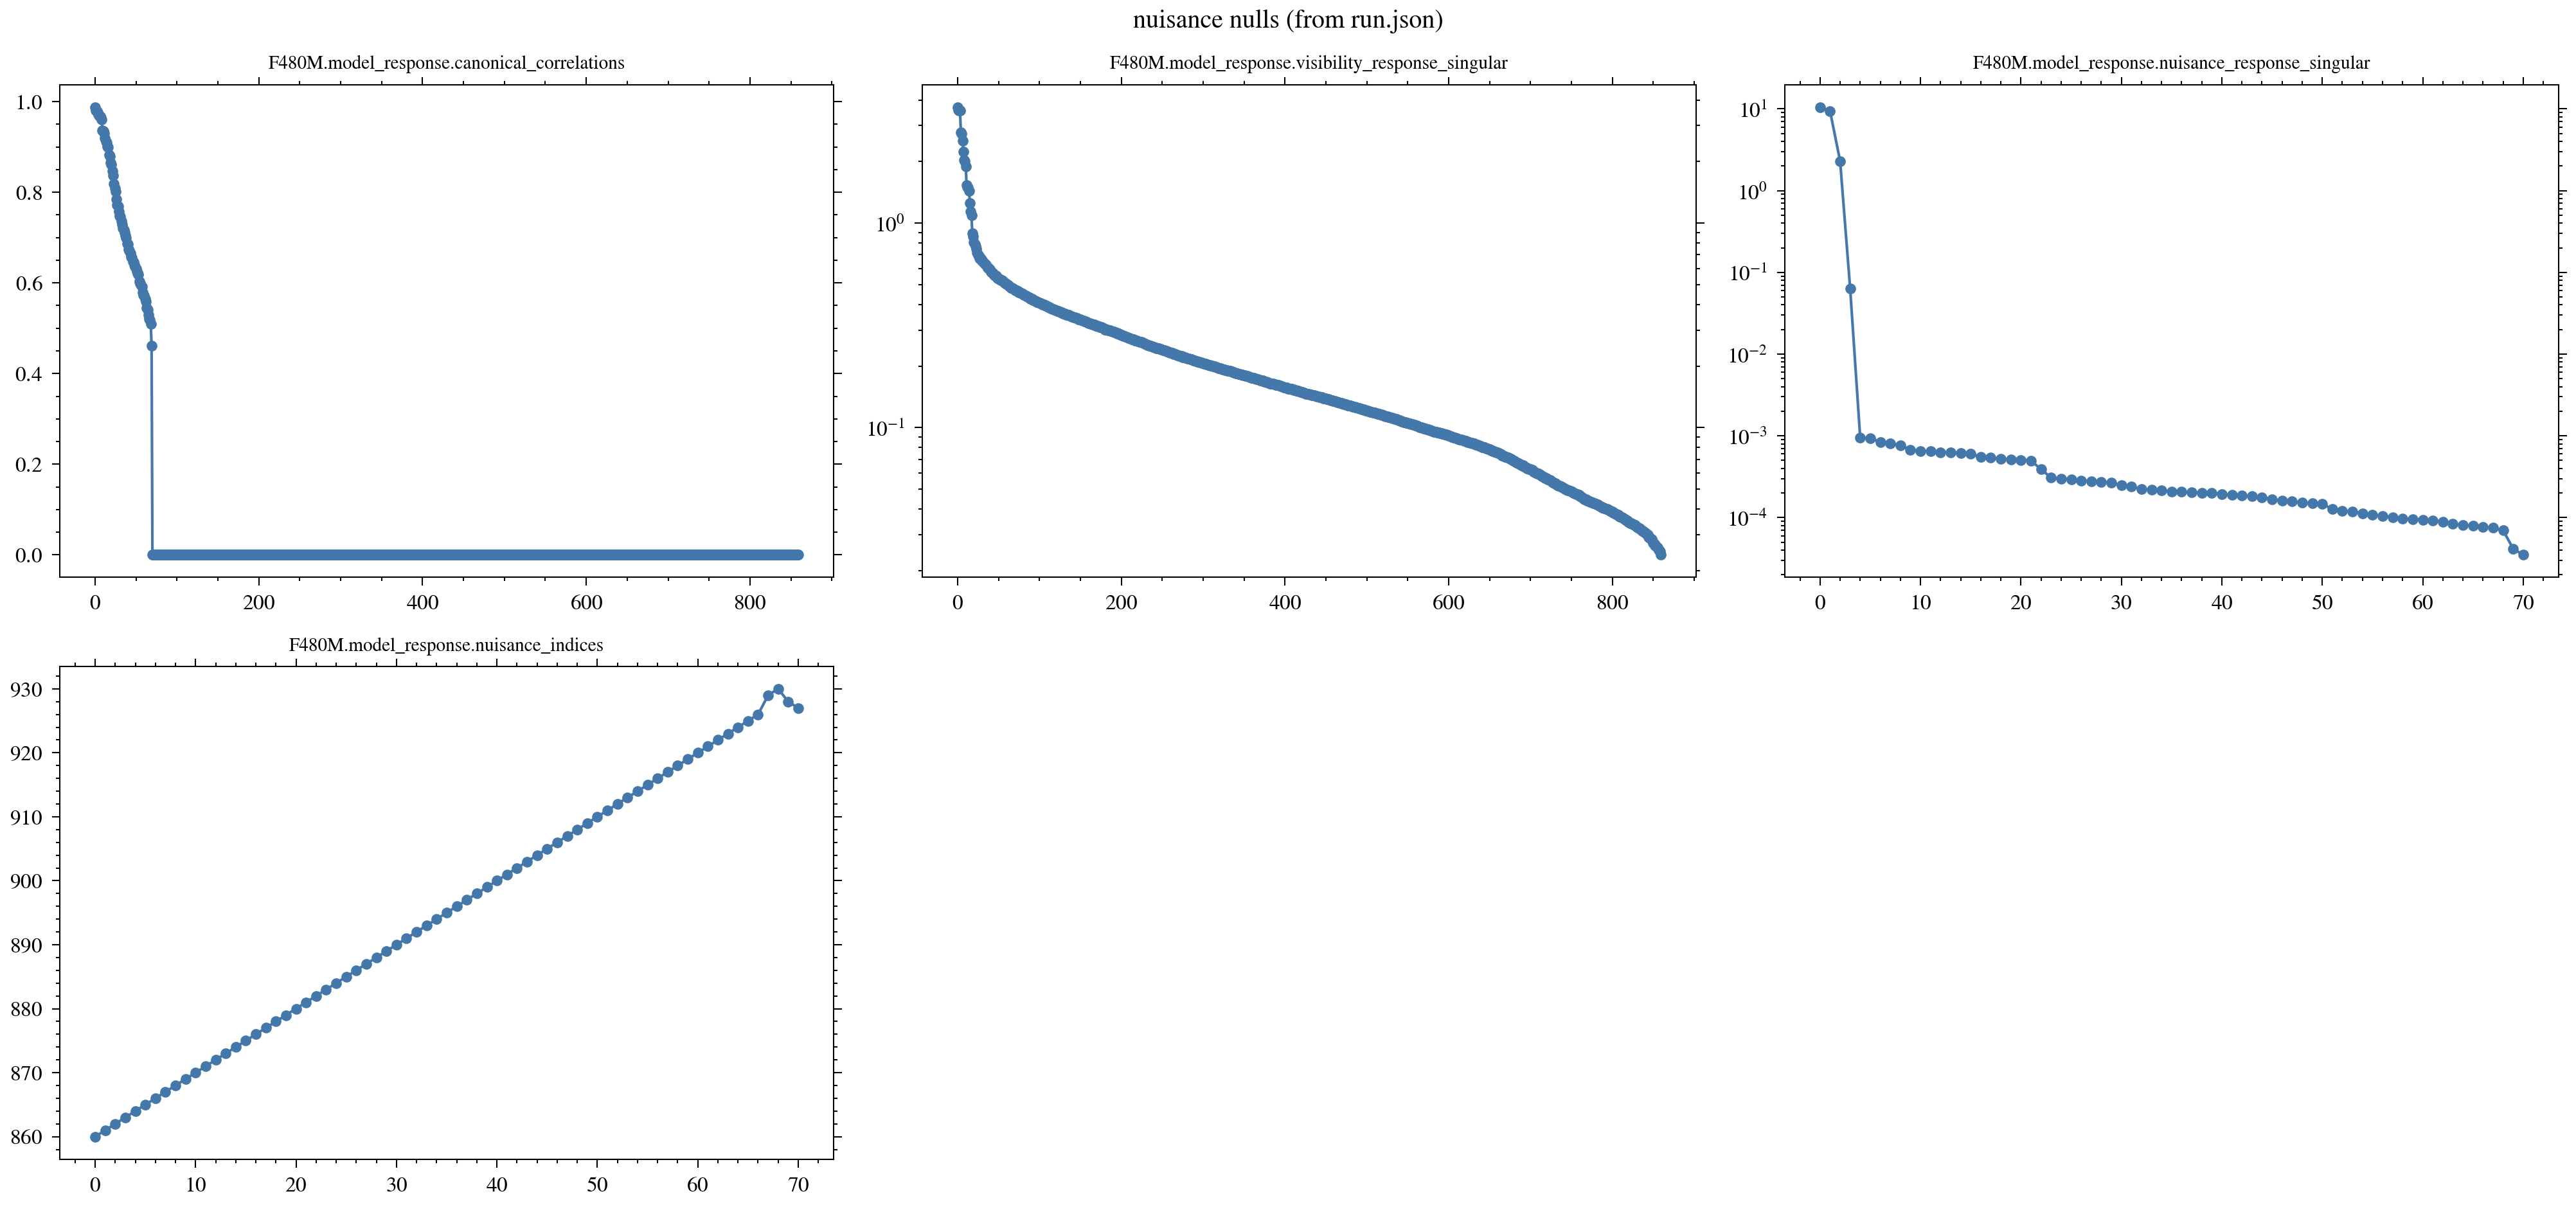

**reports/discos/marginalised**

,value
schema,amigo-latent-precision-reduced-disco-report-v1
metric,isotropic_latent_visibility_precision
threshold,0.99
filters.F480M.dimension,860
filters.F480M.uv_dimension,1512
filters.F480M.relative_covariance_off_diagonal,0.0
filters.F480M.input_dimension,860
filters.F480M.retained_dimension,709
filters.F480M.discarded_dimension,151
filters.F480M.threshold,0.99


**reports/discos/null_full**

,value
schema,amigo-latent-precision-reduced-disco-report-v1
metric,isotropic_latent_visibility_precision
threshold,0.99
filters.F480M.dimension,790
filters.F480M.uv_dimension,1512
filters.F480M.relative_covariance_off_diagonal,0.0
filters.F480M.input_dimension,790
filters.F480M.retained_dimension,694
filters.F480M.discarded_dimension,96
filters.F480M.threshold,0.99


#### `discos` outputs

#### `marginalised` (F480M)

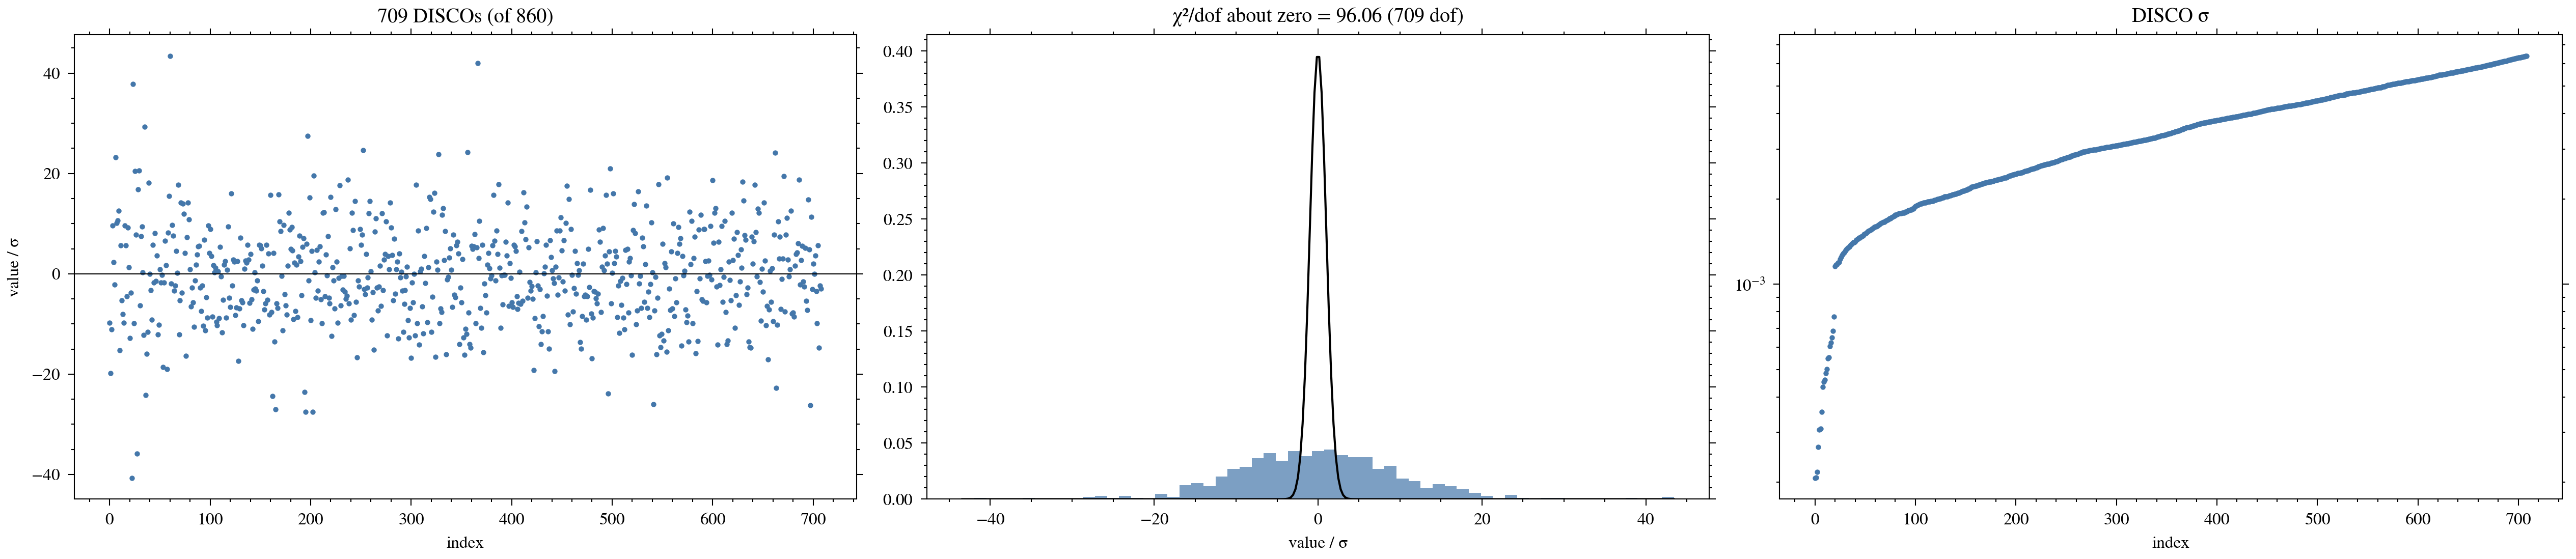

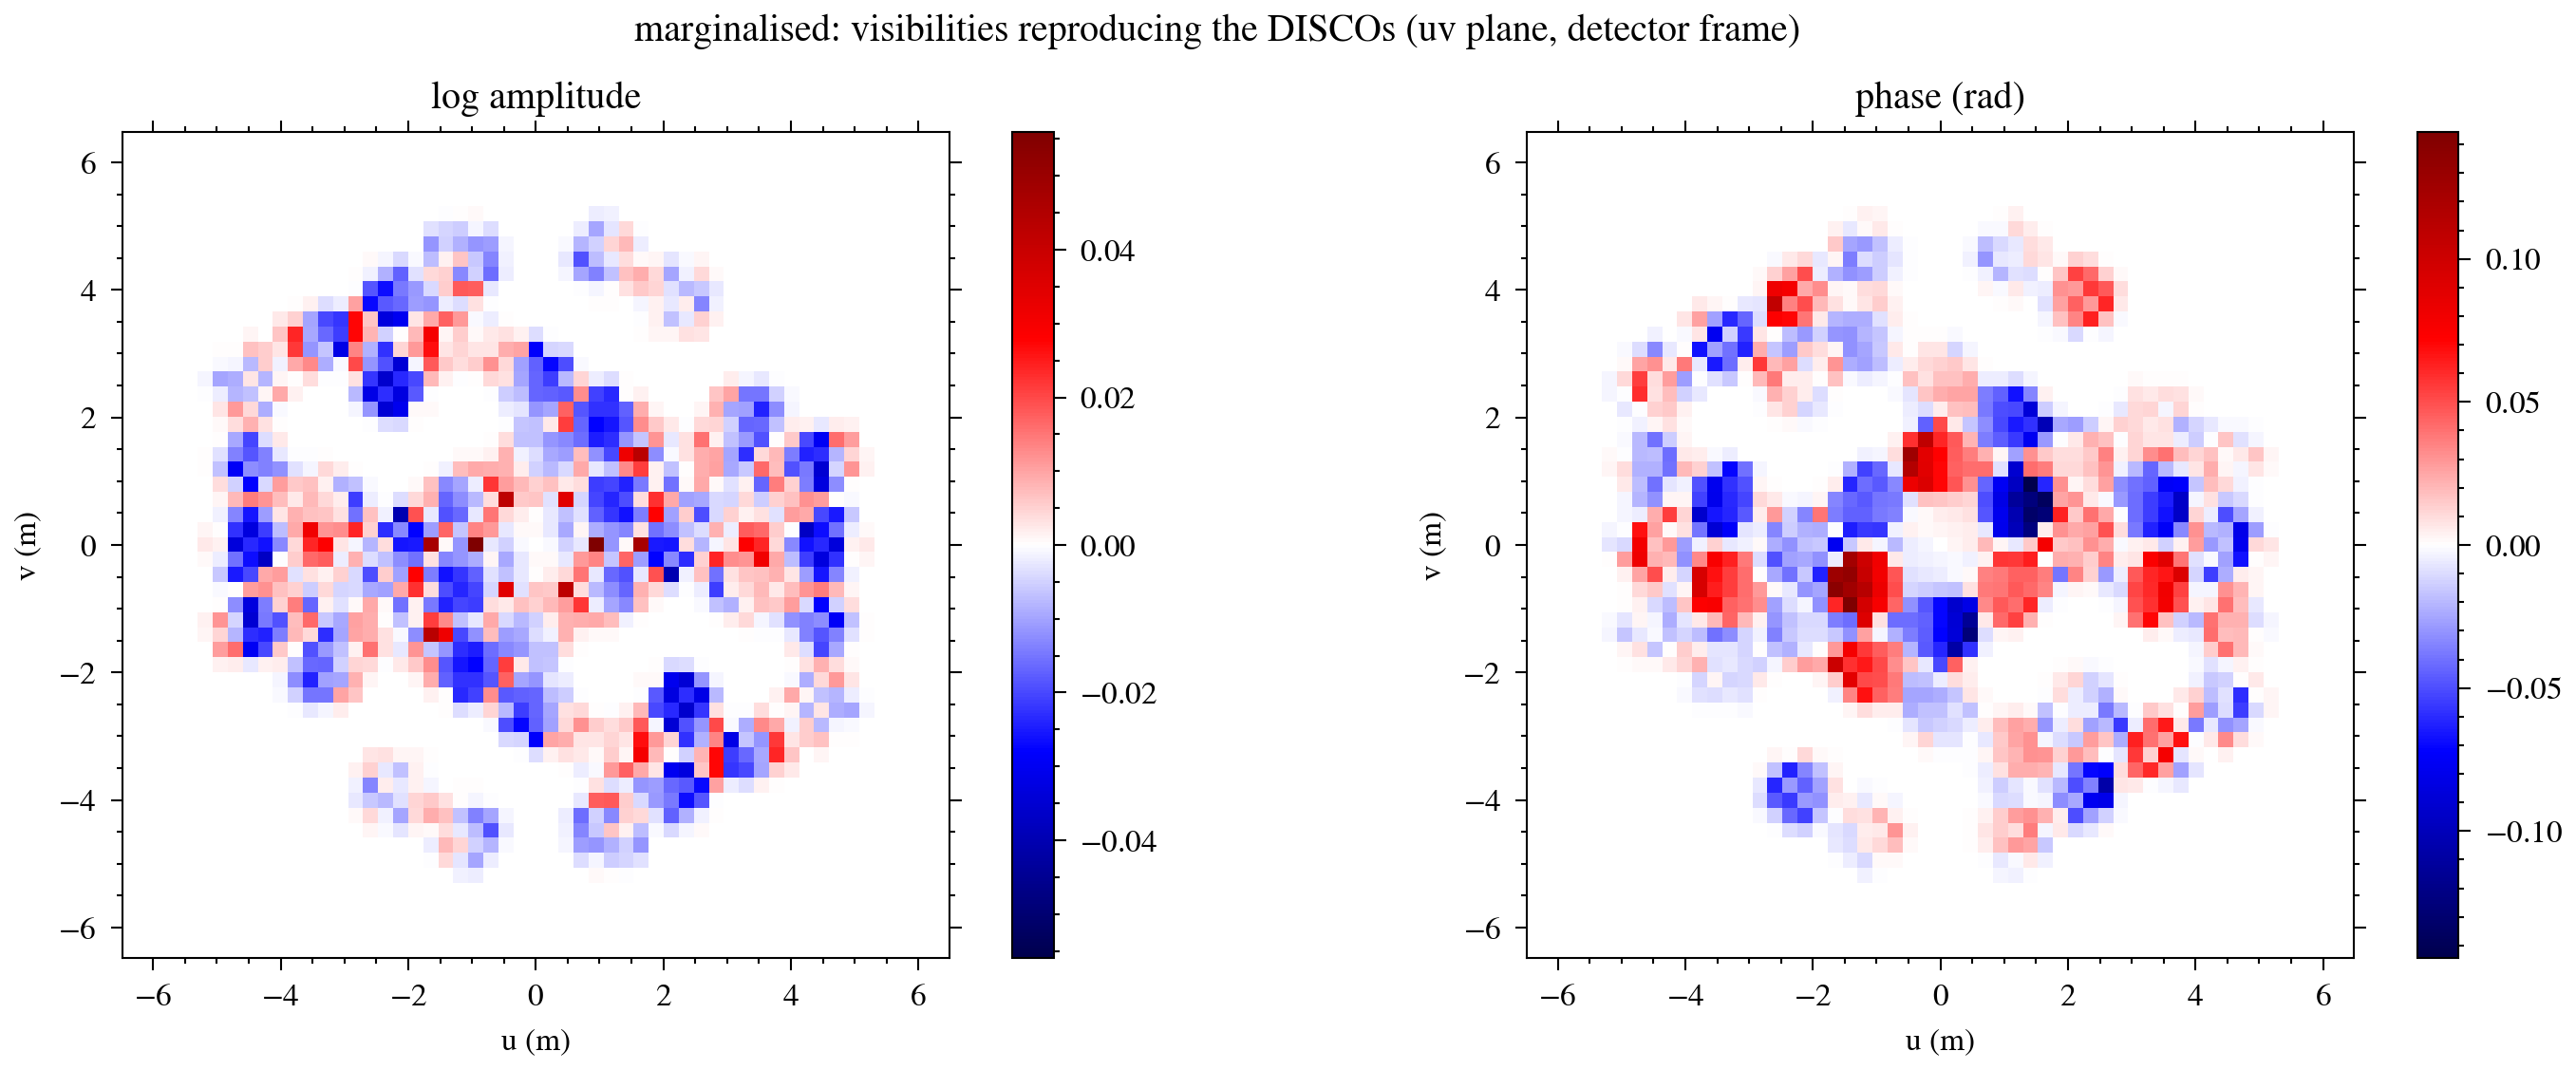

#### `null_full` (F480M)

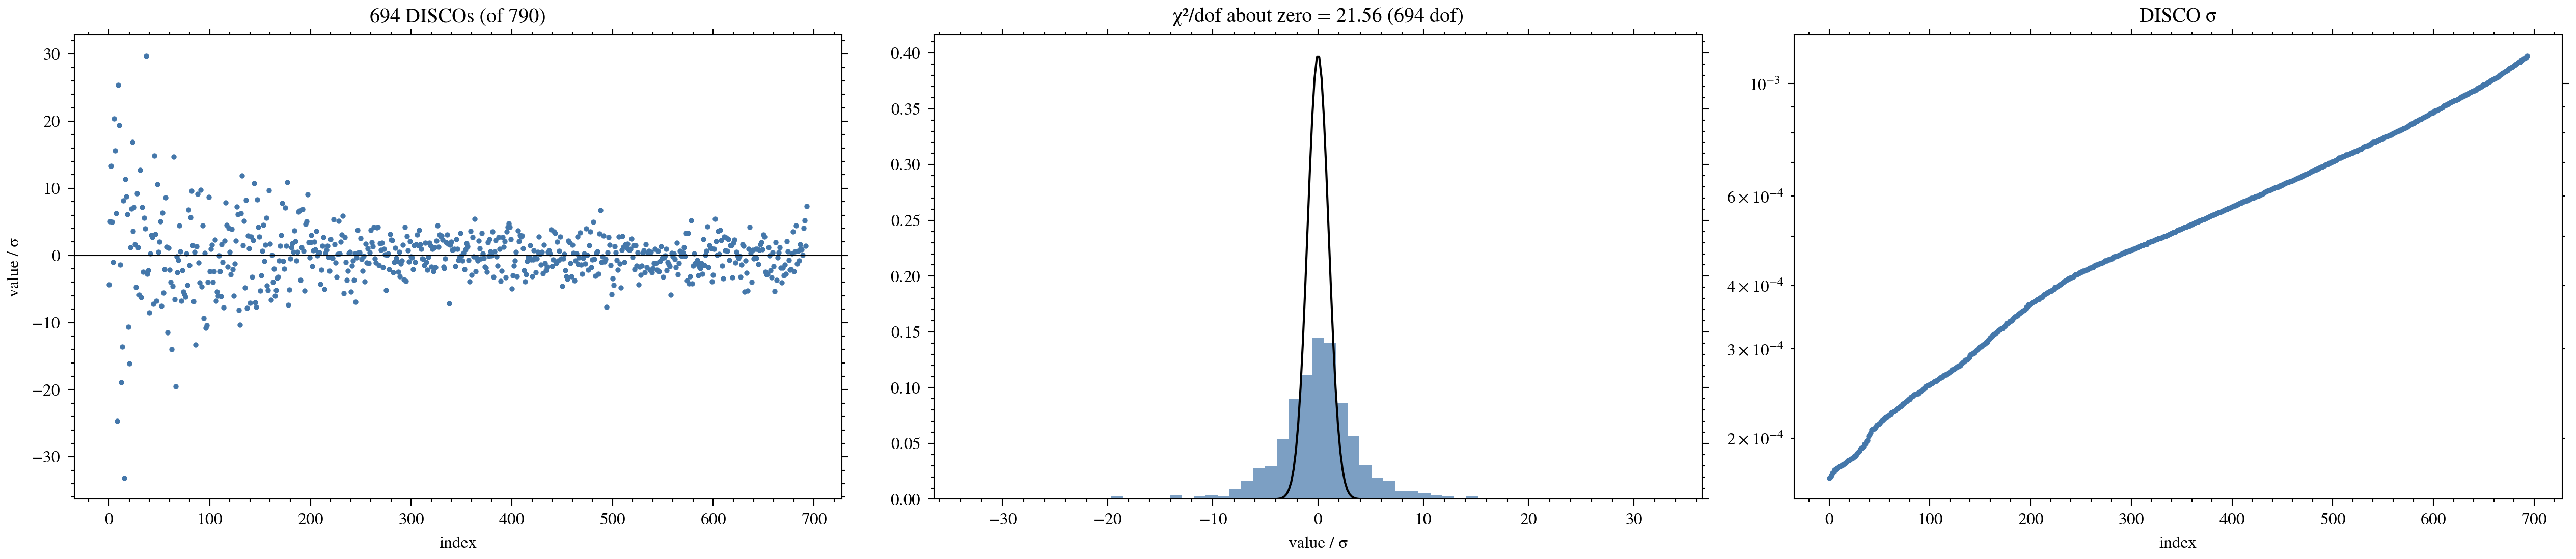

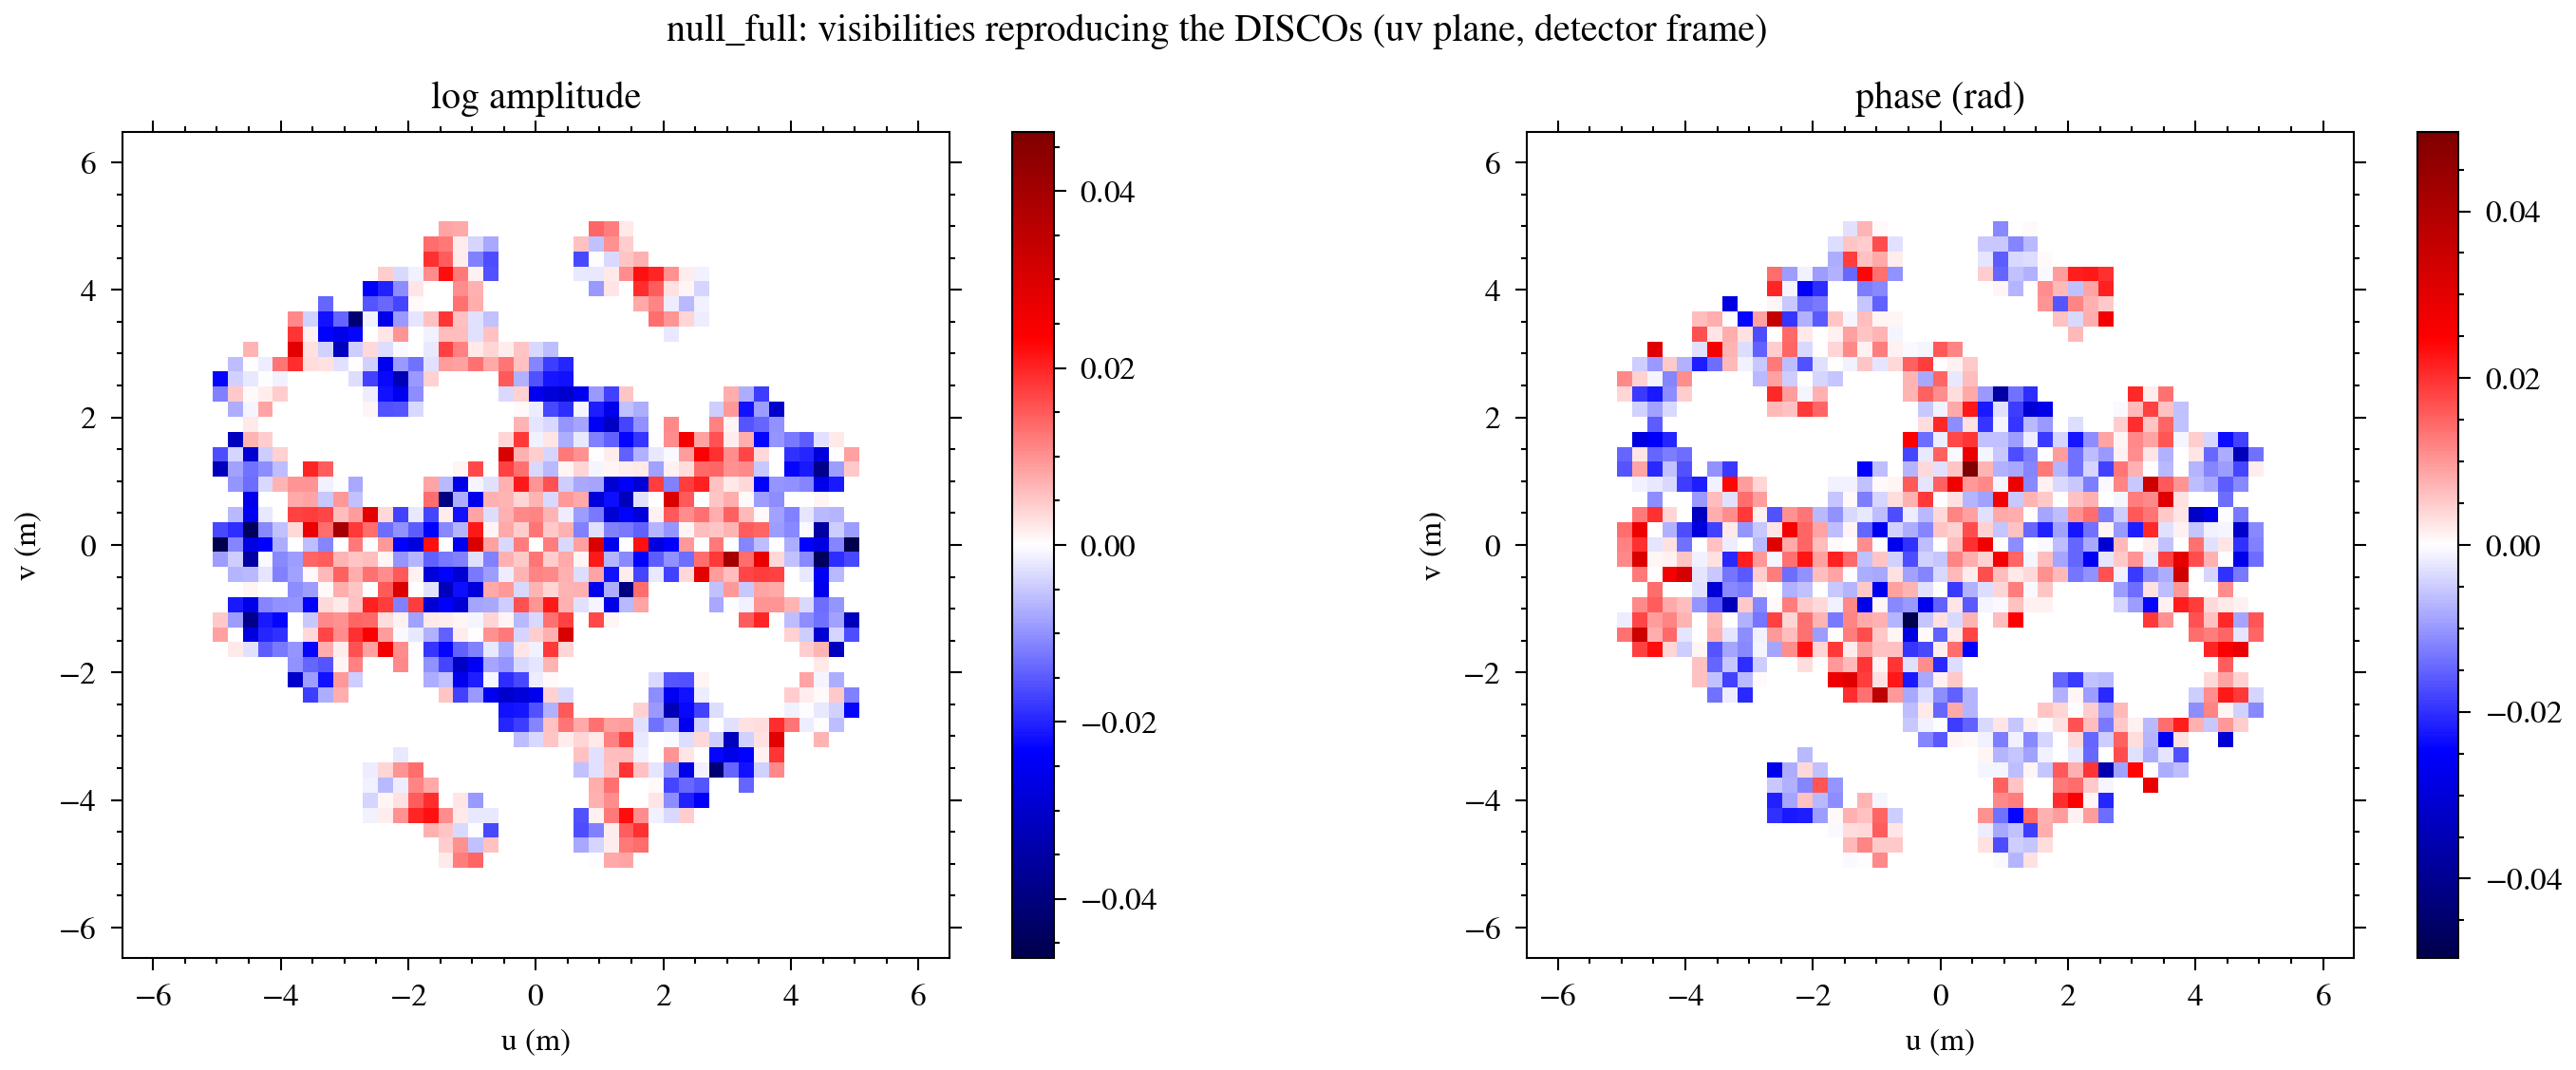

In [22]:
run_stage("discos")

## 5. Use the output

In [23]:
if result is None or not result.reduced:
    print("the run stopped before the DISCO stages (THROUGH, or a stage failed); nothing to show here")
else:
    display(result.marginalised)            # calibrated visibility products
    display(result.nulled["null_full"])     # full model-nuisance null
    display(result.reduced["null_full"])    # final 99%-precision DISCOs

{'F480M': {'native_mixed_coefficients': array([-1.04608721e-02, -3.09854973e-03, -6.05856031e-03,  2.33658293e-03,
          3.80944525e-03, -7.33705080e-04, -2.66222961e-03, -8.37665217e-03,
         -3.51130034e-03, -8.69900442e-03, -1.41851897e-02,  5.96198045e-03,
         -5.72429542e-03, -2.34955570e-03, -4.63368496e-03, -8.28347096e-04,
         -3.81997507e-03, -1.19924129e-02, -1.30803996e-03, -6.25547767e-03,
         -1.85518464e-01,  2.29698781e-02, -9.59222635e-02,  2.88438223e-01,
          1.08536780e-01, -7.83513829e-02, -3.34878725e-02, -8.19413175e-02,
         -5.37079001e-02, -5.12256890e-02, -1.41043198e-01,  1.28839543e-01,
         -4.08672722e-02, -4.05961144e-02, -1.47885389e-02, -9.59519810e-02,
          2.19667598e-01,  5.65745942e-03, -6.50297706e-02,  1.37315036e-01,
         -1.73745687e-02,  7.41913762e-02, -4.13035878e-02, -4.22248803e-02,
         -7.81458280e-03, -9.46751610e-02,  8.68791784e-02,  7.23862848e-04,
          5.19290508e-03, -8.73907870e

{'F480M': {'native_mixed_coefficients': array([-1.04608721e-02, -3.09854973e-03, -6.05856031e-03,  2.33658293e-03,
          3.80944525e-03, -7.33705080e-04, -2.66222961e-03, -8.37665217e-03,
         -3.51130034e-03, -8.69900442e-03, -1.41851897e-02,  5.96198045e-03,
         -5.72429542e-03, -2.34955570e-03, -4.63368496e-03, -8.28347096e-04,
         -3.81997507e-03, -1.19924129e-02, -1.30803996e-03, -6.25547767e-03,
         -1.85518464e-01,  2.29698781e-02, -9.59222635e-02,  2.88438223e-01,
          1.08536780e-01, -7.83513829e-02, -3.34878725e-02, -8.19413175e-02,
         -5.37079001e-02, -5.12256890e-02, -1.41043198e-01,  1.28839543e-01,
         -4.08672722e-02, -4.05961144e-02, -1.47885389e-02, -9.59519810e-02,
          2.19667598e-01,  5.65745942e-03, -6.50297706e-02,  1.37315036e-01,
         -1.73745687e-02,  7.41913762e-02, -4.13035878e-02, -4.22248803e-02,
         -7.81458280e-03, -9.46751610e-02,  8.68791784e-02,  7.23862848e-04,
          5.19290508e-03, -8.73907870e

{'F480M': {'u': array([7.33782555, 7.10012964, 6.86243373, ..., 0.71308773, 0.47539182,
         0.23769591], shape=(1512,)),
  'v': array([-5.49775352, -5.53182893, -5.56590434, ...,  0.10222622,
          0.06815082,  0.03407541], shape=(1512,)),
  'filter': 'F480M',
  'wavelength_m': array(4.79954233e-06),
  'parang_mean_deg': array(171.84182432),
  'parang_std_deg': array(0.),
  'detector_rotation_initial_deg': array(0.56126717),
  'detector_rotation_fitted_deg': array(0.52449415),
  'detector_rotation_offset_deg': array(-0.03677302),
  'joint_model_null_rank': 70,
  'joint_model_null_definition': 'leading canonical correlations between the joint model-nuisance and visibility responses in the common identifiable range',
  'joint_model_null_correlations_removed': array([0.98939062, 0.98257425, 0.98094801, 0.97665844, 0.97112222,
         0.96941928, 0.96748031, 0.96449697, 0.96064357, 0.93710829,
         0.93496909, 0.93019477, 0.91991411, 0.9118669 , 0.90852483,
         0.9006998

In [24]:
from amigo_pipeline import load_oi_data

disco_path = os.path.join(output_path, "ab-dor_louis", "discos", "null_full", "discos.npy")
if os.path.isfile(disco_path):
    oi = load_oi_data(disco_path)
    display(oi)
else:
    print("no DISCO product yet:", disco_path)

{'F480M': AmigoOIData(
   u=f64[1512],
   v=f64[1512],
   wavel=f64[],
   parang=f64[],
   vis=f64[694],
   d_vis=f64[694],
   phi=f64[0],
   d_phi=f64[0],
   vis_mat=f64[694,1512],
   phi_mat=f64[694,1512],
   mixed_disco=True
 )}

## 6. Binary analysis
As in part 4 of `QUICKSTART.md`: the DISCOs go into AMIGO's visibility likelihood (`load_oi_data`, `BinaryModelCartesian`,
`model_loglike`), with joint astrometry and an independent contrast in each filter. The quickstart stops at the likelihood, so
this section adds a simple search on top of it:
1. **grid**: on a grid of companion offsets (ΔRA, ΔDec), the log likelihood maximised over each filter's contrast (a
   log-spaced contrast grid), summed over filters, relative to a single star;
2. **refine**: BFGS from the best grid point in (ΔRA, ΔDec, log₁₀ contrast per filter), with 1σ errors from the Hessian;
3. **check**: the DISCO residuals of the best binary against those of a single star.

Offsets are in mas with RA increasing to the left (east). Separations below λ/(2 B_max) or beyond the search half-width are
masked. `DISCO_PRODUCT` picks the DISCO product (`null_full` is the quickstart's).

In [25]:
import numpy as onp
import jax
import jax.numpy as jnp
import scipy.optimize as so
import dLux.utils as dlu
from amigo_pipeline import load_oi_data
from amigo.vis_analysis import BinaryModelCartesian, model_loglike

DISCO_PRODUCT = "null_full"
SEARCH_MAS = 600.0  # half-width of the search box
N_POSITIONS = 121  # grid points per axis
CONTRASTS = onp.logspace(-5, -0.5, 64)  # companion / primary flux ratios tried at each offset

disco_path = os.path.join(pipeline.output, "discos", DISCO_PRODUCT, "discos.npy")
oi = load_oi_data(disco_path)
filters = sorted(oi)


def loglike(dra, ddec, contrast, oi_data):
    return model_loglike(BinaryModelCartesian(dra, ddec, contrast), oi_data)


null_loglike = {f: float(loglike(0.0, 0.0, 0.0, oi[f])) for f in filters}

# 1. grid: max over contrast at each offset, per filter
dras = onp.linspace(SEARCH_MAS, -SEARCH_MAS, N_POSITIONS)  # RA increases to the left
ddecs = onp.linspace(-SEARCH_MAS, SEARCH_MAS, N_POSITIONS)
RA, DEC = onp.meshgrid(dras, ddecs)  # image rows = Dec, columns = RA
delta, best_contrast = {}, {}
for f in filters:
    over_contrast = jax.jit(jax.vmap(lambda dra, ddec: jax.vmap(lambda c: loglike(dra, ddec, c, oi[f]))(jnp.asarray(CONTRASTS))))
    cube = onp.concatenate([onp.asarray(over_contrast(jnp.asarray(r), jnp.asarray(d)))
                            for r, d in zip(onp.array_split(RA.ravel(), 20), onp.array_split(DEC.ravel(), 20))])
    delta[f] = (cube.max(1) - null_loglike[f]).reshape(RA.shape)
    best_contrast[f] = CONTRASTS[cube.argmax(1)].reshape(RA.shape)
joint = sum(delta.values())

# separations the baselines can't resolve, or outside the search box
baselines = {f: onp.hypot(onp.asarray(oi[f].u), onp.asarray(oi[f].v)) for f in filters}
inner = max(1e3 * float(dlu.rad2arcsec(float(oi[f].wavel) / (2 * baselines[f].max()))) for f in filters)
separation = onp.hypot(RA, DEC)
mask = (separation < inner) | (separation > SEARCH_MAS)
joint = onp.where(mask, onp.nan, joint)

iy, ix = onp.unravel_index(onp.nanargmax(joint), joint.shape)
print(f"grid peak: ΔRA {RA[iy, ix]:.1f} mas, ΔDec {DEC[iy, ix]:.1f} mas, Δln L {joint[iy, ix]:.1f} "
      + ", ".join(f"{f} contrast {best_contrast[f][iy, ix]:.3g}" for f in filters))

grid peak: ΔRA -330.0 mas, ΔDec 60.0 mas, Δln L 5491.7 F480M contrast 0.0164


In [26]:
# 2. refine: BFGS in (ΔRA, ΔDec, log10 contrast per filter), errors from the Hessian of −ln L
def negative_loglike(x):
    return -sum(loglike(x[0], x[1], 10.0 ** x[2 + i], oi[f]) for i, f in enumerate(filters))


value_and_grad = jax.jit(jax.value_and_grad(negative_loglike))
x0 = onp.array([RA[iy, ix], DEC[iy, ix], *[onp.log10(best_contrast[f][iy, ix]) for f in filters]])
fit = so.minimize(lambda x: tuple(onp.asarray(v, dtype=float) for v in value_and_grad(jnp.asarray(x))), x0, jac=True, method="BFGS")
covariance = onp.linalg.inv(onp.asarray(jax.hessian(negative_loglike)(jnp.asarray(fit.x))))
errors = onp.sqrt(onp.diag(covariance))
best = dict(dra=fit.x[0], ddec=fit.x[1], contrast={f: 10.0 ** fit.x[2 + i] for i, f in enumerate(filters)})
delta_best = -fit.fun - sum(null_loglike.values())

sep = onp.hypot(best["dra"], best["ddec"])
pa = onp.degrees(onp.arctan2(best["dra"], best["ddec"])) % 360  # east of north
J = onp.array([[best["dra"] / sep, best["ddec"] / sep], [onp.degrees(best["ddec"] / sep**2), -onp.degrees(best["dra"] / sep**2)]])
sep_err, pa_err = onp.sqrt(onp.diag(J @ covariance[:2, :2] @ J.T))
n_dof = sum(oi[f].vis.size + oi[f].phi.size for f in filters)
rows = {
    "ΔRA (mas)": f"{best['dra']:.2f} ± {errors[0]:.2f}",
    "ΔDec (mas)": f"{best['ddec']:.2f} ± {errors[1]:.2f}",
    "separation (mas)": f"{sep:.2f} ± {sep_err:.2f}",
    "position angle (deg E of N)": f"{pa:.2f} ± {pa_err:.2f}",
}
for i, f in enumerate(filters):
    c, dlog = best["contrast"][f], errors[2 + i]
    rows[f"{f} contrast"] = f"{c:.4g} (log₁₀ {onp.log10(c):.3f} ± {dlog:.3f}); Δmag {-2.5 * onp.log10(c):.2f}"
rows["Δln L vs single star"] = f"{delta_best:.1f} (Δχ² = {2 * delta_best:.1f} for {len(fit.x)} extra parameters)"
rows["BFGS"] = fit.message
display(pd.DataFrame({"best-fit binary": rows}))

# the quickstart's joint log likelihood, at the best fit
joint_log_likelihood = sum(
    model_loglike(BinaryModelCartesian(best["dra"], best["ddec"], best["contrast"][f]), oi_data)
    for f, oi_data in oi.items()
)
print(f"joint log likelihood at the best fit: {float(joint_log_likelihood):.2f} (single star {sum(null_loglike.values()):.2f})")

,best-fit binary
ΔRA (mas),-326.96 ± 0.77
ΔDec (mas),60.62 ± 0.74
separation (mas),332.53 ± 0.77
position angle (deg E of N),280.50 ± 0.13
F480M contrast,0.01678 (log₁₀ -1.775 ± 0.004); Δmag 4.44
Δln L vs single star,5500.9 (Δχ² = 11001.8 for 3 extra parameters)
BFGS,Desired error not necessarily achieved due to ...


joint log likelihood at the best fit: 2676.45 (single star -2824.45)


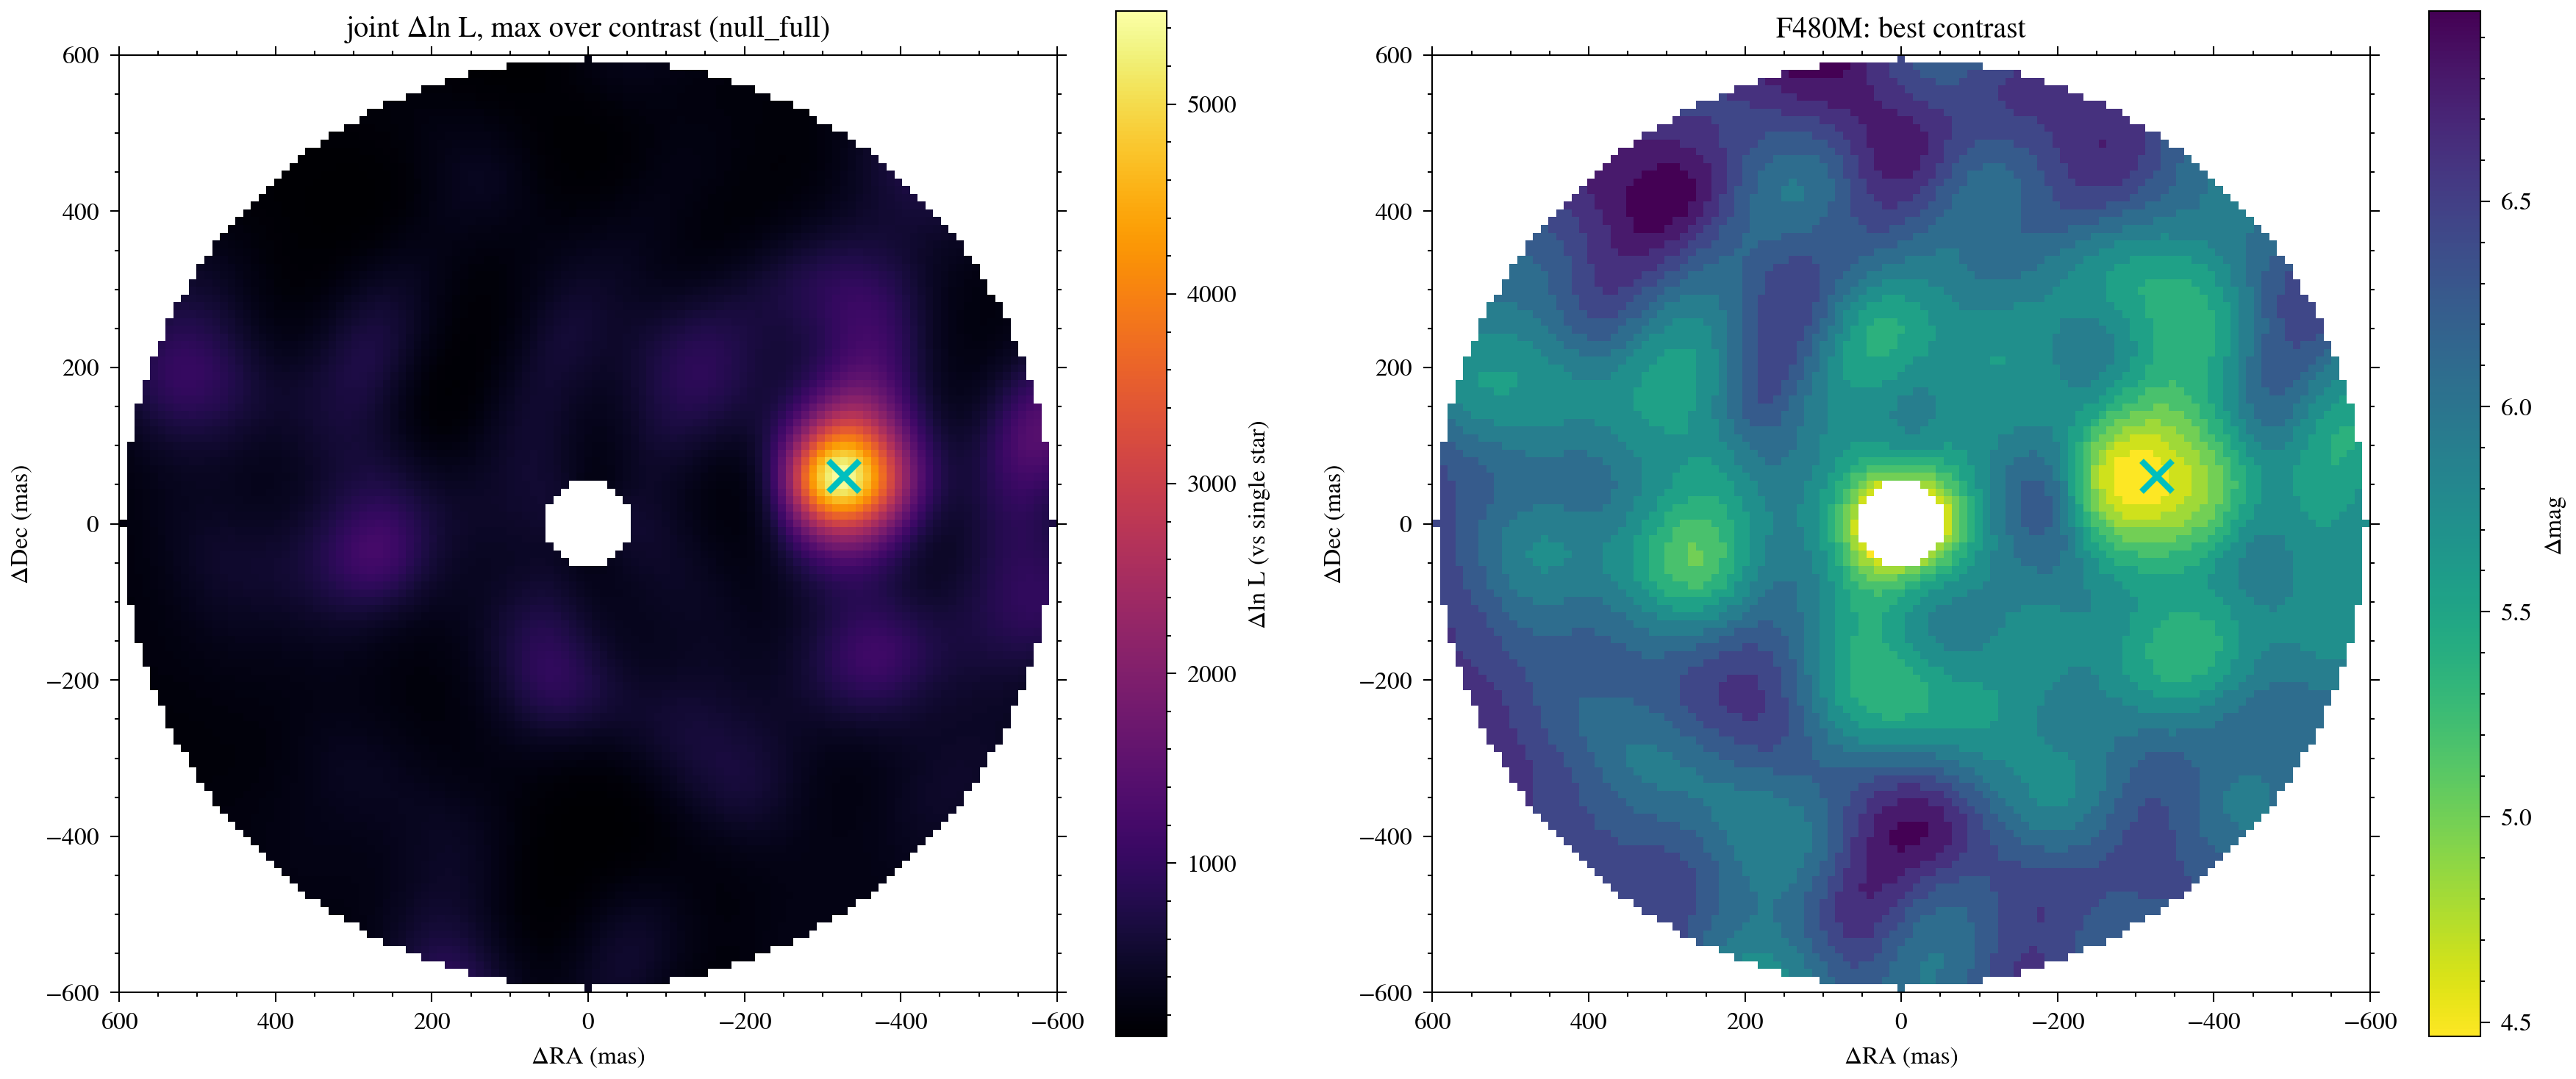

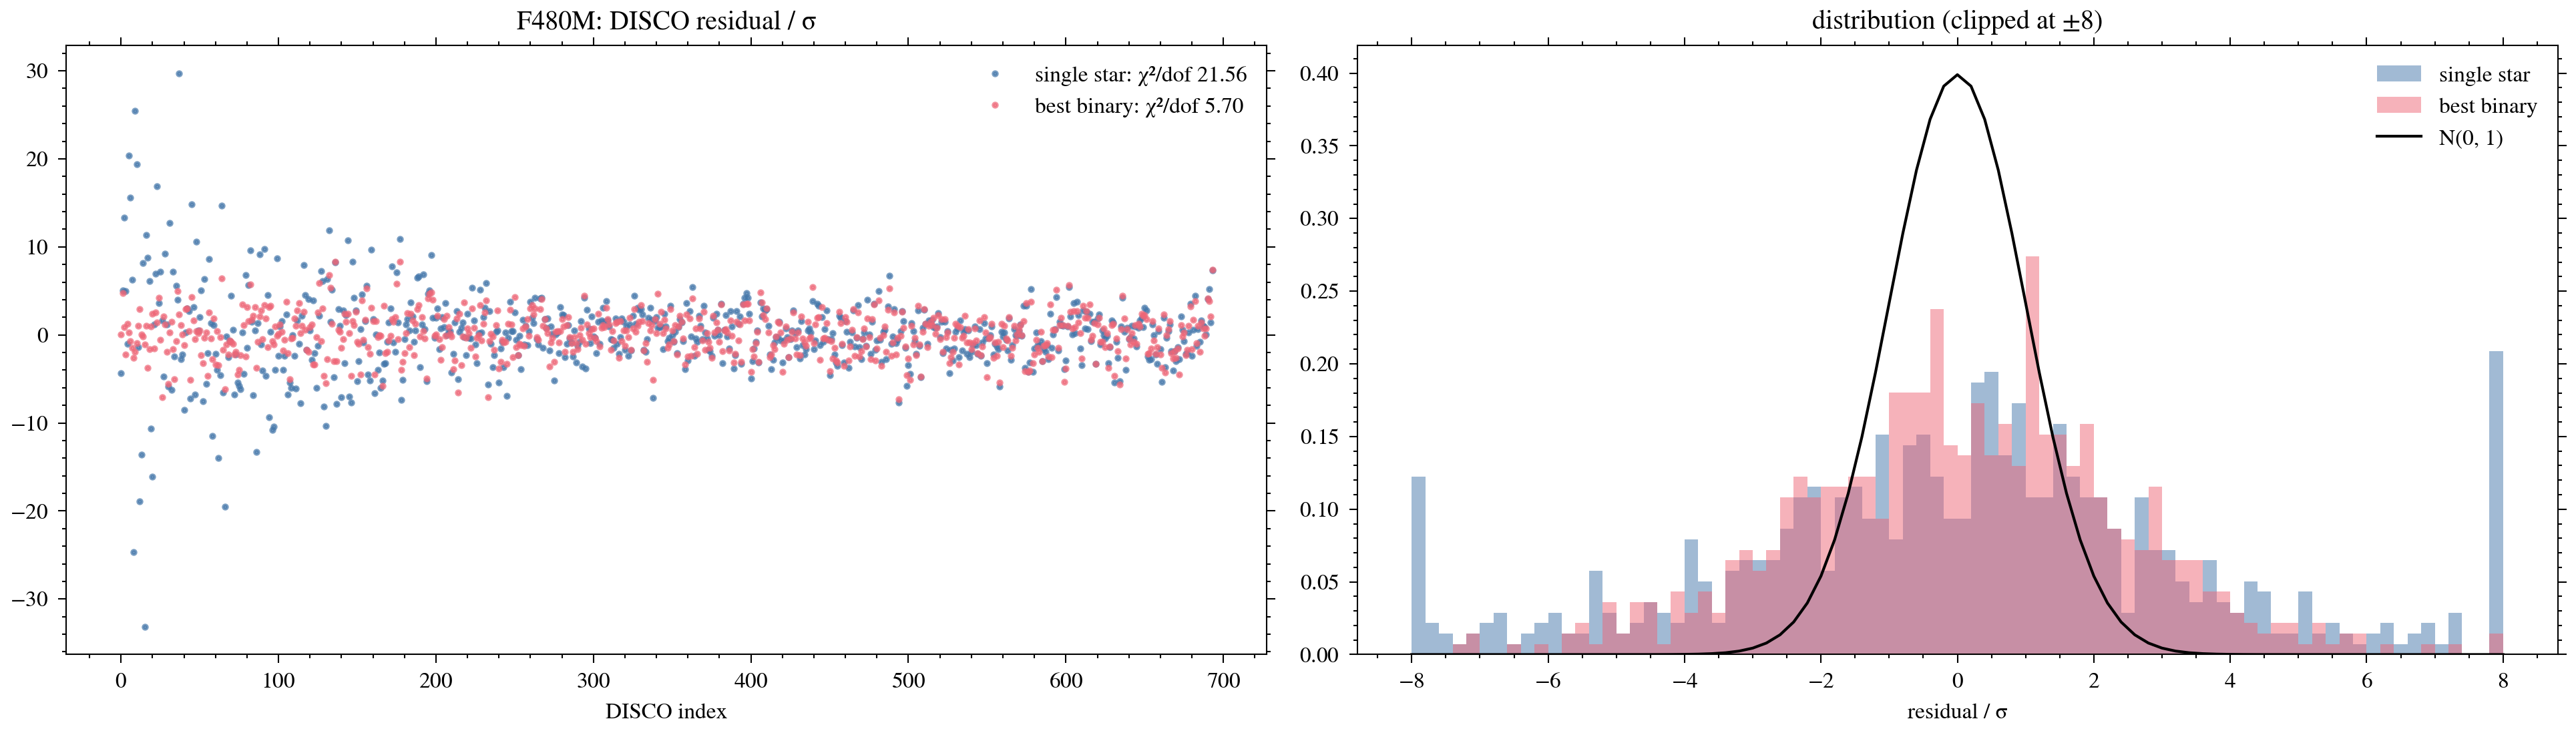

In [27]:
# the maps: joint Δln L, and each filter's best contrast (as Δmag)
extent = (dras[0], dras[-1], ddecs[0], ddecs[-1])
fig, ax = plt.subplots(1, 1 + len(filters), figsize=(6 * (1 + len(filters)), 5))
im = ax[0].imshow(onp.clip(joint, 0, None), extent=extent, origin="lower", cmap="inferno")
plt.colorbar(im, ax=ax[0], label="Δln L (vs single star)")
ax[0].set(title=f"joint Δln L, max over contrast ({DISCO_PRODUCT})")
for a, f in zip(ax[1:], filters):
    im = a.imshow(onp.where(mask, onp.nan, -2.5 * onp.log10(best_contrast[f])), extent=extent, origin="lower", cmap="viridis_r")
    plt.colorbar(im, ax=a, label="Δmag")
    a.set(title=f"{f}: best contrast")
for a in ax:
    a.plot(best["dra"], best["ddec"], "x", color="c", ms=10, mew=2)
    a.set(xlabel="ΔRA (mas)", ylabel="ΔDec (mas)")
plt.tight_layout()
plt.show()

# 3. check: DISCO residuals of the best binary vs a single star
for f in filters:
    data, sigma = (onp.asarray(v) for v in oi[f].flatten_data())
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
    edges = onp.linspace(-8, 8, 81)
    for label, model_obj in (("single star", BinaryModelCartesian(0.0, 0.0, 0.0)),
                             ("best binary", BinaryModelCartesian(best["dra"], best["ddec"], best["contrast"][f]))):
        z = (data - onp.asarray(oi[f].model(model_obj))) / sigma
        ax[0].plot(z, ".", ms=3, alpha=0.7, label=f"{label}: χ²/dof {onp.mean(z**2):.2f}")
        ax[1].hist(onp.clip(z, edges[0], edges[-1]), bins=edges, density=True, alpha=0.5, label=label)
    ax[1].plot(edges, onp.exp(-edges**2 / 2) / onp.sqrt(2 * onp.pi), "k", label="N(0, 1)")
    ax[0].set(title=f"{f}: DISCO residual / σ", xlabel="DISCO index")
    ax[1].set(title="distribution (clipped at ±8)", xlabel="residual / σ")
    for a in ax:
        a.legend(fontsize=8)
    plt.tight_layout()
    plt.show()